# Haplotype cluster analysis

In [ ]:
!pip install -qq malariagen_data
import malariagen_data
import numpy as np
import pandas as pd
import allel
import zarr
import matplotlib.pyplot as plt
import seaborn as sns

ag3 = malariagen_data.Ag3()
ag3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.9/25.9 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB

<MalariaGEN Ag3 API client>
Storage URL             : gs://vo_agam_release_master_us_central1/
Data releases available : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache           : None
Cohorts analysis        : 20250502
AIM analysis            : 20220528
Site filters analysis   : dt_20200416
Software version        : malariagen_data 15.2.2
Client location         : Utah, United States (Google Cloud us-west3)
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.2.2/Ag3.html

In [ ]:
genome_features = ag3.genome_features()
genome_features['contig'].unique()
genome_features.to_csv("ano_genome_features.csv")

array(['2L', '2R', '3L', '3R', 'Mt', 'UNKN', 'X', 'Y_unplaced'],
      dtype=object)

In [ ]:
# Select regions detected under sweep selection
regions = ["2R:28,430,000-28,615,000", "3R:28,400,000-28,600,000", "3R:32,000,000-32,080,000", "X:15,130,000-15,324,000"]

# Load the sample metadata for the Gambia
sample_metadata = ag3.sample_metadata(sample_query="country=='Gambia, The' and taxon in ['coluzzii', 'gambiae', 'bissau']")

# Define the subsets of samples for each taxon
coluzzii_subset = sample_metadata.query("taxon=='coluzzii'").groupby("admin1_iso").apply(lambda x: x.sample(n=min(20, len(x)))).reset_index(drop=True)
coluzzii_subset.groupby('admin1_iso').size()
gambiae_subset = sample_metadata.query("taxon=='gambiae'")
bissau_subset_GM_N = sample_metadata.query("taxon=='bissau'and admin1_iso == 'GM-N'").sample(n=50, random_state=42)
bissau_subset = sample_metadata.query("taxon=='bissau' and admin1_iso not in ['GM-U', 'GM-N']")
# Take 40 indiv in each taxon
"""coluzzii_subset = sample_metadata.query("taxon=='coluzzii'").sample(n=40, random_state=42)
gambiae_subset =sample_metadata.query("taxon=='gambiae'").sample(n=40, random_state=42)
bissau_subset = sample_metadata.query("taxon=='bissau'").sample(n=40, random_state=42)
"""
samples_df = pd.concat([coluzzii_subset, gambiae_subset, bissau_subset_GM_N, bissau_subset])
#rename sample
samples_df["sample_pop"] = samples_df["taxon"] + "_" + samples_df["admin1_iso"]
# Samples list
samples_list = list(samples_df['sample_id'].values)

# Select a region for analysis
region = regions[2]
# Compute the pairwise haplotype distance
dist, phased_sample, n_snp = ag3.haplotype_pairwise_distances(
    region=region,
    analysis="gamb_colu",
    sample_query=f"country=='Gambia, The' and sample_id in {samples_list}",
)


In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.patches as mpatches

# Align sample metadata with haplotypes.
df_samples_phased = (
    samples_df.set_index("sample_id").loc[phased_sample.tolist()].reset_index()
)

# Ensure correct distance matrix format
if len(dist.shape) == 1:  # If dist is condensed (1D)
    distance_matrix_sq = squareform(dist)
else:
    distance_matrix_sq = dist  # Already square

# Repeat metadata so there is one row per haplotype
df_haps = pd.DataFrame(np.repeat(df_samples_phased.values, 2, axis=0))
df_haps.columns = df_samples_phased.columns  # Restore column names

# Ensure haplotype IDs match the distance matrix shape
haplotype_ids = list(df_haps["sample_pop"].values)  # Use the repeated sample IDs for haplotypes

# Validate matrix and haplotype list size
assert distance_matrix_sq.shape == (len(haplotype_ids), len(haplotype_ids)), \
    f"Mismatch: Distance matrix shape {distance_matrix_sq.shape} vs. haplotype list {len(haplotype_ids)}"

# Perform hierarchical clustering using the condensed form of distances
linkage_matrix = sch.linkage(dist, method='ward')

# Convert distance matrix to DataFrame with correct haplotype IDs
distance_df = pd.DataFrame(distance_matrix_sq, index=haplotype_ids, columns=haplotype_ids)


# Create color mapping based on taxon
taxon_palette = {
    "coluzzii": "orange",
    "gambiae": "blue",
    "bissau": "purple"
}

# Convert taxon labels to colors
df_haps["color"] = df_haps["taxon"].map(taxon_palette)

# Create row_colors as a Pandas DataFrame (ensuring index matches the heatmap data)
row_colors = pd.DataFrame(df_haps["color"])
row_colors.index = haplotype_ids  # Align with heatmap index
row_colors.columns = ["Taxon"]  # Name the column for better visualization

# Create enhanced legend handles with proper formatting
legend_label_map = {
    "gambiae": r"$\boldsymbol{An.\ gambiae\ s.s}$ ",
    "coluzzii": r"$\boldsymbol{An.\ coluzzii}$",
    "bissau": r"$\mathbf{Bissau}$",
}

legend_handles = [
    mpatches.Patch(color=color, label=legend_label_map.get(label, label))
    for label, color in taxon_palette.items()
]

# Plot heatmap with hierarchical clustering
g = sns.clustermap(
    pd.DataFrame(distance_matrix_sq, index=haplotype_ids, columns=haplotype_ids),
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="viridis",
    figsize=(17, 15),
    row_colors=row_colors,
    col_colors=row_colors,
    cbar_pos=(0, 0.8, 0.02, 0.18)  # (x, y, width, height)
)

# Add enhanced legend
legend = g.ax_heatmap.legend(handles=legend_handles, title='Population',
                            bbox_to_anchor=(1.2, 1.2), loc='upper left',
                            fontsize=18, title_fontsize=20)
plt.setp(legend.get_title(), fontweight='bold')

g.fig.suptitle(fr"Haplotype Heatmap-tree using {region} region",
               fontsize=20, fontweight='bold', y=1.02)

# Save with high quality
g.fig.savefig(f'heatmap_tree_{region}.png', dpi=600, bbox_inches='tight')
#g.fig.savefig(f'heatmap_tree_{region}.svg', bbox_inches='tight', format="svg")

# Show the plot
plt.show()

Bissau molecular form display unique cluster whitout any shared clusters with their sister, in the region 3R:32,000,000-32,080,000 where Ors genes are located.

## Diploid cluster

In [ ]:
# Load genome features for the Ag3
genome_features = ag3.genome_features(region="3R")

def get_gene_name(genome_features, ID):
    gene_features = genome_features.query(f'ID=="{ID}"')["Parent"].values[0]
    if gene_features:
        gene_name = genome_features.query(f'ID=="{gene_features}"')["Name"].values[0]
        if gene_name:
            return gene_name
        else:
            return  gene_features
    else:
        return None

In [ ]:
# advanced diplotype  cluster
snp_transcript = ["AGAP009390-RA","AGAP009391-RA", "AGAP009392-RA",
                  "AGAP009393-RA", "AGAP009394-RA", "AGAP009395-RA",
                  "AGAP009396-RA", "AGAP009397-RA", "AGAP009398-RA"]


sample_metadata = ag3.sample_metadata(sample_query="country=='Gambia, The' and taxon in ['coluzzii', 'gambiae', 'bissau']")

#coluzzii_subset = sample_metadata.query("taxon=='coluzzii'").groupby("admin1_iso").apply(lambda x: x.sample(n=min(20, len(x)))).reset_index(drop=True)
coluzzi_susbet = sample_metadata.query("taxon=='coluzzii'").sample(n=100, random_state=42)
gambiae_subset = sample_metadata.query("taxon=='gambiae'")
bissau_subset = sample_metadata.query("taxon=='bissau' and admin1_iso != 'GM-U'").groupby('admin1_iso').apply(lambda x: x.sample(n=min(20, len(x)))).reset_index(drop=True)


samples_df = pd.concat([coluzzi_susbet, gambiae_subset, bissau_subset])
samples_list = samples_df['sample_id'].tolist()

if isinstance(snp_transcript, pd.Series):
    print("Not a good format")
    snp_transcript = snp_transcript.tolist()
for transcript in snp_transcript:
  print(transcript)
  gene_name = get_gene_name(genome_features, transcript)
  print(gene_name)
  ag3.plot_diplotype_clustering_advanced(
        region="3R:32000000-32080000",
        site_mask="gamb_colu",
        #sample_query="country=='Gambia, The' and taxon in ['coluzzii', 'gambiae', 'bissau']",
        sample_query=f"country=='Gambia, The' and sample_id in {samples_list}",
        heterozygosity=True,
        snp_transcript=transcript,
        snp_filter_min_maf=0.10,
        #cnv_region="3R:32000000-32080000",
        snp_query="effect == 'NON_SYNONYMOUS_CODING'",
        color='taxon',
        marker_size=6,
        linkage_method="complete",
        title=f"<i>Anopheles gambiae</i> complex Diplotype clustering with {gene_name} SNPs frequencies",
        )

In [ ]:
dendrogram?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import seaborn as sns

# Method 1: If you have a square distance matrix (most common case)
def create_dendrogram_from_matrix(distance_matrix, labels=None, method='average',
                                 figsize=(12, 8), title="Haplotype Dendrogram"):
    """
    Create a dendrogram from a distance matrix

    Parameters:
    - distance_matrix: 2D array or DataFrame with pairwise distances
    - labels: list of sample/haplotype names
    - method: linkage method ('single', 'complete', 'average', 'ward', 'centroid', 'median', 'weighted')
    - figsize: figure size tuple
    - title: plot title
    """

    # Convert to numpy array if DataFrame
    if isinstance(distance_matrix, pd.DataFrame):
        if labels is None:
            labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    # Convert square matrix to condensed form (required by scipy)
    # Only take upper triangle since matrix should be symmetric
    condensed_dist = squareform(dist_array, checks=False)

    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create the dendrogram
    plt.figure(figsize=figsize)
    dendrogram_plot = dendrogram(
        linkage_matrix,
        labels=labels,
        orientation='left',
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_rotation=90,
        leaf_font_size=10
    )

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Samples/Haplotypes', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.tight_layout()

    return linkage_matrix, dendrogram_plot

# Method 2: If your data is in different formats
def load_and_process_distance_data(file_path, file_type='csv'):
    """
    Load distance matrix from various file formats
    """
    if file_type == 'csv':
        df = pd.read_csv(file_path, index_col=0)
    elif file_type == 'excel':
        df = pd.read_excel(file_path, index_col=0)
    elif file_type == 'txt':
        df = pd.read_csv(file_path, sep='\t', index_col=0)

    return df

# Method 3: Advanced dendrogram with color coding
def create_colored_dendrogram(distance_matrix, labels=None, method='average',
                            n_clusters=None, figsize=(15, 10)):
    """
    Create a dendrogram with colored clusters
    """

    if isinstance(distance_matrix, pd.DataFrame):
        if labels is None:
            labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])

    # Main dendrogram
    dendrogram_plot = dendrogram(
        linkage_matrix,
        labels=labels,
        orientation='left',
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_rotation=90,
        leaf_font_size=10,
        ax=ax1,
        color_threshold=0.7*max(linkage_matrix[:,2]) if n_clusters is None else None
    )

    ax1.set_title('Haplotype Dendrogram with Clusters', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Distance', fontsize=12)

    # If n_clusters specified, show cluster assignments
    if n_clusters:
        clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

        # Create a simple visualization of cluster assignments
        cluster_colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))
        ax2.bar(range(len(clusters)), [1]*len(clusters),
               color=[cluster_colors[c-1] for c in clusters])
        ax2.set_xlim(-0.5, len(clusters)-0.5)
        ax2.set_xticks(range(len(clusters)))
        ax2.set_xticklabels(labels if labels else range(len(clusters)), rotation=90)
        ax2.set_ylabel('Cluster')
        ax2.set_title(f'Cluster Assignments (n={n_clusters})')

        # Print cluster assignments
        print("Cluster Assignments:")
        for i, (label, cluster) in enumerate(zip(labels if labels else range(len(clusters)), clusters)):
            print(f"{label}: Cluster {cluster}")

    plt.tight_layout()
    return linkage_matrix, dendrogram_plot, clusters if n_clusters else None

# Example usage and testing
def example_usage():
    """
    Example of how to use the functions with sample data
    """

    # Create sample distance matrix (replace this with your actual data)
    np.random.seed(42)
    n_samples = 10

    # Generate sample haplotype names
    haplotype_names = [f"Hap_{i+1}" for i in range(n_samples)]

    # Create a sample symmetric distance matrix
    # In practice, you would load your actual distance matrix here
    sample_distances = np.random.rand(n_samples, n_samples)
    sample_distances = (sample_distances + sample_distances.T) / 2  # Make symmetric
    np.fill_diagonal(sample_distances, 0)  # Distance to self = 0

    # Convert to DataFrame
    distance_df = pd.DataFrame(sample_distances,
                              index=haplotype_names,
                              columns=haplotype_names)

    print("Sample Distance Matrix:")
    print(distance_df.round(3))
    print("\n" + "="*50 + "\n")

    # Method 1: Basic dendrogram
    print("Creating basic dendrogram...")
    linkage_mat, dend_plot = create_dendrogram_from_matrix(
        distance_df,
        method='average',
        title="Sample Haplotype Dendrogram"
    )
    plt.show()

    # Method 2: Colored dendrogram with clusters
    print("Creating colored dendrogram with 3 clusters...")
    linkage_mat, dend_plot, clusters = create_colored_dendrogram(
        distance_df,
        method='average',
        n_clusters=3
    )
    plt.show()

    return distance_df, linkage_mat

# Different linkage methods explained:
"""
Linkage Methods:
- 'single': minimum distance between clusters (can create elongated clusters)
- 'complete': maximum distance between clusters (creates compact clusters)
- 'average': average distance between all pairs (balanced approach)
- 'weighted': weighted average (WPGMA)
- 'centroid': distance between centroids (UPGMC)
- 'median': median distance (WPGMC)
- 'ward': minimizes within-cluster variance (good for spherical clusters)

For haplotype data, 'average' or 'complete' are commonly used.
"""

# How to load your actual data:
"""
# Option 1: From CSV file
distance_matrix = pd.read_csv('your_distance_matrix.csv', index_col=0)

# Option 2: From Excel file
distance_matrix = pd.read_excel('your_distance_matrix.xlsx', index_col=0)

# Option 3: From tab-separated file
distance_matrix = pd.read_csv('your_distance_matrix.txt', sep='\t', index_col=0)

# Option 4: From numpy array
distance_matrix = np.loadtxt('your_distance_matrix.txt')
haplotype_names = ['Hap1', 'Hap2', 'Hap3', ...]  # Your sample names

# Then create dendrogram
linkage_matrix, dendrogram_plot = create_dendrogram_from_matrix(
    distance_matrix,
    labels=haplotype_names,
    method='average'
)
plt.show()
"""



"\n# Option 1: From CSV file\ndistance_matrix = pd.read_csv('your_distance_matrix.csv', index_col=0)\n\n# Option 2: From Excel file\ndistance_matrix = pd.read_excel('your_distance_matrix.xlsx', index_col=0)\n\n# Option 3: From tab-separated file\ndistance_matrix = pd.read_csv('your_distance_matrix.txt', sep='\t', index_col=0)\n\n# Option 4: From numpy array\ndistance_matrix = np.loadtxt('your_distance_matrix.txt')\nhaplotype_names = ['Hap1', 'Hap2', 'Hap3', ...]  # Your sample names\n\n# Then create dendrogram\nlinkage_matrix, dendrogram_plot = create_dendrogram_from_matrix(\n    distance_matrix, \n    labels=haplotype_names,\n    method='average'\n)\nplt.show()\n"

In [ ]:
def create_dendrogram_with_colored_labels(distance_matrix, labels, groups, group_to_color,
                                           method='average', figsize=(12, 8), title="Haplotype Dendrogram"):
    """
    Create a dendrogram with custom-colored labels based on groupings.

    Parameters:
    - distance_matrix: 2D array or DataFrame
    - labels: list of sample/haplotype names
    - groups: list of group names (same order as labels)
    - group_to_color: dict mapping group names to colors
    """
    if isinstance(distance_matrix, pd.DataFrame):
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    fig, ax = plt.subplots(figsize=figsize)
    dendro = dendrogram(
        linkage_matrix,
        labels=labels,
        orientation='left',
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_font_size=2,
        #link_color_func=lambda k: 'black'
    )

    reordered_labels = dendro['ivl']  # reordered label list
    label_to_group = dict(zip(labels, groups))

    for lbl in ax.get_yticklabels():
        name = lbl.get_text()
        lbl.set_color(group_to_color[label_to_group[name]])

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Distance', fontsize=12)
    plt.ylabel('Haplotypes', fontsize=12)
    plt.tight_layout()
    return linkage_matrix, dendro


In [ ]:
def create_dendrogram_with_color_blocks(distance_matrix, labels, groups, group_to_color,
                                        method='average', figsize=(8, 12), title="Haplotype Dendrogram"):
    """
    Plot a dendrogram with color blocks (no text labels).

    Parameters:
    - distance_matrix: square matrix (2D np.array or pd.DataFrame)
    - labels: list of sample/haplotype names (order must match matrix)
    - groups: list of group labels (same length as labels)
    - group_to_color: dict of group → color
    """
    from matplotlib.patches import Rectangle

    if isinstance(distance_matrix, pd.DataFrame):
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    fig, ax = plt.subplots(figsize=figsize)

    # Create dendrogram
    dendro = dendrogram(
        linkage_matrix,
        labels=labels,
        orientation='left',
        no_labels=True,  # ← suppress text labels
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_font_size=10,
        #link_color_func=lambda k: 'black'
    )

    # Reorder group info based on dendrogram leaf order
    reordered_labels = dendro['ivl']
    label_to_group = dict(zip(labels, groups))
    reordered_groups = [label_to_group[label] for label in reordered_labels]

    # Add colored rectangles beside each leaf
    x_pos = -5  # adjust position to left of tree
    height = 1  # height per leaf
    for y_pos, group in enumerate(reordered_groups):
        rect = Rectangle((x_pos, y_pos - 0.4), width=2, height=0.8,
                         color=group_to_color[group], transform=ax.transData, clip_on=False)
        ax.add_patch(rect)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Distance")
    ax.set_ylabel("")
    plt.tight_layout()

    return linkage_matrix, dendro


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.patches as mpatches

def dendrogram_with_leaf_colors(distance_matrix, labels, groups, group_to_color,
                               method='average', figsize=(12, 8),
                               orientation='left', title="Haplotype Dendrogram"):
    """
    Create dendrogram with colored bars at leaf level (like sns.clustermap row_colors)

    Parameters:
    - distance_matrix: square distance matrix
    - labels: sample names (must match matrix order)
    - groups: group/population for each sample
    - group_to_color: dict mapping groups to colors
    - orientation: 'left', 'right', 'top', 'bottom'
    """

    if isinstance(distance_matrix, pd.DataFrame):
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    # Perform clustering
    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create subplot layout based on orientation
    if orientation in ['left', 'right']:
        if orientation == 'left':
            fig, (ax_dendro, ax_colors) = plt.subplots(1, 2, figsize=figsize,
                                                      gridspec_kw={'width_ratios': [4, 0.2], 'wspace': 0})
        else:  # right
            fig, (ax_colors, ax_dendro) = plt.subplots(1, 2, figsize=figsize,
                                                      gridspec_kw={'width_ratios': [0.2, 4], 'wspace': 0})
    else:  # top or bottom
        if orientation == 'top':
            fig, (ax_dendro, ax_colors) = plt.subplots(2, 1, figsize=figsize,
                                                      gridspec_kw={'height_ratios': [4, 0.2], 'hspace': 0})
        else:  # bottom
            fig, (ax_colors, ax_dendro) = plt.subplots(2, 1, figsize=figsize,
                                                      gridspec_kw={'height_ratios': [0.2, 4], 'hspace': 0})

    # Create dendrogram
    dendro = dendrogram(
        linkage_matrix,
        labels=labels,
        no_labels=True,  # ← suppress text labels
        orientation=orientation,
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_font_size=10,
        ax=ax_dendro,
        #link_color_func=lambda k: 'black'

    )

    # Get reordered sample order from dendrogram
    reordered_labels = dendro['ivl']

    # Map labels to groups
    label_to_group = dict(zip(labels, groups))
    reordered_groups = [label_to_group[label] for label in reordered_labels]

    # Create color array
    color_array = [group_to_color[group] for group in reordered_groups]

    # Plot colored bars based on orientation
    if orientation == 'left':
        # Horizontal bars on the right
        y_positions = range(len(reordered_groups))
        ax_colors.barh(y_positions, [1] * len(reordered_groups),
                      color=color_array, height=1.0)
        ax_colors.set_xlim(0, 1)
        ax_colors.set_ylim(-0.5, len(reordered_groups) - 0.5)
        ax_colors.set_yticks([])
        ax_colors.set_xticks([])
        ax_colors.invert_yaxis()  # Match dendrogram order

    elif orientation == 'right':
        # Horizontal bars on the left
        y_positions = range(len(reordered_groups))
        ax_colors.barh(y_positions, [1] * len(reordered_groups),
                      color=color_array, height=1.0)
        ax_colors.set_xlim(0, 1)
        ax_colors.set_ylim(-0.5, len(reordered_groups) - 0.5)
        ax_colors.set_yticks([])
        ax_colors.set_xticks([])
        ax_colors.invert_yaxis()

    elif orientation == 'top':
        # Vertical bars at bottom
        x_positions = range(len(reordered_groups))
        ax_colors.bar(x_positions, [1] * len(reordered_groups),
                     color=color_array, width=1.0)
        ax_colors.set_xlim(-0.5, len(reordered_groups) - 0.5)
        ax_colors.set_ylim(0, 1)
        ax_colors.set_xticks([])
        ax_colors.set_yticks([])

    else:  # bottom
        # Vertical bars at top
        x_positions = range(len(reordered_groups))
        ax_colors.bar(x_positions, [1] * len(reordered_groups),
                     color=color_array, width=1.0)
        ax_colors.set_xlim(-0.5, len(reordered_groups) - 0.5)
        ax_colors.set_ylim(0, 1)
        ax_colors.set_xticks([])
        ax_colors.set_yticks([])

    # Remove spines from color bar
    for spine in ax_colors.spines.values():
        spine.set_visible(False)

    # Add legend to dendrogram
    unique_groups = list(set(groups))
    legend_elements = [mpatches.Patch(color=group_to_color[group], label=group)
                      for group in unique_groups]
    ax_dendro.legend(handles=legend_elements, loc='best', title='Population')

    # Set titles and labels
    ax_dendro.set_title(title, fontsize=14, fontweight='bold')

    if orientation in ['left', 'right']:
        ax_dendro.set_xlabel('Distance', fontsize=12)
    else:
        ax_dendro.set_ylabel('Distance', fontsize=12)

    plt.tight_layout()
    return fig, (ax_dendro, ax_colors), linkage_matrix, dendro

# More advanced version with multiple annotation tracks
def dendrogram_with_multiple_annotations(distance_matrix, labels, annotation_df,
                                       method='average', figsize=(15, 10),
                                       orientation='left', title="Haplotype Dendrogram"):
    """
    Create dendrogram with multiple colored annotation tracks

    Parameters:
    - distance_matrix: square distance matrix
    - labels: sample names
    - annotation_df: DataFrame with samples as index and annotation columns
    - Each column in annotation_df will be a separate color track
    """

    if isinstance(distance_matrix, pd.DataFrame):
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)

    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Calculate subplot layout
    n_annotations = len(annotation_df.columns)

    if orientation in ['left', 'right']:
        if orientation == 'left':
            width_ratios = [4] + [0.15] * n_annotations
            fig, axes = plt.subplots(1, n_annotations + 1, figsize=figsize,
                                   gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.05})
        else:
            width_ratios = [0.15] * n_annotations + [4]
            fig, axes = plt.subplots(1, n_annotations + 1, figsize=figsize,
                                   gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.05})

        ax_dendro = axes[0] if orientation == 'right' else axes[0]
        color_axes = axes[1:] if orientation == 'left' else axes[:-1]

    else:  # top or bottom
        if orientation == 'top':
            height_ratios = [4] + [0.15] * n_annotations
            fig, axes = plt.subplots(n_annotations + 1, 1, figsize=figsize,
                                   gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05})
        else:
            height_ratios = [0.15] * n_annotations + [4]
            fig, axes = plt.subplots(n_annotations + 1, 1, figsize=figsize,
                                   gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05})

        ax_dendro = axes[0] if orientation == 'bottom' else axes[0]
        color_axes = axes[1:] if orientation == 'top' else axes[:-1]

    # Create dendrogram
    dendro = dendrogram(
        linkage_matrix,
        labels=labels,
        no_labels=True,  # ← suppress text labels
        orientation=orientation,
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_font_size=10,
        ax=ax_dendro
    )

    # Get reordered sample order
    reordered_labels = dendro['ivl']

    # Create color tracks for each annotation
    for i, (col_name, ax_color) in enumerate(zip(annotation_df.columns, color_axes)):
        # Get values for this annotation
        reordered_values = annotation_df.loc[reordered_labels, col_name]
        unique_values = reordered_values.unique()

        # Create color map for this annotation
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_values)))
        value_to_color = dict(zip(unique_values, colors))
        color_array = [value_to_color[val] for val in reordered_values]

        # Plot based on orientation
        if orientation in ['left', 'right']:
            y_positions = range(len(reordered_values))
            ax_color.barh(y_positions, [1] * len(reordered_values),
                         color=color_array, height=1.0)
            ax_color.set_xlim(0, 1)
            ax_color.set_ylim(-0.5, len(reordered_values) - 0.5)
            ax_color.set_yticks([])
            ax_color.set_xticks([])
            ax_color.invert_yaxis()
        else:
            x_positions = range(len(reordered_values))
            ax_color.bar(x_positions, [1] * len(reordered_values),
                        color=color_array, width=1.0)
            ax_color.set_xlim(-0.5, len(reordered_values) - 0.5)
            ax_color.set_ylim(0, 1)
            ax_color.set_xticks([])
            ax_color.set_yticks([])

        # Remove spines
        for spine in ax_color.spines.values():
            spine.set_visible(False)

        # Add annotation label
        if orientation in ['left', 'right']:
            ax_color.set_ylabel(col_name, rotation=0, ha='right', va='center', fontsize=10)
        else:
            ax_color.set_xlabel(col_name, fontsize=10)

    ax_dendro.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig, axes, linkage_matrix, dendro

# Example usage
def example_leaf_coloring():
    """Example showing how to use the leaf coloring functions"""

    # Create sample data
    np.random.seed(42)
    n_samples = 15

    labels = [f"Sample_{i+1:02d}" for i in range(n_samples)]
    groups = ['Pop_A'] * 5 + ['Pop_B'] * 5 + ['Pop_C'] * 5

    group_to_color = {
        'Pop_A': '#E74C3C',  # Red
        'Pop_B': '#3498DB',  # Blue
        'Pop_C': '#2ECC71'   # Green
    }

    # Create distance matrix with population structure
    distances = np.random.rand(n_samples, n_samples) * 0.6
    for i, group_i in enumerate(groups):
        for j, group_j in enumerate(groups):
            if group_i == group_j and i != j:
                distances[i, j] *= 0.3
            elif group_i != group_j:
                distances[i, j] *= 1.4

    distances = (distances + distances.T) / 2
    np.fill_diagonal(distances, 0)

    print("Creating dendrogram with leaf colors (left orientation)...")
    fig1, axes1, linkage1, dendro1 = dendrogram_with_leaf_colors(
        distances, labels, groups, group_to_color,
        orientation='left', title="Dendrogram with Population Colors"
    )
    plt.show()

    print("Creating dendrogram with leaf colors (top orientation)...")
    fig2, axes2, linkage2, dendro2 = dendrogram_with_leaf_colors(
        distances, labels, groups, group_to_color,
        orientation='top', title="Dendrogram with Population Colors (Top)"
    )
    plt.show()

    # Example with multiple annotations
    annotation_df = pd.DataFrame({
        'Population': groups,
        'Region': ['North'] * 8 + ['South'] * 7,
        'Type': ['Wild'] * 10 + ['Cultured'] * 5
    }, index=labels)

    print("Creating dendrogram with multiple annotation tracks...")
    fig3, axes3, linkage3, dendro3 = dendrogram_with_multiple_annotations(
        distances, labels, annotation_df,
        title="Dendrogram with Multiple Annotations"
    )
    plt.show()

    return distances, labels, groups, group_to_color

# Instructions for your data:
"""
# Load your distance matrix
distance_matrix = pd.read_csv('your_distances.csv', index_col=0)
labels = distance_matrix.index.tolist()

# Define your population groups (same order as labels)
groups = ['Pop_A', 'Pop_B', 'Pop_A', 'Pop_C', ...]  # Match your samples

# Define colors for each population
group_to_color = {
    'Pop_A': '#E74C3C',  # Red
    'Pop_B': '#3498DB',  # Blue
    'Pop_C': '#2ECC71',  # Green
    'Pop_D': '#F39C12'   # Orange
}

# Create the plot
fig, axes, linkage_mat, dendro = dendrogram_with_leaf_colors(
    distance_matrix, labels, groups, group_to_color,
    orientation='left',  # or 'right', 'top', 'bottom'
    title="Your Haplotype Analysis"
)

plt.savefig('dendrogram_leaf_colors.png', dpi=300, bbox_inches='tight')
plt.show()
"""

"""if __name__ == "__main__":
    example_leaf_coloring()"""

'if __name__ == "__main__":\n    example_leaf_coloring()'

In [ ]:
samples_df["taxon"]

,taxon
0,coluzzii
12,coluzzii
21,coluzzii
22,coluzzii
26,coluzzii
...,...
1030,coluzzii
1048,coluzzii
1063,coluzzii
1093,coluzzii


In [ ]:
import json



# Load the saved haplotype data
with open('haplotype_dict.json', 'r') as fp:
    haplotype_dict_loaded = json.load(fp)

# Convert back to NumPy arrays
dist = np.array(haplotype_dict_loaded["dist"])
phased_sample = np.array(haplotype_dict_loaded["phased_sample"])
n_snp = haplotype_dict_loaded["n_snp"]

sample_metadata = pd.read_csv('sample_metadata (2).csv')
samples_df = sample_metadata[sample_metadata['sample_id'].isin(phased_sample.tolist())].copy()
#samples_df["sample_pop"] = samples_df["taxon"] + "_" + samples_df["admin1_iso"]
samples_df["sample_pop"] = samples_df["taxon"]
# Samples list
samples_list = list(samples_df['sample_id'].values)



# Align sample metadata with haplotypes.
df_samples_phased = (
    samples_df.set_index("sample_id").loc[phased_sample.tolist()].reset_index()
)

# Ensure correct distance matrix format
if len(dist.shape) == 1:  # If dist is condensed (1D)
    distance_matrix_sq = squareform(dist)
else:
    distance_matrix_sq = dist  # Already square

# Repeat metadata so there is one row per haplotype
df_haps = pd.DataFrame(np.repeat(df_samples_phased.values, 2, axis=0))
df_haps.columns = df_samples_phased.columns  # Restore column names

# Ensure haplotype IDs match the distance matrix shape
#haplotype_ids = list(df_haps["sample_pop"].values)  # Use the repeated sample IDs for haplotypes
haplotype_ids = list(df_haps["sample_pop"].values)  # Use the repeated sample IDs for haplotypes
# Group each haplotype by its population
haplotype_groups = list(df_haps["sample_pop"].values)

# Create a mapping from sample ID → group
hap_id_to_group = dict(zip(haplotype_ids, haplotype_groups))

# Get unique populations and assign a color
unique_pops = sorted(set(haplotype_groups))
palette = sns.color_palette("tab20", len(unique_pops))
group_to_color = dict(zip(unique_pops, palette))

# Create color list per haplotype
haplotype_colors = [group_to_color[hap_id_to_group[hap]] for hap in haplotype_ids]

# Validate matrix and haplotype list size
assert distance_matrix_sq.shape == (len(haplotype_ids), len(haplotype_ids)), \
    f"Mismatch: Distance matrix shape {distance_matrix_sq.shape} vs. haplotype list {len(haplotype_ids)}"

# Perform hierarchical clustering using the condensed form of distances
#linkage_matrix = sch.linkage(dist, method='ward')

# Convert distance matrix to DataFrame with correct haplotype IDs
distance_df = pd.DataFrame(distance_matrix_sq, index=haplotype_ids, columns=haplotype_ids)


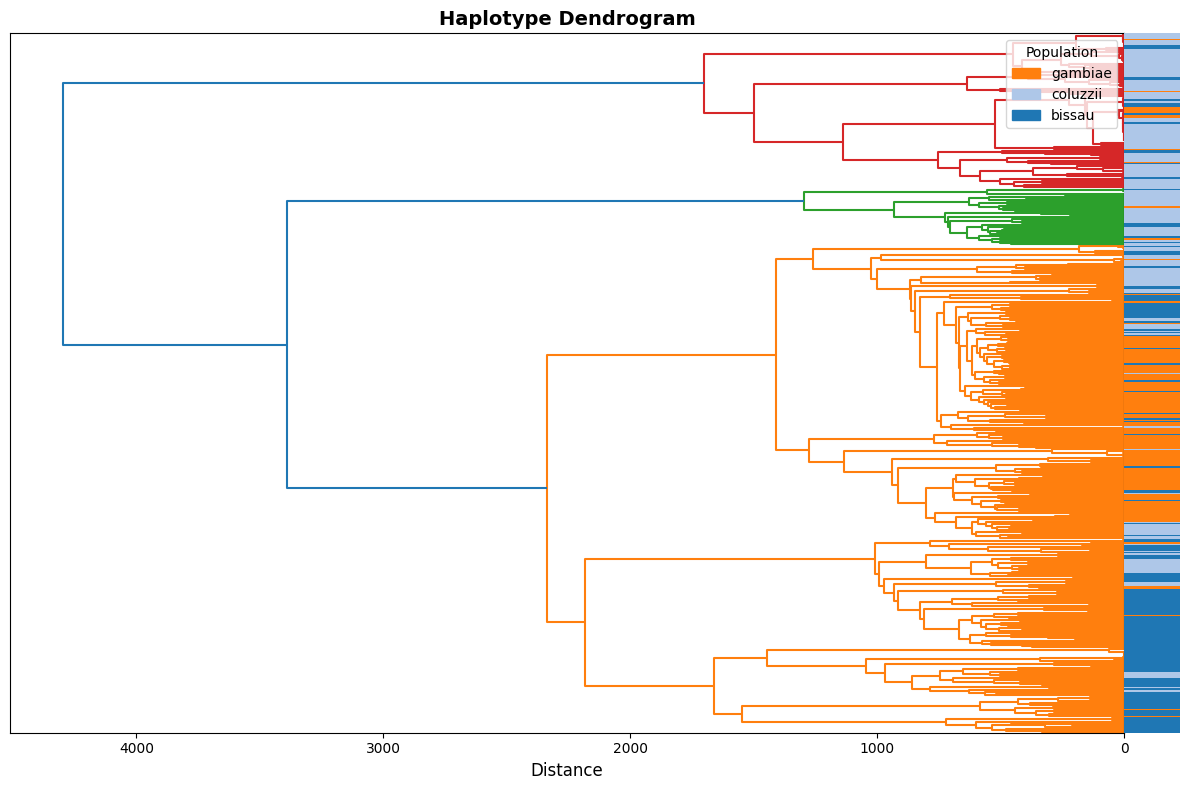

In [ ]:
fig, axe ,matrix, fig = dendrogram_with_leaf_colors(distance_df, labels=haplotype_ids, groups=haplotype_groups, group_to_color=group_to_color,
                               method='ward', figsize=(12, 8),
                               orientation='left', title="Haplotype Dendrogram")

In [ ]:
distance_df

,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,...,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii,coluzzii
coluzzii,0,663,663,568,554,526,581,550,547,697,...,620,604,621,705,590,674,580,572,608,576
coluzzii,663,0,510,631,635,657,630,635,640,524,...,615,627,624,510,667,507,657,675,659,641
coluzzii,663,510,0,613,627,649,662,659,642,566,...,703,603,676,486,647,513,657,619,619,651
coluzzii,568,631,613,0,564,510,543,514,553,633,...,612,586,611,673,552,620,530,560,538,532
coluzzii,554,635,627,564,0,560,547,588,569,619,...,608,580,591,659,596,630,572,558,576,580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
coluzzii,674,507,513,620,630,658,621,664,637,525,...,614,584,695,517,664,0,648,636,610,656
coluzzii,580,657,657,530,572,456,471,474,499,647,...,530,538,583,679,530,648,0,520,544,530
coluzzii,572,675,619,560,558,498,409,532,487,639,...,580,524,563,661,516,636,520,0,474,432
coluzzii,608,659,619,538,576,528,499,500,511,655,...,604,476,571,631,516,610,544,474,0,484


Creating Anopheles-style dendrogram...
Samples: 64
Populations: {'Bissau': 23, 'An. coluzzii': 21, 'An. gambiae': 20}


/tmp/ipython-input-32-2953622313.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


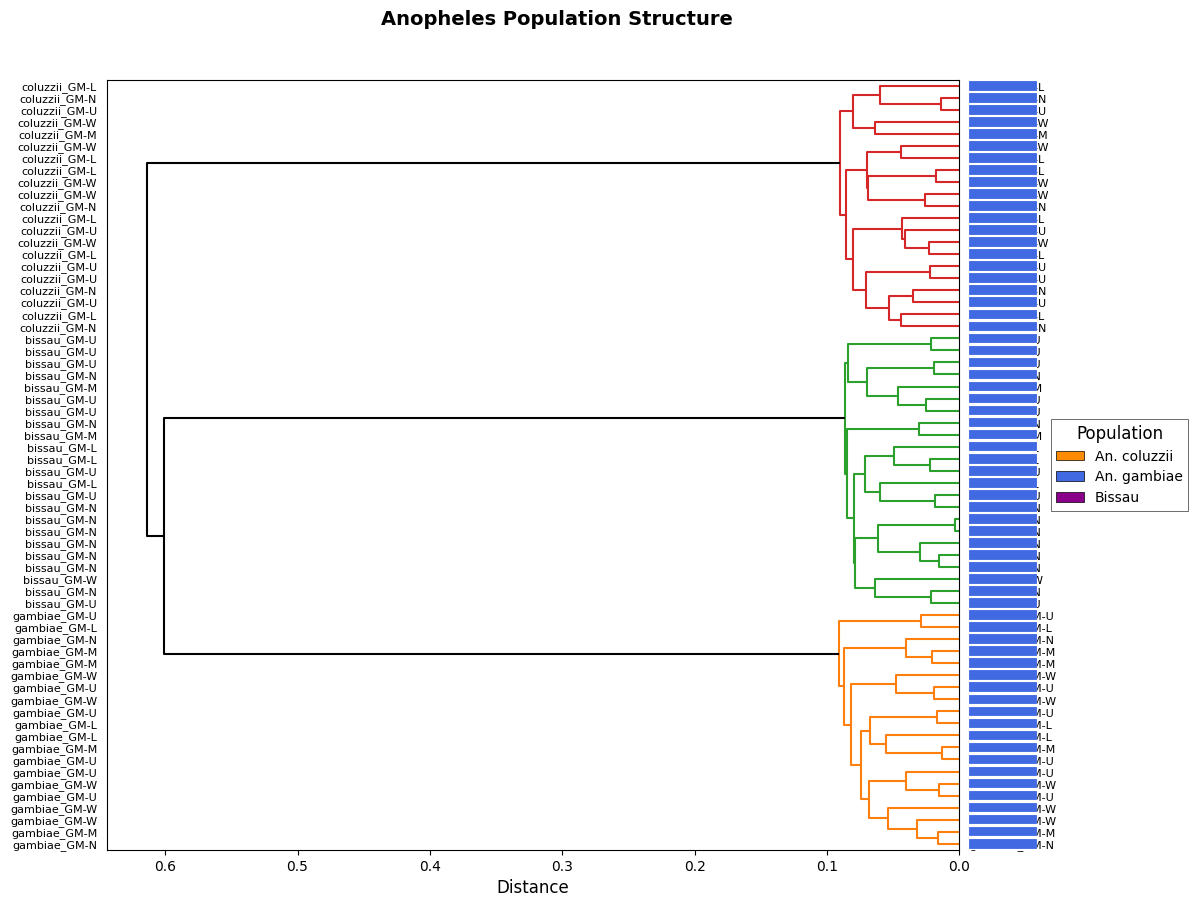

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.patches as mpatches

def create_anopheles_style_dendrogram(distance_matrix, sample_metadata,
                                    population_col='Population',
                                    method='average', figsize=(12, 10),
                                    title="Population Structure Analysis"):
    """
    Create dendrogram exactly like the Anopheles example shown

    Parameters:
    - distance_matrix: square distance matrix (samples x samples)
    - sample_metadata: DataFrame with sample info, index must match distance_matrix
    - population_col: column name in sample_metadata for population groups
    - method: linkage method for clustering
    - figsize: figure size tuple
    - title: plot title
    """

    # Process distance matrix
    if isinstance(distance_matrix, pd.DataFrame):
        labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)
        labels = [f"Sample_{i}" for i in range(len(dist_array))]

    # Get population assignments
    populations = sample_metadata.loc[labels, population_col]
    unique_populations = populations.unique()

    # Define colors for populations (matching the Anopheles style)
    population_colors = {
        unique_populations[0]: '#FF8C00',  # Orange (like An. coluzzii)
        unique_populations[1]: '#4169E1',  # Blue (like An. gambiae s.s)
        unique_populations[2]: '#8B008B',  # Purple (like Bissau)
    }

    # Add more colors if needed
    if len(unique_populations) > 3:
        extra_colors = ['#228B22', '#DC143C', '#00CED1', '#FFD700', '#FF69B4']
        for i, pop in enumerate(unique_populations[3:]):
            if i < len(extra_colors):
                population_colors[pop] = extra_colors[i]
            else:
                population_colors[pop] = '#808080'  # Gray for extras

    # Perform hierarchical clustering
    condensed_dist = squareform(dist_array, checks=False)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create figure with specific layout (dendrogram + thin color bar)
    fig, (ax_dendro, ax_colors) = plt.subplots(1, 2, figsize=figsize,
                                              gridspec_kw={'width_ratios': [10, 0.8], 'wspace': 0.02})

    # Create dendrogram
    dendro = dendrogram(
        linkage_matrix,
        labels=labels,
        orientation='left',
        distance_sort='descending',
        show_leaf_counts=False,
        leaf_font_size=8,
        ax=ax_dendro,
        color_threshold=None,
        above_threshold_color='black'
    )

    # Get the reordered sample order from dendrogram
    reordered_labels = dendro['ivl']
    reordered_populations = populations.loc[reordered_labels]

    # Create population color array
    color_array = [population_colors[pop] for pop in reordered_populations]

    # Create colored bars - positioned exactly at leaf level
    n_samples = len(reordered_labels)
    y_positions = range(n_samples)  # This matches the dendrogram y-positions

    # Plot horizontal bars
    ax_colors.barh(y_positions, [1] * n_samples,
                  color=color_array, height=0.8,
                  edgecolor='white', linewidth=0.1)

    # Format color bar axis
    ax_colors.set_xlim(0, 1)
    ax_colors.set_ylim(-0.5, n_samples - 0.5)
    ax_colors.set_yticks([])
    ax_colors.set_xticks([])
    ax_colors.invert_yaxis()  # Match dendrogram orientation

    # Remove all spines from color bar
    for spine in ax_colors.spines.values():
        spine.set_visible(False)

    # Format main dendrogram
    ax_dendro.set_xlabel('Distance', fontsize=12)
    ax_dendro.set_ylabel('')
    ax_dendro.tick_params(axis='y', which='both', left=False, right=False, labelleft=True)

    # Create legend exactly like the example
    legend_elements = []
    for pop in unique_populations:
        legend_elements.append(
            mpatches.Rectangle((0, 0), 1, 1, facecolor=population_colors[pop],
                             edgecolor='black', linewidth=0.5, label=pop)
        )

    # Position legend like in the example
    legend = ax_colors.legend(handles=legend_elements,
                            title='Population',
                            loc='center left',
                            bbox_to_anchor=(1.1, 0.5),
                            frameon=True,
                            fancybox=False,
                            shadow=False,
                            fontsize=10,
                            title_fontsize=12)

    # Style the legend to match the example
    legend.get_frame().set_linewidth(0.5)
    legend.get_frame().set_edgecolor('black')

    # Set overall title
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.95)

    plt.tight_layout()
    return fig, (ax_dendro, ax_colors), linkage_matrix, dendro, population_colors

# Function to prepare your data in the right format
def prepare_anopheles_data(distance_file, metadata_file,
                          sample_col='Sample_ID', population_col='Population'):
    """
    Load and prepare data in the format needed for the dendrogram

    Parameters:
    - distance_file: path to distance matrix CSV (samples as rows/columns)
    - metadata_file: path to metadata CSV
    - sample_col: column name for sample IDs in metadata
    - population_col: column name for population groups in metadata
    """

    # Load distance matrix
    distance_matrix = pd.read_csv(distance_file, index_col=0)

    # Load metadata
    metadata = pd.read_csv(metadata_file)

    # Set sample names as index if needed
    if sample_col in metadata.columns:
        metadata = metadata.set_index(sample_col)

    # Check that sample names match
    missing_samples = set(distance_matrix.index) - set(metadata.index)
    if missing_samples:
        print(f"Warning: These samples in distance matrix are missing from metadata: {missing_samples}")

    # Filter metadata to only include samples in distance matrix
    metadata_filtered = metadata.loc[metadata.index.intersection(distance_matrix.index)]

    return distance_matrix, metadata_filtered

# Example usage function
def example_anopheles_style():
    """
    Example showing how to create the Anopheles-style plot
    """

    # Create sample data that mimics the Anopheles dataset
    np.random.seed(42)

    # Sample names like in the example
    populations = ['coluzzii', 'gambiae', 'bissau']
    locations = ['GM-M', 'GM-N', 'GM-W', 'GM-U', 'GM-L']

    sample_names = []
    sample_populations = []

    # Create samples for each population
    for pop in populations:
        n_samples = np.random.randint(15, 25)  # Random number of samples per population
        for i in range(n_samples):
            location = np.random.choice(locations)
            sample_name = f"{pop}_{location}"
            sample_names.append(sample_name)
            sample_populations.append(f"An. {pop}" if pop != 'bissau' else 'Bissau')

    n_total = len(sample_names)

    # Create sample metadata
    sample_metadata = pd.DataFrame({
        'Population': sample_populations,
        'Species': ['Anopheles'] * n_total,
        'Location': [name.split('_')[1] for name in sample_names]
    }, index=sample_names)

    # Create distance matrix with population structure
    distances = np.random.rand(n_total, n_total) * 0.8

    # Add population structure (same population = more similar)
    for i, pop_i in enumerate(sample_populations):
        for j, pop_j in enumerate(sample_populations):
            if pop_i == pop_j and i != j:
                distances[i, j] *= 0.2  # Same population = very similar
            elif pop_i != pop_j:
                distances[i, j] *= 1.5  # Different population = more different

    # Make symmetric and zero diagonal
    distances = (distances + distances.T) / 2
    np.fill_diagonal(distances, 0)

    distance_df = pd.DataFrame(distances, index=sample_names, columns=sample_names)

    print("Creating Anopheles-style dendrogram...")
    print(f"Samples: {len(sample_names)}")
    print(f"Populations: {sample_metadata['Population'].value_counts().to_dict()}")

    # Create the plot
    fig, axes, linkage_mat, dendro, colors = create_anopheles_style_dendrogram(
        distance_df, sample_metadata,
        population_col='Population',
        title="Anopheles Population Structure"
    )

    plt.show()

    return distance_df, sample_metadata, colors

# Instructions for your actual data:
"""
STEP 1: Prepare your files

Your distance matrix CSV should look like:
Sample_ID,bissau_GM-M,bissau_GM-N,coluzzii_GM-N,...
bissau_GM-M,0.000,0.142,0.389,...
bissau_GM-N,0.142,0.000,0.356,...
coluzzii_GM-N,0.389,0.356,0.000,...

Your metadata CSV should look like:
Sample_ID,Population,Species,Location
bissau_GM-M,Bissau,Anopheles,GM-M
bissau_GM-N,Bissau,Anopheles,GM-N
coluzzii_GM-N,An. coluzzii,Anopheles,GM-N
gambiae_GM-M,An. gambiae s.s,Anopheles,GM-M

STEP 2: Load and plot your data

# Load your data
distance_matrix, metadata = prepare_anopheles_data(
    'your_distance_matrix.csv',
    'your_sample_metadata.csv'
)

# Create the plot
fig, axes, linkage_mat, dendro, colors = create_anopheles_style_dendrogram(
    distance_df, samples_df,
    population_col='taxon',  # or whatever your population column is called
    title="Your Population Analysis"
)

# Save the plot
plt.savefig('population_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()"""
if __name__ == "__main__":
    example_anopheles_style()

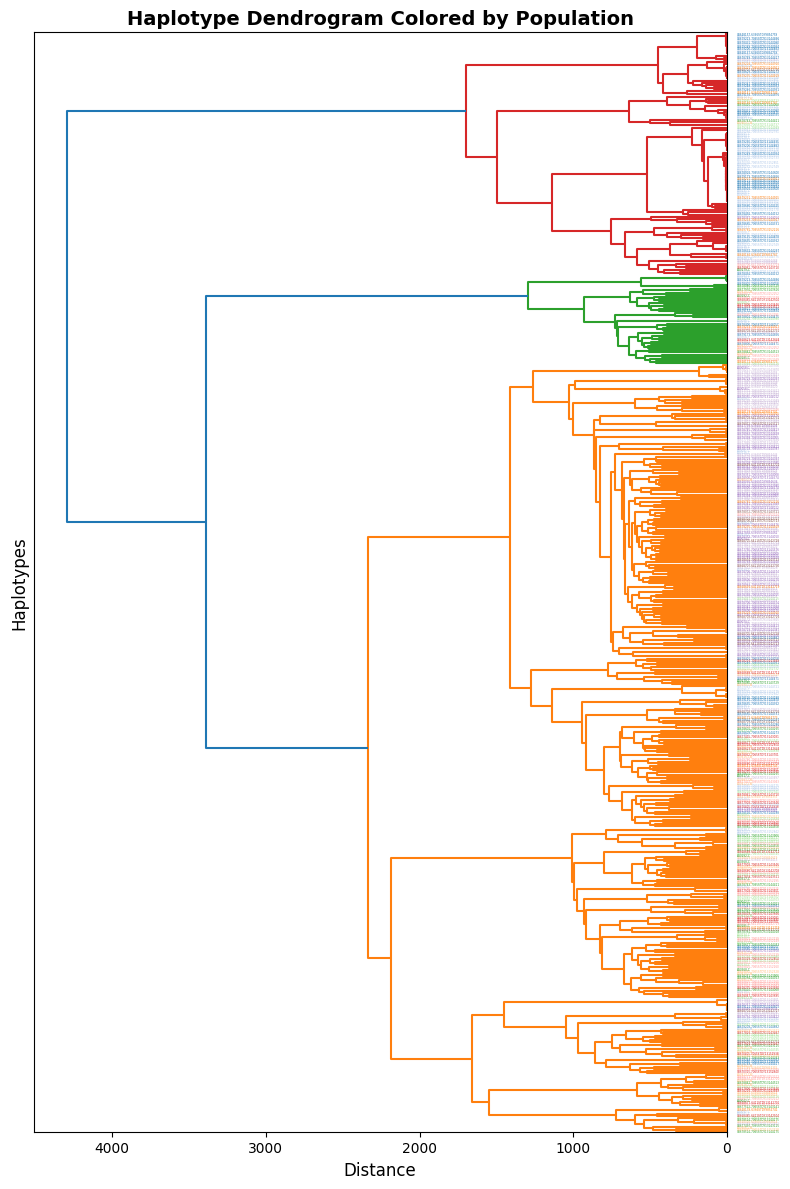

In [ ]:
# Call the dendrogram function
linkage_matrix, dendrogram_plot = create_dendrogram_with_colored_labels(
    distance_matrix=distance_df,
    labels=haplotype_ids,
    groups=haplotype_groups,
    group_to_color=group_to_color,
    method='ward',
    figsize=(8, 12),
    title="Haplotype Dendrogram Colored by Population"
)

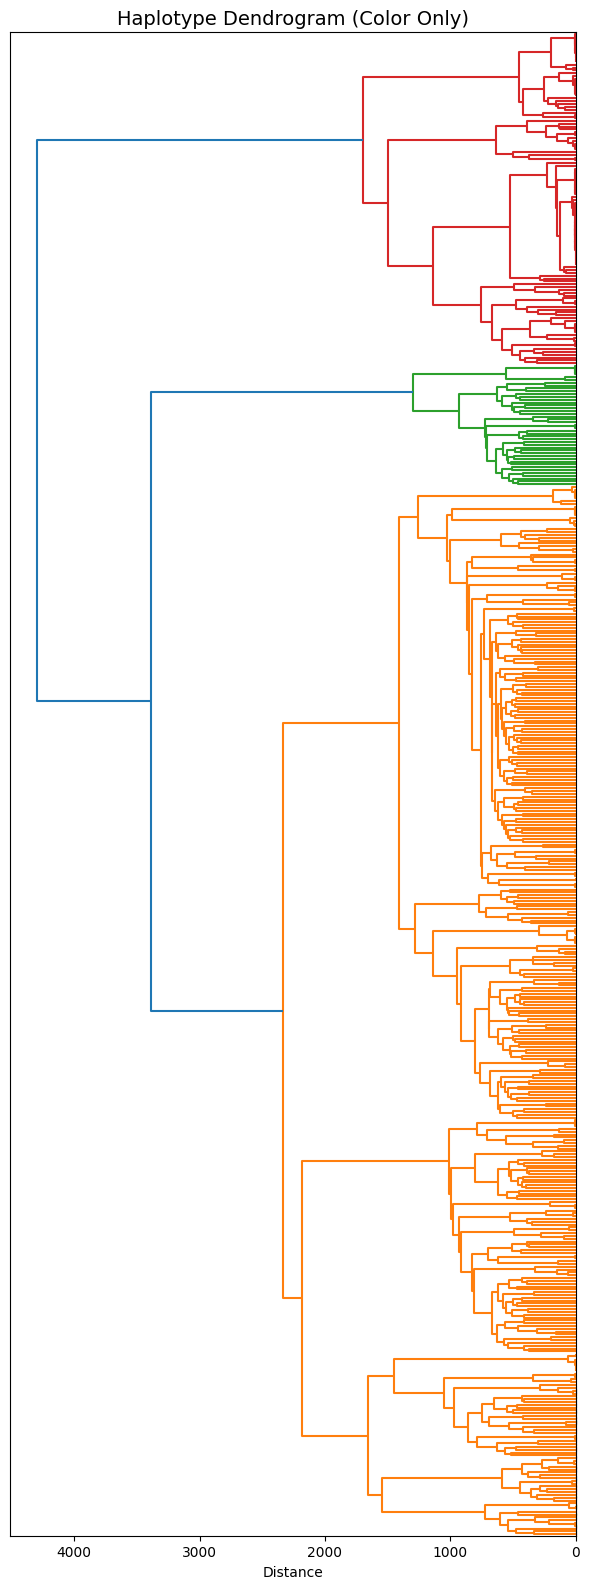

In [ ]:
create_dendrogram_with_color_blocks(
    distance_matrix=distance_df,
    labels=haplotype_ids,
    groups=haplotype_groups,
    group_to_color=group_to_color,
    method='ward',
    figsize=(6, 16),
    title="Haplotype Dendrogram (Color Only)"
)
plt.show()


Sample metadata:
          Population Region    Species   Latitude   Longitude
Sample_01      Pop_A  North  Species_1  34.981605  -83.288826
Sample_02      Pop_A  North  Species_1  58.028572 -111.630368
Sample_03      Pop_A  North  Species_1  49.279758 -102.471321
Sample_04      Pop_A  North  Species_1  43.946339  -98.018289
Sample_05      Pop_A  North  Species_1  26.240746  -92.635801
Sample_06      Pop_A  North  Species_1  26.239781  -72.889442
Sample_07      Pop_A  North  Species_1  22.323344 -108.019573
Sample_08      Pop_B  North  Species_1  54.647046  -89.145934
Sample_09      Pop_B  North  Species_1  44.044600  -84.455126
Sample_10      Pop_B  North  Species_1  48.322903 -117.212975


Creating dendrogram with colored labels...


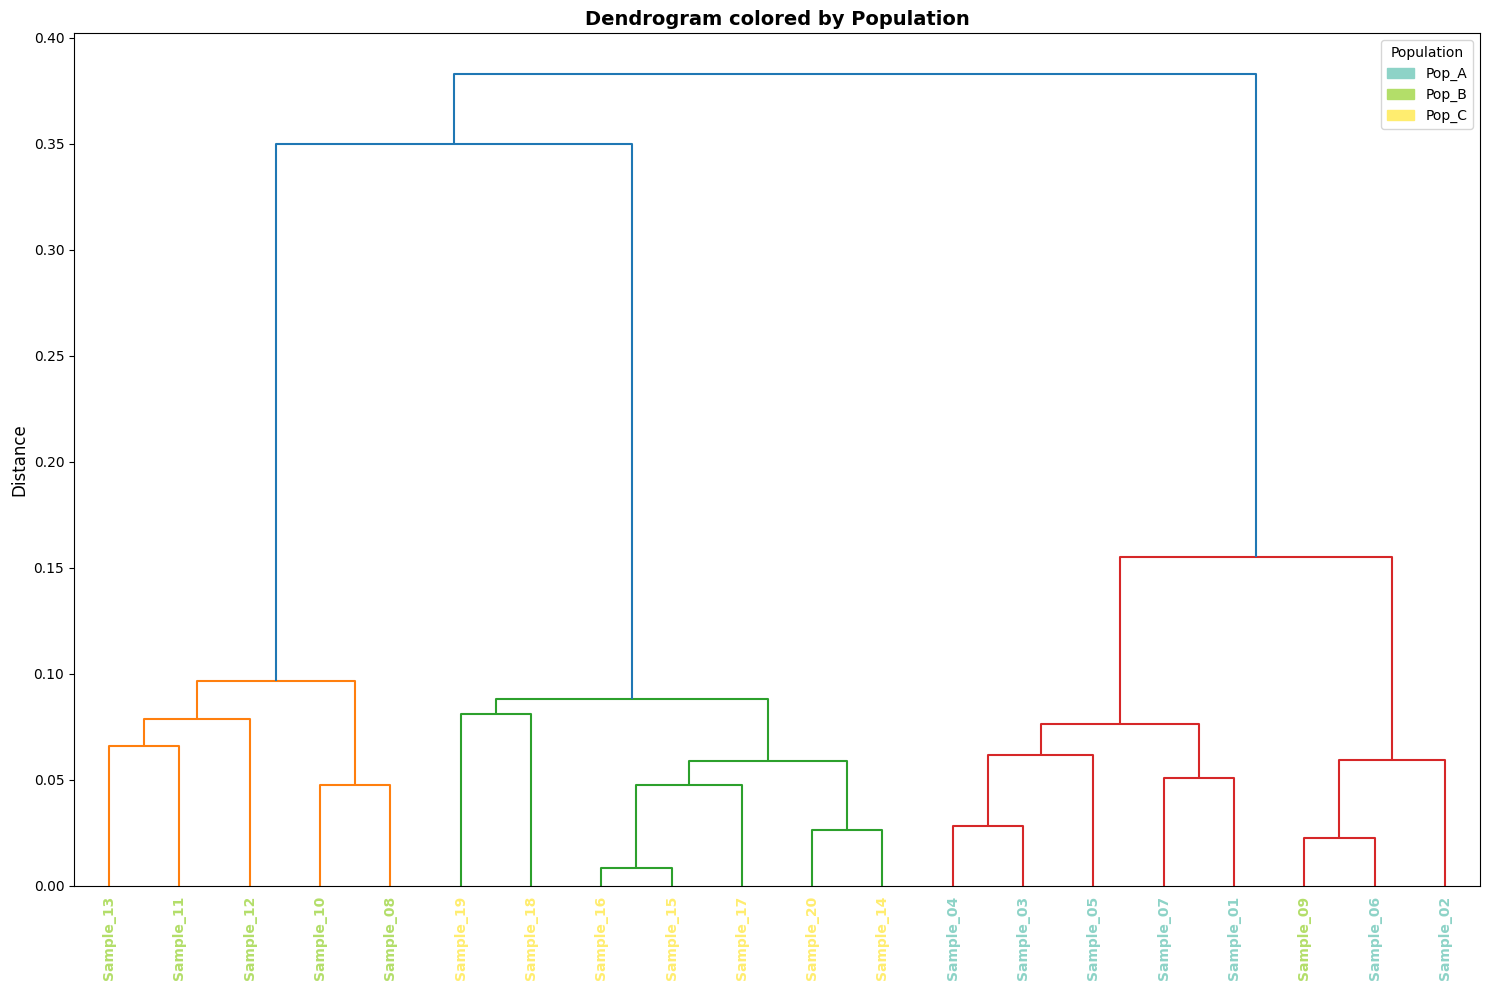

Creating dendrogram with annotation bars...


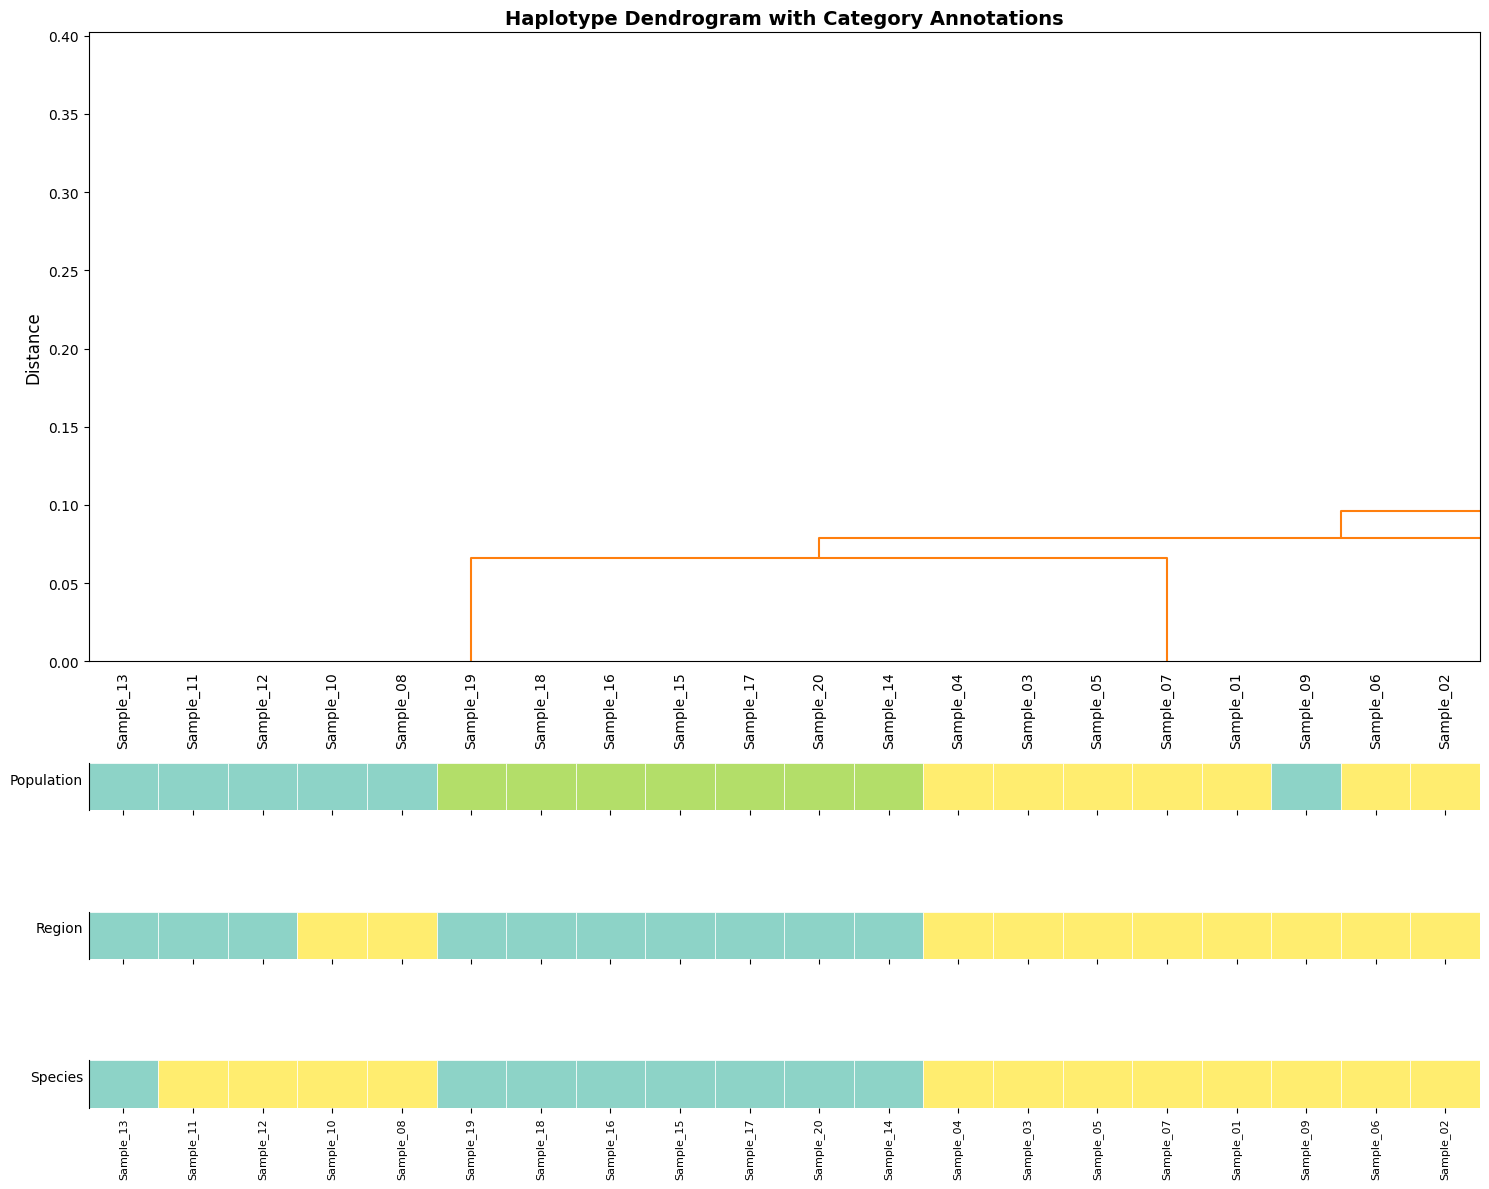

Creating comprehensive dendrogram...


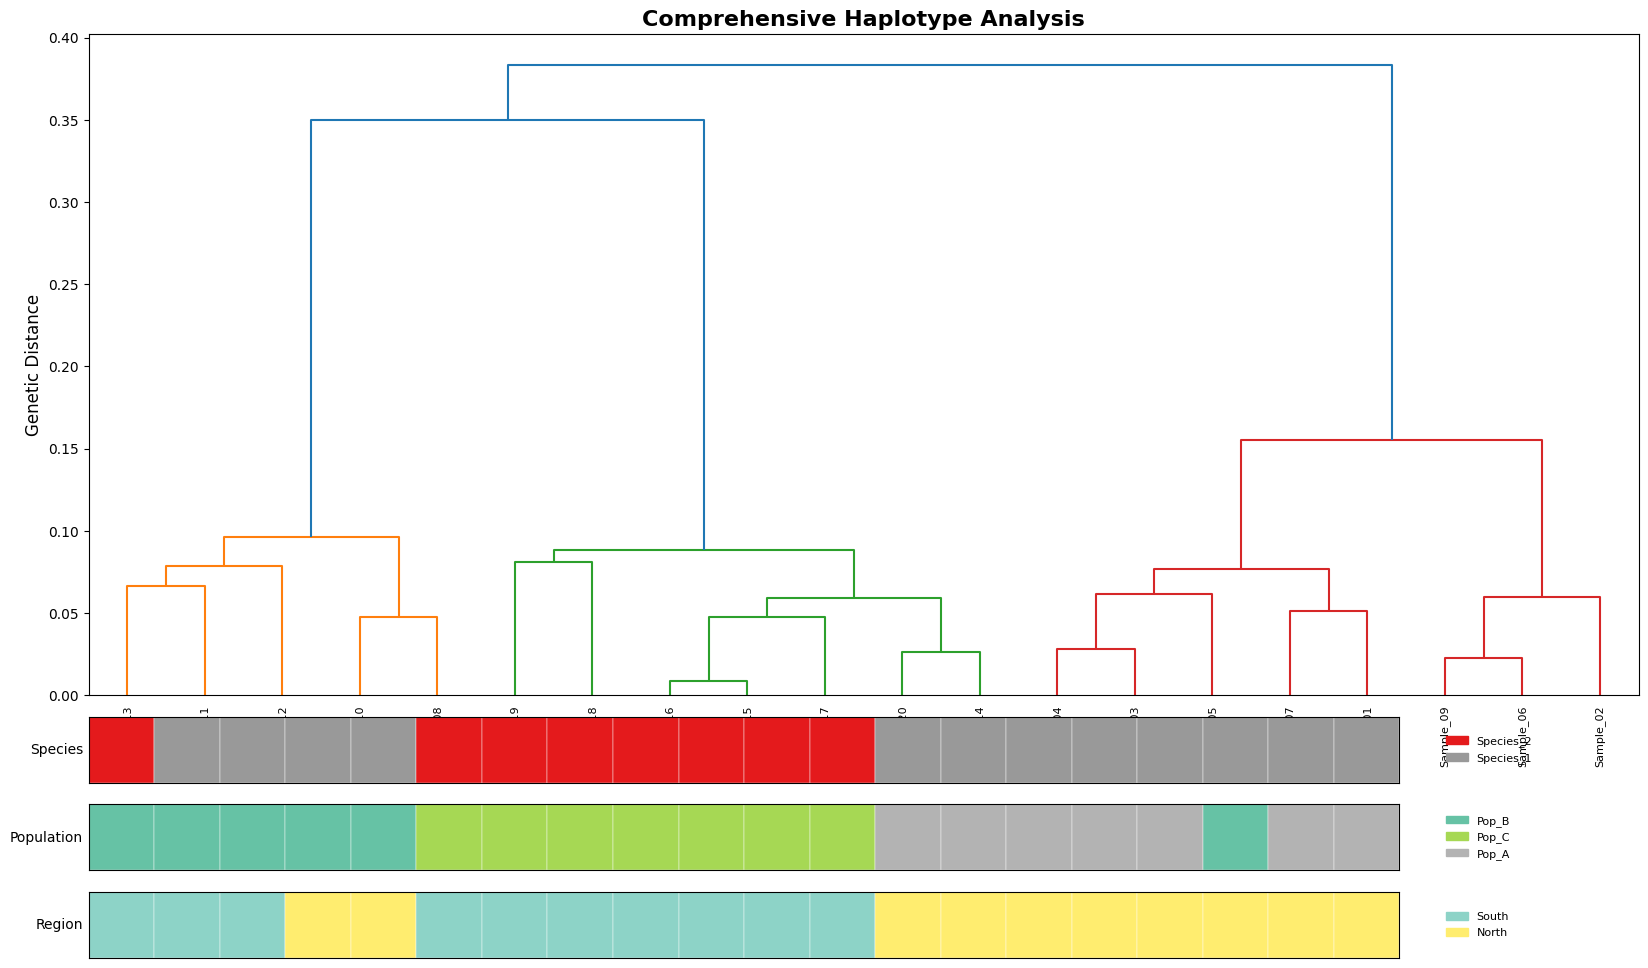

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import seaborn as sns
from collections import defaultdict

# Method 1: Color leaf labels by category
def create_dendrogram_colored_labels(distance_matrix, sample_info,
                                   category_col='Population', method='average',
                                   figsize=(15, 10)):
    """
    Create dendrogram with leaf labels colored by category

    Parameters:
    - distance_matrix: square distance matrix
    - sample_info: DataFrame with sample metadata (must have same index as distance_matrix)
    - category_col: column name in sample_info for coloring
    """

    if isinstance(distance_matrix, pd.DataFrame):
        labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)
        labels = [f"Sample_{i}" for i in range(len(dist_array))]

    # Get categories for each sample
    categories = sample_info.loc[labels, category_col]
    unique_categories = categories.unique()

    # Create color map
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
    color_map = dict(zip(unique_categories, colors))

    # Perform clustering
    condensed_dist = squareform(dist_array)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create dendrogram
    fig, ax = plt.subplots(figsize=figsize)

    dend = dendrogram(linkage_matrix, labels=labels, orientation='top',
                     distance_sort='descending', leaf_rotation=90,
                     leaf_font_size=10, ax=ax)

    # Color the leaf labels
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        sample_name = lbl.get_text()
        if sample_name in categories.index:
            category = categories[sample_name]
            lbl.set_color(color_map[category])
            lbl.set_weight('bold')

    # Create legend
    legend_elements = [patches.Patch(color=color_map[cat], label=cat)
                      for cat in unique_categories]
    ax.legend(handles=legend_elements, loc='upper right',
             title=category_col, frameon=True)

    ax.set_title(f'Dendrogram colored by {category_col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance', fontsize=12)

    plt.tight_layout()
    return fig, ax, color_map

# Method 2: Color bars annotation below dendrogram
def create_dendrogram_with_color_bars(distance_matrix, sample_info,
                                    category_cols=['Population', 'Region'],
                                    method='average', figsize=(15, 12)):
    """
    Create dendrogram with colored annotation bars for multiple categories
    """

    if isinstance(distance_matrix, pd.DataFrame):
        labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)
        labels = [f"Sample_{i}" for i in range(len(dist_array))]

    # Perform clustering
    condensed_dist = squareform(dist_array)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Calculate height ratios
    n_categories = len(category_cols)
    height_ratios = [4] + [0.3] * n_categories  # Main plot + category bars

    fig, axes = plt.subplots(n_categories + 1, 1, figsize=figsize,
                            height_ratios=height_ratios, sharex=True)

    if n_categories == 1:
        axes = [axes[0], axes[1]]

    # Main dendrogram
    dend = dendrogram(linkage_matrix, labels=labels, orientation='top',
                     distance_sort='descending', leaf_rotation=90,
                     leaf_font_size=10, ax=axes[0])

    axes[0].set_title('Haplotype Dendrogram with Category Annotations',
                     fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Distance', fontsize=12)

    # Get leaf order from dendrogram
    leaf_order = dend['leaves']
    ordered_labels = [labels[i] for i in leaf_order]

    # Create color bars for each category
    for i, category_col in enumerate(category_cols):
        ax = axes[i + 1]

        # Get categories in dendrogram order
        categories = sample_info.loc[ordered_labels, category_col]
        unique_categories = categories.unique()

        # Create color map
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
        color_map = dict(zip(unique_categories, colors))

        # Create color bar
        bar_colors = [color_map[cat] for cat in categories]
        ax.bar(range(len(categories)), [1] * len(categories),
              color=bar_colors, width=1.0, edgecolor='white', linewidth=0.5)

        ax.set_xlim(-0.5, len(categories) - 0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel(category_col, fontsize=10, rotation=0, ha='right')
        ax.set_yticks([])

        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        if i < len(category_cols) - 1:
            ax.set_xticks([])
        else:
            ax.set_xticks(range(len(categories)))
            ax.set_xticklabels(ordered_labels, rotation=90, fontsize=8)

    plt.tight_layout()
    return fig, axes, dend

# Method 3: Color branches by predominant category
def create_dendrogram_colored_branches(distance_matrix, sample_info,
                                     category_col='Population', method='average',
                                     figsize=(15, 10)):
    """
    Color dendrogram branches based on the predominant category in each clade
    """

    if isinstance(distance_matrix, pd.DataFrame):
        labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)
        labels = [f"Sample_{i}" for i in range(len(dist_array))]

    # Get categories
    categories = sample_info.loc[labels, category_col]
    unique_categories = categories.unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
    color_map = dict(zip(unique_categories, colors))

    # Perform clustering
    condensed_dist = squareform(dist_array)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Function to determine branch colors
    def get_branch_colors(linkage_matrix, categories, color_map):
        branch_colors = {}
        n = len(categories)

        for i, (left, right, dist, count) in enumerate(linkage_matrix):
            left, right = int(left), int(right)
            cluster_id = i + n

            # Get categories for this cluster
            if left < n:  # Leaf node
                left_cats = [categories.iloc[left]]
            else:  # Internal node
                left_cats = branch_colors.get(left, [])

            if right < n:  # Leaf node
                right_cats = [categories.iloc[right]]
            else:  # Internal node
                right_cats = branch_colors.get(right, [])

            # Combine categories
            all_cats = left_cats + right_cats

            # Find most common category
            if all_cats:
                from collections import Counter
                most_common = Counter(all_cats).most_common(1)[0][0]
                branch_colors[cluster_id] = color_map[most_common]
            else:
                branch_colors[cluster_id] = 'black'

        return branch_colors

    # This is a simplified version - for full branch coloring, you'd need
    # to modify the dendrogram plotting function more extensively
    dend = dendrogram(linkage_matrix, labels=labels, orientation='top',
                     distance_sort='descending', leaf_rotation=90,
                     leaf_font_size=10, ax=ax)

    # Color leaf labels as a compromise
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        sample_name = lbl.get_text()
        if sample_name in categories.index:
            category = categories[sample_name]
            lbl.set_color(color_map[category])
            lbl.set_weight('bold')

    # Create legend
    legend_elements = [patches.Patch(color=color_map[cat], label=cat)
                      for cat in unique_categories]
    ax.legend(handles=legend_elements, loc='upper right',
             title=category_col, frameon=True)

    ax.set_title(f'Dendrogram with {category_col} coloring', fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance', fontsize=12)

    plt.tight_layout()
    return fig, ax

# Method 4: Multiple category heatmap style
def create_comprehensive_dendrogram(distance_matrix, sample_info,
                                  category_cols=['Species', 'Population', 'Region'],
                                  method='average', figsize=(20, 12)):
    """
    Create comprehensive dendrogram visualization with multiple annotations
    """

    if isinstance(distance_matrix, pd.DataFrame):
        labels = distance_matrix.index.tolist()
        dist_array = distance_matrix.values
    else:
        dist_array = np.array(distance_matrix)
        labels = [f"Sample_{i}" for i in range(len(dist_array))]

    # Perform clustering
    condensed_dist = squareform(dist_array)
    linkage_matrix = linkage(condensed_dist, method=method)

    # Create complex figure layout
    fig = plt.figure(figsize=figsize)

    # Define grid layout
    gs = fig.add_gridspec(4, 4, height_ratios=[3, 0.3, 0.3, 0.3],
                         width_ratios=[3, 0.1, 0.1, 0.1], hspace=0.1, wspace=0.1)

    # Main dendrogram
    ax_dend = fig.add_subplot(gs[0, :])
    dend = dendrogram(linkage_matrix, labels=labels, orientation='top',
                     distance_sort='descending', leaf_rotation=90,
                     leaf_font_size=8, ax=ax_dend)

    ax_dend.set_title('Comprehensive Haplotype Analysis', fontsize=16, fontweight='bold')
    ax_dend.set_ylabel('Genetic Distance', fontsize=12)

    # Get leaf order
    leaf_order = dend['leaves']
    ordered_labels = [labels[i] for i in leaf_order]

    # Color annotation bars
    for i, category_col in enumerate(category_cols):
        ax_bar = fig.add_subplot(gs[i + 1, 0])

        categories = sample_info.loc[ordered_labels, category_col]
        unique_categories = categories.unique()

        # Use different color palettes for different categories
        if i == 0:
            colors = plt.cm.Set1(np.linspace(0, 1, len(unique_categories)))
        elif i == 1:
            colors = plt.cm.Set2(np.linspace(0, 1, len(unique_categories)))
        else:
            colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))

        color_map = dict(zip(unique_categories, colors))
        bar_colors = [color_map[cat] for cat in categories]

        ax_bar.bar(range(len(categories)), [1] * len(categories),
                  color=bar_colors, width=1.0, edgecolor='white', linewidth=0.3)

        ax_bar.set_xlim(-0.5, len(categories) - 0.5)
        ax_bar.set_ylim(0, 1)
        ax_bar.set_ylabel(category_col, fontsize=10, rotation=0, ha='right', va='center')
        ax_bar.set_yticks([])
        ax_bar.set_xticks([])

        # Create mini legend
        ax_legend = fig.add_subplot(gs[i + 1, 1:])
        ax_legend.axis('off')

        legend_elements = [patches.Patch(color=color_map[cat], label=cat)
                          for cat in unique_categories]
        ax_legend.legend(handles=legend_elements, loc='center left',
                        fontsize=8, ncol=1, frameon=False)

    return fig, dend

# Example usage function
def example_with_metadata():
    """
    Example showing how to use the coloring functions with sample metadata
    """

    # Create sample data
    np.random.seed(42)
    n_samples = 20

    # Create sample metadata
    sample_names = [f"Sample_{i+1:02d}" for i in range(n_samples)]

    # Create geographic/taxonomic groupings
    populations = ['Pop_A'] * 7 + ['Pop_B'] * 6 + ['Pop_C'] * 7
    regions = ['North'] * 10 + ['South'] * 10
    species = ['Species_1'] * 12 + ['Species_2'] * 8

    sample_info = pd.DataFrame({
        'Population': populations,
        'Region': regions,
        'Species': species,
        'Latitude': np.random.uniform(20, 60, n_samples),
        'Longitude': np.random.uniform(-120, -60, n_samples)
    }, index=sample_names)

    # Create sample distance matrix with some structure
    # Samples from same population should be more similar
    distances = np.random.rand(n_samples, n_samples) * 0.5

    # Add population structure
    for i, pop_i in enumerate(populations):
        for j, pop_j in enumerate(populations):
            if pop_i == pop_j and i != j:
                distances[i, j] *= 0.3  # Same population = more similar
            elif pop_i != pop_j:
                distances[i, j] *= 1.5  # Different population = more different

    # Make symmetric and zero diagonal
    distances = (distances + distances.T) / 2
    np.fill_diagonal(distances, 0)

    distance_df = pd.DataFrame(distances, index=sample_names, columns=sample_names)

    print("Sample metadata:")
    print(sample_info.head(10))
    print("\n" + "="*60 + "\n")

    # Method 1: Colored labels
    print("Creating dendrogram with colored labels...")
    fig1, ax1, cmap1 = create_dendrogram_colored_labels(
        distance_df, sample_info, 'Population'
    )
    plt.show()

    # Method 2: Color bars
    print("Creating dendrogram with annotation bars...")
    fig2, axes2, dend2 = create_dendrogram_with_color_bars(
        distance_df, sample_info, ['Population', 'Region', 'Species']
    )
    plt.show()

    # Method 3: Comprehensive view
    print("Creating comprehensive dendrogram...")
    fig3, dend3 = create_comprehensive_dendrogram(
        distance_df, sample_info, ['Species', 'Population', 'Region']
    )
    plt.show()

    return distance_df, sample_info

# Instructions for real data
"""
How to use with your real data:

1. Prepare your metadata file (CSV/Excel):
   - Index should match your distance matrix row/column names
   - Include columns for taxonomic/geographic categories

   Example metadata.csv:
   Sample_ID,Species,Population,Region,Latitude,Longitude
   Hap_001,Homo_sapiens,European,Europe,52.5,13.4
   Hap_002,Homo_sapiens,African,Africa,-1.3,36.8
   ...

2. Load your data:
   distance_matrix = pd.read_csv('your_distances.csv', index_col=0)
   metadata = pd.read_csv('your_metadata.csv', index_col=0)

3. Create colored dendrogram:
   fig, ax, colors = create_dendrogram_colored_labels(
       distance_matrix, metadata, 'Population'
   )
   plt.show()

4. For multiple categories:
   fig, axes, dend = create_dendrogram_with_color_bars(
       distance_matrix, metadata, ['Species', 'Population', 'Region']
   )
   plt.show()
"""

if __name__ == "__main__":
    example_with_metadata()

In [ ]:
# Create sample data
np.random.seed(42)
n_samples = 20

# Create sample metadata
sample_names = [f"Sample_{i+1:02d}" for i in range(n_samples)]

# Create geographic/taxonomic groupings
populations = ['Pop_A'] * 7 + ['Pop_B'] * 6 + ['Pop_C'] * 7
regions = ['North'] * 10 + ['South'] * 10
species = ['Species_1'] * 12 + ['Species_2'] * 8

sample_info = pd.DataFrame({
    'Population': populations,
    'Region': regions,
    'Species': species,
    'Latitude': np.random.uniform(20, 60, n_samples),
    'Longitude': np.random.uniform(-120, -60, n_samples)
}, index=sample_names)

# Create sample distance matrix with some structure
# Samples from same population should be more similar
distances = np.random.rand(n_samples, n_samples) * 0.5

# Add population structure
for i, pop_i in enumerate(populations):
    for j, pop_j in enumerate(populations):
        if pop_i == pop_j and i != j:
            distances[i, j] *= 0.3  # Same population = more similar
        elif pop_i != pop_j:
            distances[i, j] *= 1.5  # Different population = more different

# Make symmetric and zero diagonal
distances = (distances + distances.T) / 2
np.fill_diagonal(distances, 0)

distance_df = pd.DataFrame(distances, index=sample_names, columns=sample_names)
distance_df


,Population,Region,Species,Latitude,Longitude
Sample_01,Pop_A,North,Species_1,34.981605,-83.288826
Sample_02,Pop_A,North,Species_1,58.028572,-111.630368
Sample_03,Pop_A,North,Species_1,49.279758,-102.471321
Sample_04,Pop_A,North,Species_1,43.946339,-98.018289
Sample_05,Pop_A,North,Species_1,26.240746,-92.635801
Sample_06,Pop_A,North,Species_1,26.239781,-72.889442
Sample_07,Pop_A,North,Species_1,22.323344,-108.019573
Sample_08,Pop_B,North,Species_1,54.647046,-89.145934
Sample_09,Pop_B,North,Species_1,44.044600,-84.455126
Sample_10,Pop_B,North,Species_1,48.322903,-117.212975


In [ ]:
print("Creating dendrogram with colored labels...")
fig1, ax1, cmap1 = create_dendrogram_colored_labels(
    distance_df, sample_info, 'Population'
)
plt.show()

Creating dendrogram with colored labels...


KeyError: "None of [Index(['VBS68485-6411STDY13142504', 'VBS68485-6411STDY13142504',\n       'VBS68623-6411STDY13142644', 'VBS68623-6411STDY13142644',\n       'VBS68677-6411STDY13142700', 'VBS68677-6411STDY13142700',\n       'VBS68680-6411STDY13142703', 'VBS68680-6411STDY13142703',\n       'VBS68689-6411STDY13142712', 'VBS68689-6411STDY13142712',\n       ...\n       'AG0279-C', 'AG0279-C', 'AG0285-C', 'AG0285-C', 'AG0292-C', 'AG0292-C',\n       'AG0317-C', 'AG0317-C', 'AG0368-C', 'AG0368-C'],\n      dtype='object', length=534)] are in the [index]"

In [ ]:
# Load the saved haplotype data
with open('haplotype_dict.json', 'r') as fp:
    haplotype_dict_loaded = json.load(fp)

# Convert back to NumPy arrays
dist = np.array(haplotype_dict_loaded["dist"])
phased_sample = np.array(haplotype_dict_loaded["phased_sample"])
n_snp = haplotype_dict_loaded["n_snp"]

sample_metadata = pd.read_csv('sample_metadata (2).csv')
samples_df = sample_metadata[sample_metadata['sample_id'].isin(phased_sample.tolist())].copy()
samples_df["sample_pop"] = samples_df["taxon"] + "_" + samples_df["admin1_iso"]
# Samples list
samples_list = list(samples_df['sample_id'].values)

# Align sample metadata with haplotypes.
df_samples_phased = (
    samples_df.set_index("sample_id").loc[phased_sample.tolist()].reset_index()
)

# Ensure correct distance matrix format
if len(dist.shape) == 1:  # If dist is condensed (1D)
    distance_matrix_sq = squareform(dist)
else:
    distance_matrix_sq = dist  # Already square

# Repeat metadata so there is one row per haplotype
df_haps = pd.DataFrame(np.repeat(df_samples_phased.values, 2, axis=0))
df_haps.columns = df_samples_phased.columns  # Restore column names

# Ensure haplotype IDs match the distance matrix shape
#haplotype_ids = list(df_haps["sample_pop"].values)  # Use the repeated sample IDs for haplotypes
haplotype_ids = list(df_haps["sample_id"].values)  # Use the repeated sample IDs for haplotypes

# Validate matrix and haplotype list size
assert distance_matrix_sq.shape == (len(haplotype_ids), len(haplotype_ids)), \
    f"Mismatch: Distance matrix shape {distance_matrix_sq.shape} vs. haplotype list {len(haplotype_ids)}"

# Perform hierarchical clustering using the condensed form of distances
#linkage_matrix = sch.linkage(dist, method='ward')

# Convert distance matrix to DataFrame with correct haplotype IDs
distance_df = pd.DataFrame(distance_matrix_sq, index=haplotype_ids, columns=haplotype_ids)
samples_df.set_index('sample_id', inplace=True)

Creating comprehensive dendrogram...


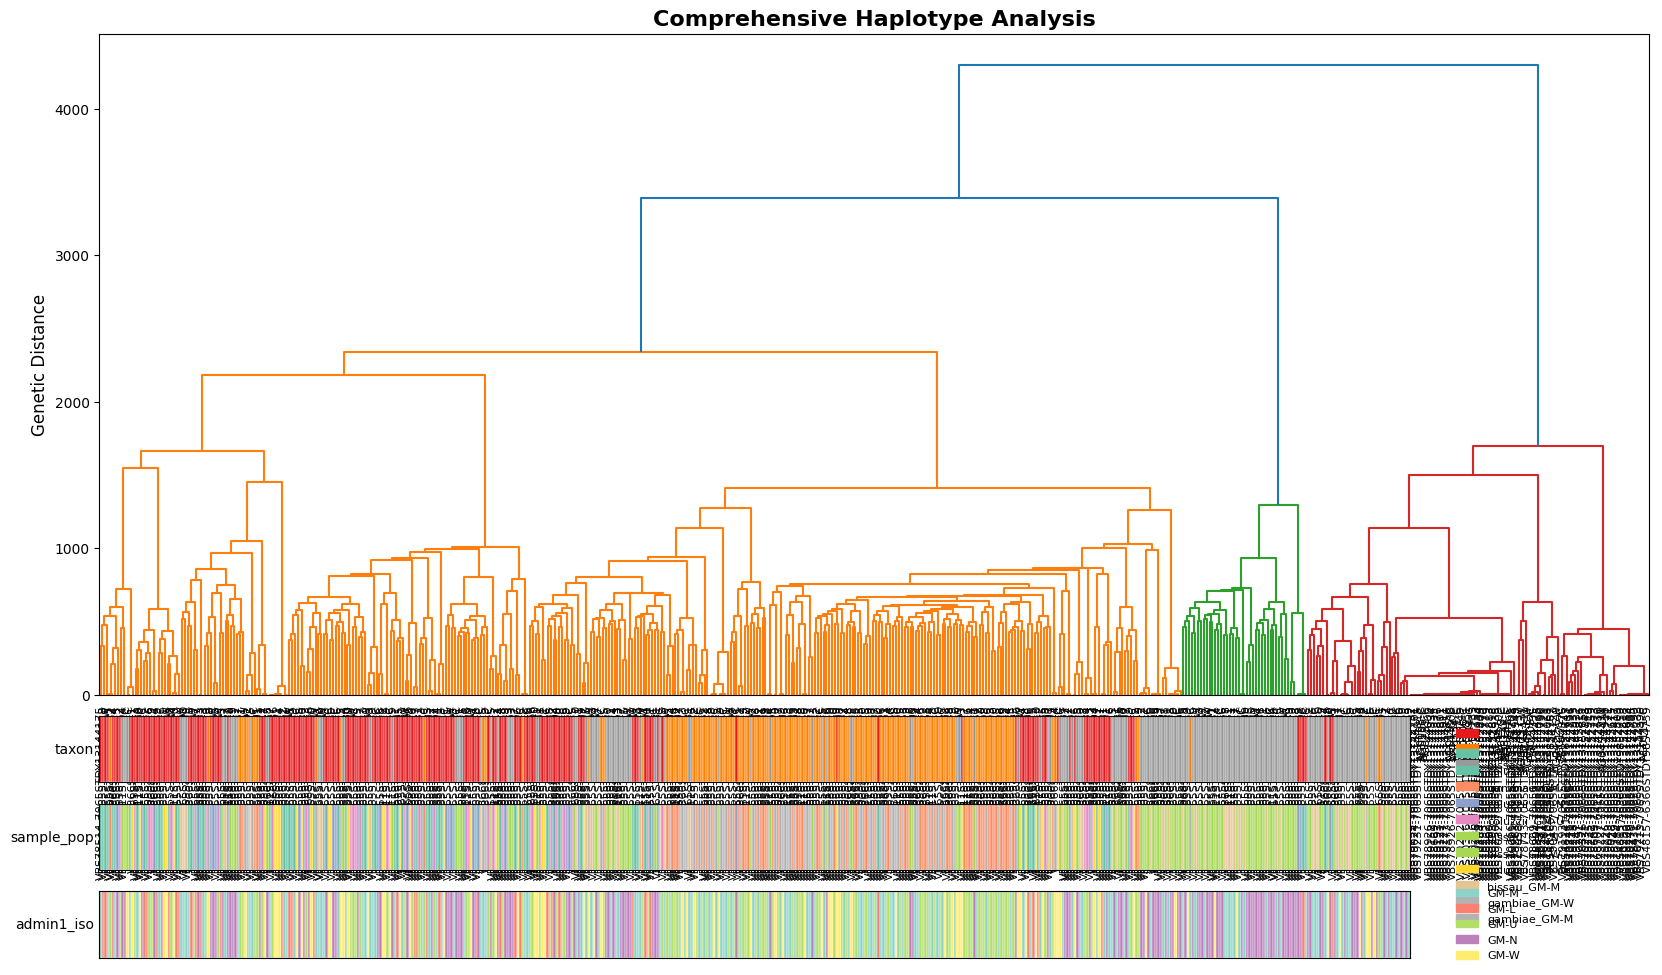

Generating simulated diploid data...
Generated simulated data:
- 50 samples (100 haplotypes)
- Distance matrix: (100, 100)
- Taxa: {np.str_('quadriannulatus'), np.str_('melas'), np.str_('arabiensis'), np.str_('merus'), np.str_('coluzzii'), np.str_('gambiae')}
- Locations: {np.str_('GH-UW'), np.str_('CM-CE'), np.str_('ML-1'), np.str_('SN-DK'), np.str_('CI-06'), np.str_('BF-01'), np.str_('GM-B'), np.str_('NG-LA')}
- Files saved: simulated_distance_data.json, simulated_metadata.csv

Loading and processing diploid data...

Diploid data processing completed!
=== Diploid Sample Statistics ===
Total unique samples: 50
Total haplotypes: 100

Haplotypes by Taxon:
  arabiensis: 24 haplotypes (12 samples)
  coluzzii: 22 haplotypes (11 samples)
  gambiae: 28 haplotypes (14 samples)
  melas: 10 haplotypes (5 samples)
  merus: 6 haplotypes (3 samples)
  quadriannulatus: 10 haplotypes (5 samples)

Haplotypes by Location:
  BF-01: 14 haplotypes (7 samples)
  CI-06: 18 haplotypes (9 samples)
  CM-CE: 1

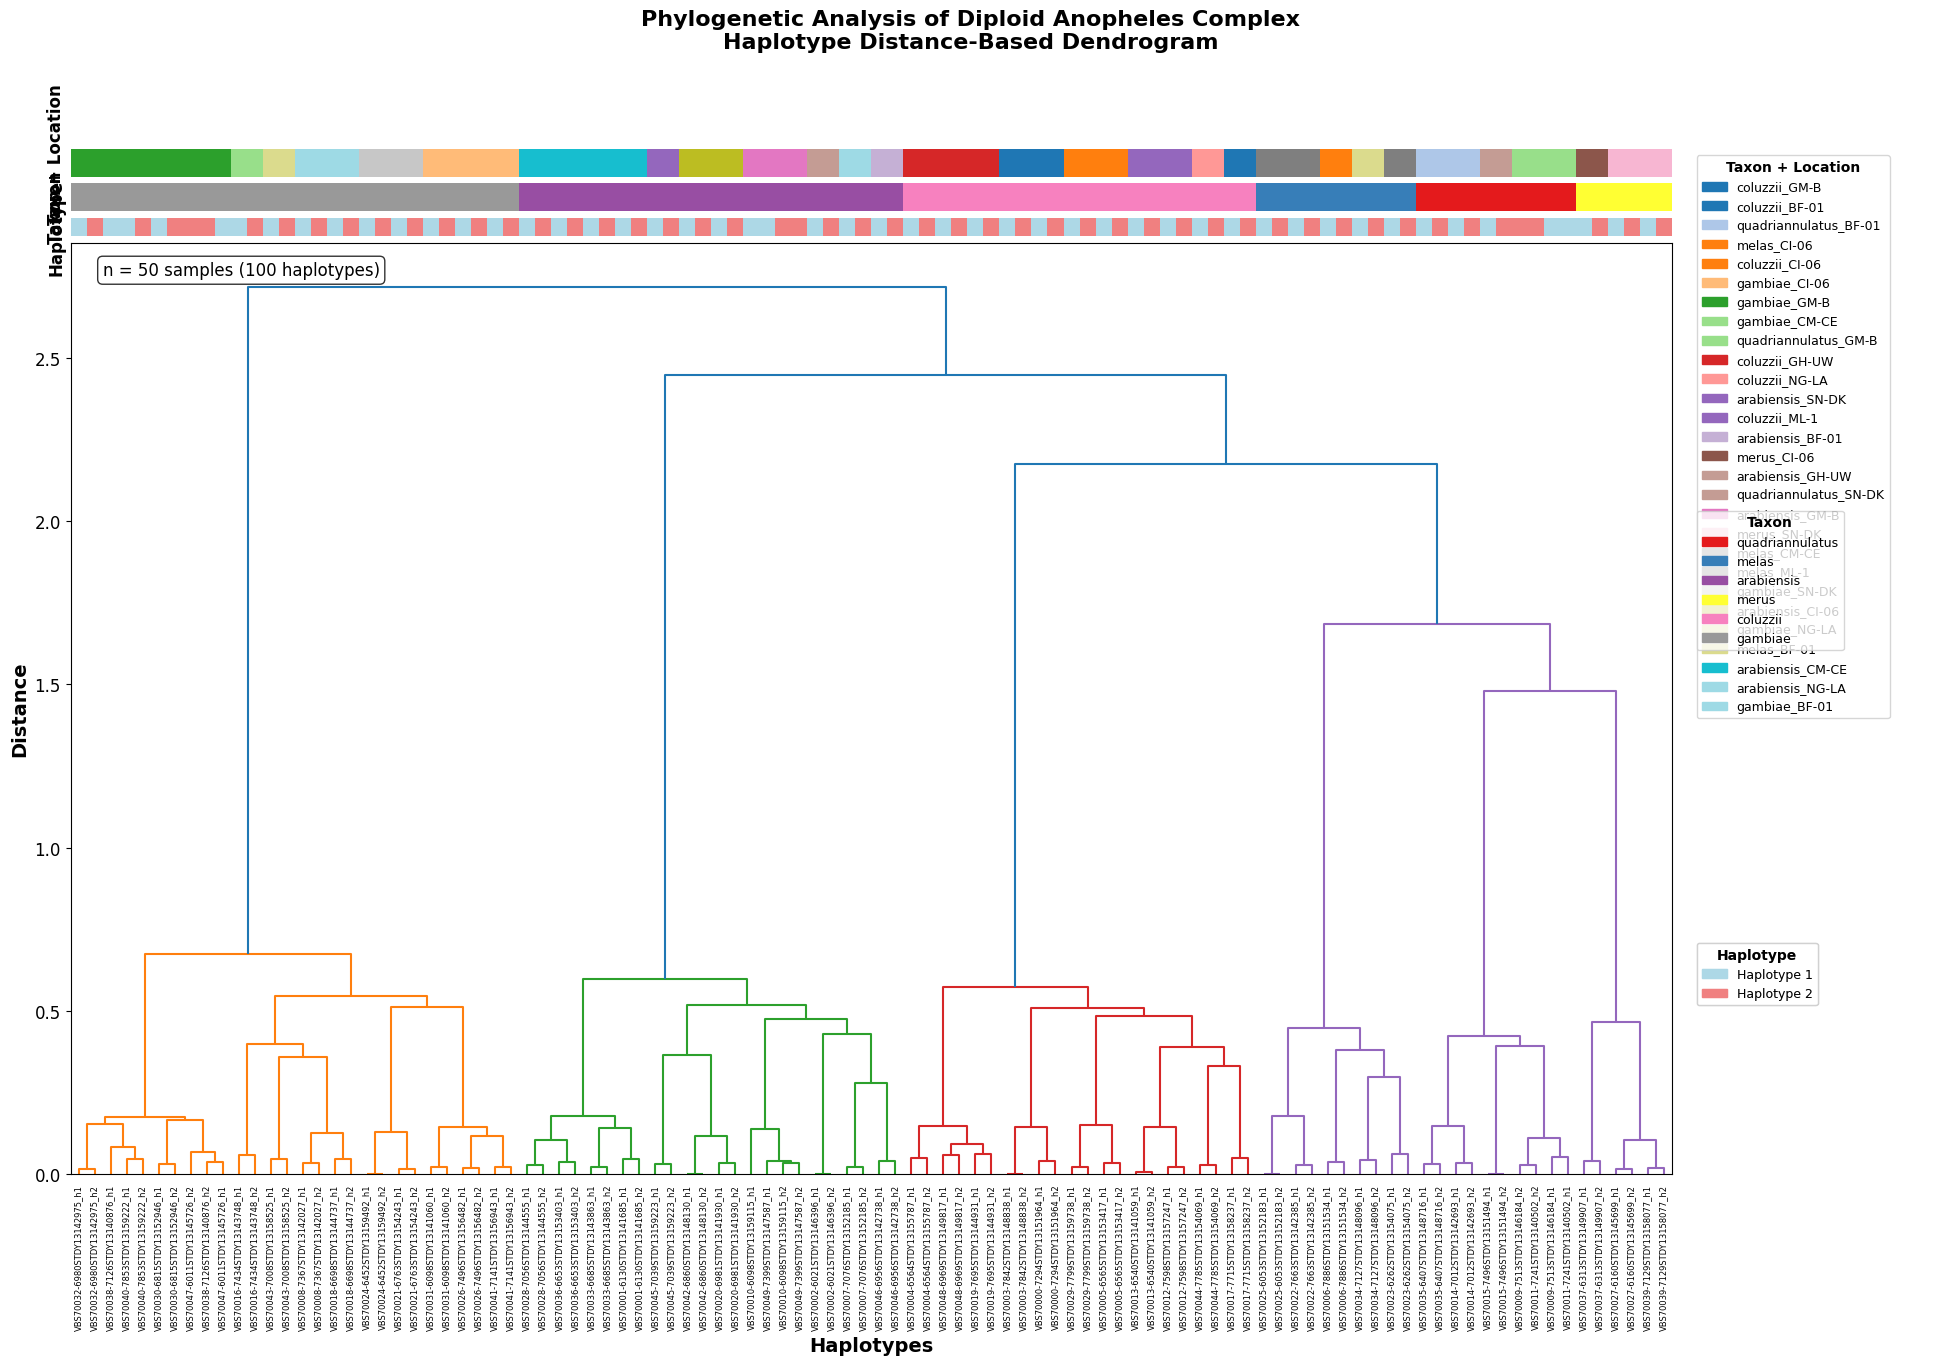

Diploid dendrogram saved as 'anopheles_diploid_dendrogram.png'
Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def generate_simulated_data(n_samples=100, output_json='simulated_distance_data.json',
                          output_metadata='simulated_metadata.csv'):
    """
    Generate simulated diploid data for Anopheles complex
    """
    np.random.seed(42)  # For reproducibility

    # Define realistic taxa and locations for Anopheles complex
    taxa = ['gambiae', 'coluzzii', 'arabiensis', 'quadriannulatus', 'melas', 'merus']
    admin1_isos = ['BF-01', 'GH-UW', 'ML-1', 'SN-DK', 'GM-B', 'CI-06', 'NG-LA', 'CM-CE']
    countries = ['Burkina Faso', 'Ghana', 'Mali', 'Senegal', 'Gambia', 'Ivory Coast', 'Nigeria', 'Cameroon']

    # Create sample metadata
    metadata_list = []
    for i in range(n_samples):
        taxon = np.random.choice(taxa, p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05])  # Weighted by common species
        admin1_iso = np.random.choice(admin1_isos)
        country = countries[admin1_isos.index(admin1_iso)]

        sample_id = f"VBS{70000 + i:05d}-{np.random.randint(6000, 8000)}STDY{np.random.randint(13140000, 13160000)}"

        metadata_list.append({
            'sample_id': sample_id,
            'taxon': taxon,
            'admin1_iso': admin1_iso,
            'country': country,
            'latitude': np.random.uniform(4, 16),  # West African latitudes
            'longitude': np.random.uniform(-17, 15),  # West African longitudes
            'year': np.random.randint(2015, 2024),
            'sex_call': np.random.choice(['F', 'M'], p=[0.7, 0.3]),  # More females typical
            'mean_cov': np.random.uniform(15, 60)
        })

    # Create metadata DataFrame
    metadata_df = pd.DataFrame(metadata_list)

    # For diploid organisms, each sample has 2 haplotypes
    phased_sample_ids = []
    for _, row in metadata_df.iterrows():
        # Add both haplotypes for each sample
        phased_sample_ids.append(f"{row['sample_id']}_hap1")
        phased_sample_ids.append(f"{row['sample_id']}_hap2")

    n_haplotypes = len(phased_sample_ids)

    # Generate realistic distance matrix
    # Create block structure based on taxa and geographic location
    distance_matrix = np.zeros((n_haplotypes, n_haplotypes))

    # Fill distance matrix with realistic patterns
    for i in range(n_haplotypes):
        for j in range(i+1, n_haplotypes):
            # Get sample info for haplotypes
            sample_i_idx = i // 2
            sample_j_idx = j // 2

            taxon_i = metadata_df.iloc[sample_i_idx]['taxon']
            taxon_j = metadata_df.iloc[sample_j_idx]['taxon']
            admin1_i = metadata_df.iloc[sample_i_idx]['admin1_iso']
            admin1_j = metadata_df.iloc[sample_j_idx]['admin1_iso']

            # Base distance
            if i // 2 == j // 2:  # Same sample, different haplotypes
                base_distance = np.random.uniform(0.01, 0.05)
            elif taxon_i == taxon_j and admin1_i == admin1_j:  # Same species, same location
                base_distance = np.random.uniform(0.05, 0.15)
            elif taxon_i == taxon_j:  # Same species, different location
                base_distance = np.random.uniform(0.15, 0.35)
            else:  # Different species
                base_distance = np.random.uniform(0.35, 0.8)

            # Add some noise
            distance = base_distance + np.random.normal(0, 0.02)
            distance = max(0.001, distance)  # Ensure positive distances

            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    # Ensure diagonal is exactly zero (required for scipy distance functions)
    np.fill_diagonal(distance_matrix, 0.0)

    # Create JSON data structure
    json_data = {
        'dist': distance_matrix.tolist(),
        'phased_sample': phased_sample_ids,
        'SNPs': np.random.randint(50000, 150000)  # Simulated SNP count
    }

    # Save files
    with open(output_json, 'w') as f:
        json.dump(json_data, f, indent=2)

    metadata_df.to_csv(output_metadata, index=False)

    print(f"Generated simulated data:")
    print(f"- {n_samples} samples ({n_haplotypes} haplotypes)")
    print(f"- Distance matrix: {distance_matrix.shape}")
    print(f"- Taxa: {set(metadata_df['taxon'])}")
    print(f"- Locations: {set(metadata_df['admin1_iso'])}")
    print(f"- Files saved: {output_json}, {output_metadata}")

    return json_data, metadata_df

def load_and_process_diploid_data(json_file_path, metadata_file_path):
    """
    Load and process diploid JSON distance data and metadata
    """
    # Load JSON data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # Extract components
    distance_matrix = np.array(data['dist'])
    phased_sample_ids = data['phased_sample']

    # Ensure distance matrix is properly formatted
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Load metadata
    metadata = pd.read_csv(metadata_file_path)

    # Process diploid data - each sample has 2 haplotypes
    sample_info = []
    matched_indices = []

    for i, phased_id in enumerate(phased_sample_ids):
        # Extract base sample ID (remove _hap1, _hap2 suffix)
        if '_hap' in phased_id:
            base_sample_id = phased_id.split('_hap')[0]
            haplotype = phased_id.split('_hap')[1]
        else:
            # Fallback - assume alternating pattern
            base_sample_id = phased_id
            haplotype = str((i % 2) + 1)

        # Find matching metadata
        match = metadata[metadata['sample_id'] == base_sample_id]

        if len(match) > 0:
            sample_info.append({
                'phased_id': phased_id,
                'base_sample_id': base_sample_id,
                'haplotype': haplotype,
                'taxon': match.iloc[0]['taxon'],
                'admin1_iso': match.iloc[0]['admin1_iso'],
                'taxon_admin1_iso': f"{match.iloc[0]['taxon']}_{match.iloc[0]['admin1_iso']}",
                'country': match.iloc[0]['country'] if 'country' in match.columns else 'Unknown'
            })
            matched_indices.append(i)
        else:
            print(f"Warning: No match found for base sample {base_sample_id}")

    # Filter distance matrix to only include matched samples
    if len(matched_indices) < len(phased_sample_ids):
        distance_matrix = distance_matrix[np.ix_(matched_indices, matched_indices)]
        print(f"Filtered distance matrix from {len(phased_sample_ids)} to {len(matched_indices)} haplotypes")

    return distance_matrix, sample_info

def create_color_mapping(sample_info):
    """
    Create color mappings for the two annotation bars
    """
    # Get unique categories
    unique_taxon_admin1 = list(set([s['taxon_admin1_iso'] for s in sample_info]))
    unique_taxon = list(set([s['taxon'] for s in sample_info]))

    # Create color palettes with distinct colors
    colors_taxon_admin1 = plt.cm.tab20(np.linspace(0, 1, len(unique_taxon_admin1)))
    colors_taxon = plt.cm.Set1(np.linspace(0, 1, len(unique_taxon)))

    # Create mappings
    taxon_admin1_colors = dict(zip(unique_taxon_admin1, colors_taxon_admin1))
    taxon_colors = dict(zip(unique_taxon, colors_taxon))

    return taxon_admin1_colors, taxon_colors

def plot_diploid_dendrogram(distance_matrix, sample_info, output_file='anopheles_diploid_dendrogram.png'):
    """
    Create a scientific dendrogram for diploid data with annotation bars
    """
    # Ensure distance matrix is properly formatted
    # Make sure diagonal is zero and matrix is symmetric
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Perform hierarchical clustering
    condensed_distances = squareform(distance_matrix)
    linkage_matrix = linkage(condensed_distances, method='ward')

    # Create color mappings
    taxon_admin1_colors, taxon_colors = create_color_mapping(sample_info)

    # Set up the plot
    fig = plt.figure(figsize=(24, 14))

    # Create grid for layout
    gs = fig.add_gridspec(5, 2, height_ratios=[0.3, 0.3, 0.2, 10, 0.5], width_ratios=[1, 0.15],
                         hspace=0.03, wspace=0.02)

    # Main dendrogram
    ax_dendro = fig.add_subplot(gs[3, 0])

    # Create dendrogram
    dendro = dendrogram(linkage_matrix,
                       labels=[f"{s['base_sample_id']}_h{s['haplotype']}" for s in sample_info],
                       ax=ax_dendro,
                       orientation='top',
                       leaf_rotation=90,
                       leaf_font_size=6,
                       color_threshold=0.7*max(linkage_matrix[:,2]))

    # Get the order of samples from dendrogram
    sample_order = dendro['ivl']

    # Create annotation bars
    # Bar 1: taxon_admin1_iso
    ax_bar1 = fig.add_subplot(gs[0, 0])
    bar1_colors = []
    for sample_label in sample_order:
        # Find matching sample info
        matching_sample = next((s for s in sample_info
                               if f"{s['base_sample_id']}_h{s['haplotype']}" == sample_label), None)
        if matching_sample:
            bar1_colors.append(taxon_admin1_colors[matching_sample['taxon_admin1_iso']])
        else:
            bar1_colors.append('gray')

    # Create color rectangles for bar 1
    for i, color in enumerate(bar1_colors):
        rect = Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none')
        ax_bar1.add_patch(rect)

    ax_bar1.set_xlim(0, len(sample_order))
    ax_bar1.set_ylim(0, 1)
    ax_bar1.set_xticks([])
    ax_bar1.set_yticks([])
    ax_bar1.set_ylabel('Taxon + Location', fontsize=12, fontweight='bold')
    ax_bar1.spines['top'].set_visible(False)
    ax_bar1.spines['right'].set_visible(False)
    ax_bar1.spines['bottom'].set_visible(False)
    ax_bar1.spines['left'].set_visible(False)

    # Bar 2: taxon only
    ax_bar2 = fig.add_subplot(gs[1, 0])
    bar2_colors = []
    for sample_label in sample_order:
        matching_sample = next((s for s in sample_info
                               if f"{s['base_sample_id']}_h{s['haplotype']}" == sample_label), None)
        if matching_sample:
            bar2_colors.append(taxon_colors[matching_sample['taxon']])
        else:
            bar2_colors.append('gray')

    # Create color rectangles for bar 2
    for i, color in enumerate(bar2_colors):
        rect = Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none')
        ax_bar2.add_patch(rect)

    ax_bar2.set_xlim(0, len(sample_order))
    ax_bar2.set_ylim(0, 1)
    ax_bar2.set_xticks([])
    ax_bar2.set_yticks([])
    ax_bar2.set_ylabel('Taxon', fontsize=12, fontweight='bold')
    ax_bar2.spines['top'].set_visible(False)
    ax_bar2.spines['right'].set_visible(False)
    ax_bar2.spines['bottom'].set_visible(False)
    ax_bar2.spines['left'].set_visible(False)

    # Bar 3: Haplotype indicator
    ax_bar3 = fig.add_subplot(gs[2, 0])
    hap_colors = []
    for sample_label in sample_order:
        matching_sample = next((s for s in sample_info
                               if f"{s['base_sample_id']}_h{s['haplotype']}" == sample_label), None)
        if matching_sample:
            hap_colors.append('lightblue' if matching_sample['haplotype'] == '1' else 'lightcoral')
        else:
            hap_colors.append('gray')

    for i, color in enumerate(hap_colors):
        rect = Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none')
        ax_bar3.add_patch(rect)

    ax_bar3.set_xlim(0, len(sample_order))
    ax_bar3.set_ylim(0, 1)
    ax_bar3.set_xticks([])
    ax_bar3.set_yticks([])
    ax_bar3.set_ylabel('Haplotype', fontsize=12, fontweight='bold')
    ax_bar3.spines['top'].set_visible(False)
    ax_bar3.spines['right'].set_visible(False)
    ax_bar3.spines['bottom'].set_visible(False)
    ax_bar3.spines['left'].set_visible(False)

    # Format dendrogram
    ax_dendro.set_xlabel('Haplotypes', fontsize=14, fontweight='bold')
    ax_dendro.set_ylabel('Distance', fontsize=14, fontweight='bold')
    ax_dendro.tick_params(axis='x', labelsize=6)
    ax_dendro.tick_params(axis='y', labelsize=12)

    # Add legends
    ax_legend = fig.add_subplot(gs[:, 1])
    ax_legend.axis('off')

    # Legend for taxon_admin1_iso
    legend_elements_1 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_admin1_colors.items()]
    legend1 = ax_legend.legend(legend_elements_1,
                              [cat for cat in taxon_admin1_colors.keys()],
                              loc='upper left', bbox_to_anchor=(0, 1),
                              title='Taxon + Location', fontsize=9)
    legend1.get_title().set_fontweight('bold')

    # Legend for taxon
    legend_elements_2 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_colors.items()]
    legend2 = ax_legend.legend(legend_elements_2,
                              [cat for cat in taxon_colors.keys()],
                              loc='center left', bbox_to_anchor=(0, 0.6),
                              title='Taxon', fontsize=9)
    legend2.get_title().set_fontweight('bold')

    # Legend for haplotype
    hap_legend = ax_legend.legend([patches.Patch(color='lightblue', label='Haplotype 1'),
                                  patches.Patch(color='lightcoral', label='Haplotype 2')],
                                 ['Haplotype 1', 'Haplotype 2'],
                                 loc='lower left', bbox_to_anchor=(0, 0.2),
                                 title='Haplotype', fontsize=9)
    hap_legend.get_title().set_fontweight('bold')

    # Add legends to the plot
    ax_legend.add_artist(legend1)
    ax_legend.add_artist(legend2)
    ax_legend.add_artist(hap_legend)

    # Add title
    fig.suptitle('Phylogenetic Analysis of Diploid Anopheles Complex\nHaplotype Distance-Based Dendrogram',
                fontsize=16, fontweight='bold', y=0.98)

    # Add sample count info
    n_samples = len(set([s['base_sample_id'] for s in sample_info]))
    n_haplotypes = len(sample_info)
    ax_dendro.text(0.02, 0.98, f'n = {n_samples} samples ({n_haplotypes} haplotypes)',
                  transform=ax_dendro.transAxes, fontsize=12,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

    return fig, dendro

def print_diploid_statistics(sample_info):
    """
    Print summary statistics about the diploid samples
    """
    print("=== Diploid Sample Statistics ===")

    # Get unique samples
    unique_samples = set([s['base_sample_id'] for s in sample_info])
    print(f"Total unique samples: {len(unique_samples)}")
    print(f"Total haplotypes: {len(sample_info)}")

    # Count by taxon
    taxon_counts = {}
    for s in sample_info:
        taxon = s['taxon']
        taxon_counts[taxon] = taxon_counts.get(taxon, 0) + 1

    print("\nHaplotypes by Taxon:")
    for taxon, count in sorted(taxon_counts.items()):
        print(f"  {taxon}: {count} haplotypes ({count//2} samples)")

    # Count by admin1_iso
    admin1_counts = {}
    for s in sample_info:
        admin1 = s['admin1_iso']
        admin1_counts[admin1] = admin1_counts.get(admin1, 0) + 1

    print("\nHaplotypes by Location:")
    for admin1, count in sorted(admin1_counts.items()):
        print(f"  {admin1}: {count} haplotypes ({count//2} samples)")

# Main execution
if __name__ == "__main__":
    # Generate simulated data
    print("Generating simulated diploid data...")
    json_data, metadata_df = generate_simulated_data(n_samples=50)  # 50 samples = 100 haplotypes

    # File paths
    json_file_path = "simulated_distance_data.json"
    metadata_file_path = "simulated_metadata.csv"

    print("\nLoading and processing diploid data...")
    distance_matrix, sample_info = load_and_process_diploid_data(json_file_path, metadata_file_path)

    print("\nDiploid data processing completed!")
    print_diploid_statistics(sample_info)

    print("\nCreating diploid dendrogram...")
    fig, dendro = plot_diploid_dendrogram(distance_matrix, sample_info)

    print("Diploid dendrogram saved as 'anopheles_diploid_dendrogram.png'")
    print("Analysis complete!")

Generating simulated diploid data...
Generated simulated data:
- 50 samples (100 haplotypes)
- Distance matrix: (100, 100)
- Taxa: {np.str_('quadriannulatus'), np.str_('melas'), np.str_('arabiensis'), np.str_('merus'), np.str_('coluzzii'), np.str_('gambiae')}
- Locations: {np.str_('GH-UW'), np.str_('CM-CE'), np.str_('ML-1'), np.str_('SN-DK'), np.str_('CI-06'), np.str_('BF-01'), np.str_('GM-B'), np.str_('NG-LA')}
- Files saved: simulated_distance_data.json, simulated_metadata.csv

Loading and processing diploid data...

Validating distance matrix...
=== Distance Matrix Validation ===
Matrix shape: (100, 100)
Matrix is symmetric: True
Diagonal is zero: True
All values non-negative: True
Matrix range: [0.000000, 0.850061]

Diploid data processing completed!
=== Diploid Sample Statistics ===
Total unique samples: 50
Total haplotypes: 100

Haplotypes by Taxon:
  arabiensis: 24 haplotypes (12 samples)
  coluzzii: 22 haplotypes (11 samples)
  gambiae: 28 haplotypes (14 samples)
  melas: 10 ha

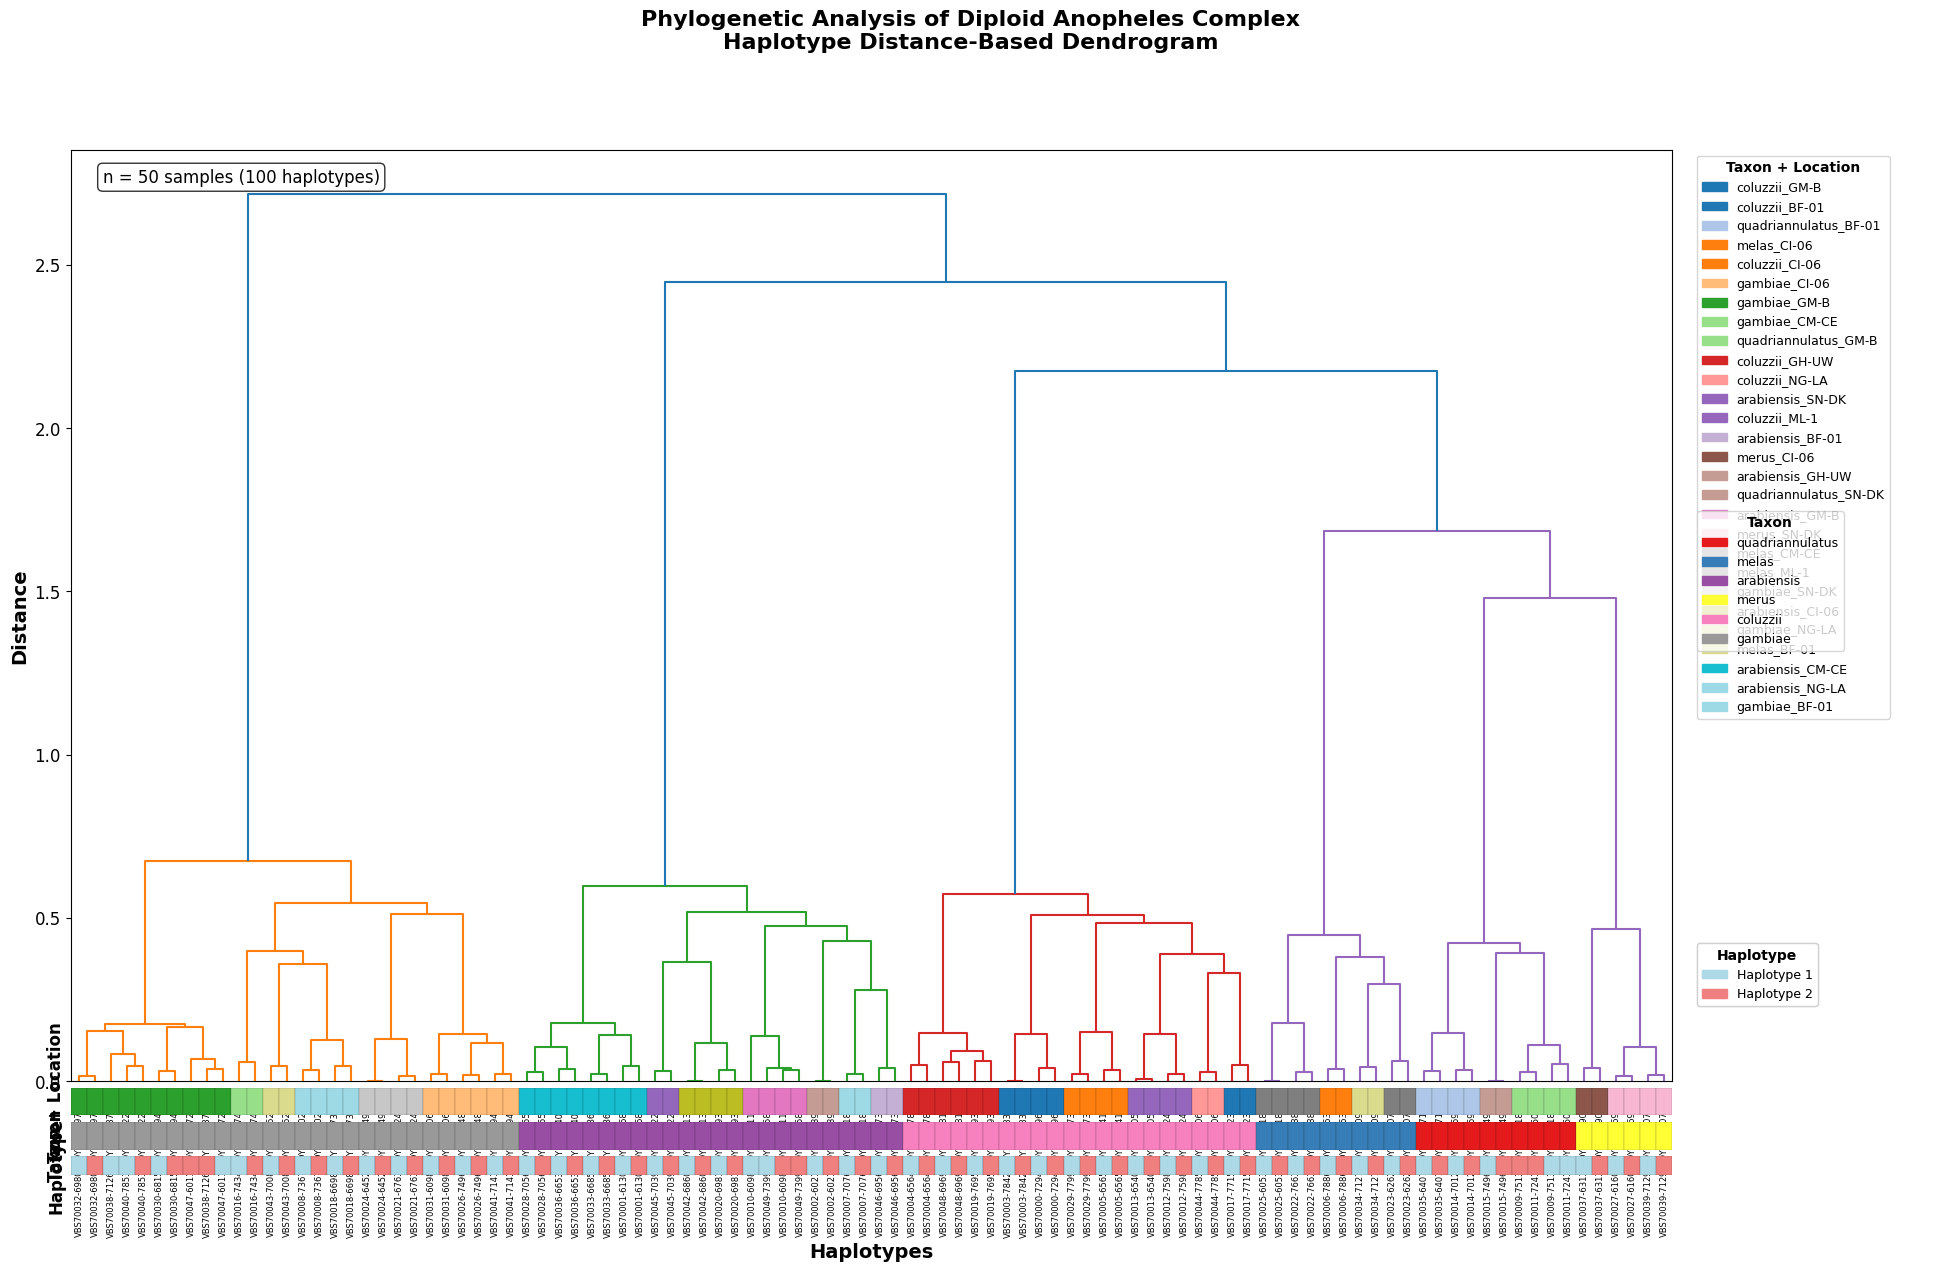

Diploid dendrogram saved as 'anopheles_diploid_dendrogram.png'
Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def generate_simulated_data(n_samples=100, output_json='simulated_distance_data.json',
                          output_metadata='simulated_metadata.csv'):
    """
    Generate simulated diploid data for Anopheles complex
    """
    np.random.seed(42)  # For reproducibility

    # Define realistic taxa and locations for Anopheles complex
    taxa = ['gambiae', 'coluzzii', 'arabiensis', 'quadriannulatus', 'melas', 'merus']
    admin1_isos = ['BF-01', 'GH-UW', 'ML-1', 'SN-DK', 'GM-B', 'CI-06', 'NG-LA', 'CM-CE']
    countries = ['Burkina Faso', 'Ghana', 'Mali', 'Senegal', 'Gambia', 'Ivory Coast', 'Nigeria', 'Cameroon']

    # Create sample metadata
    metadata_list = []
    for i in range(n_samples):
        taxon = np.random.choice(taxa, p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05])  # Weighted by common species
        admin1_iso = np.random.choice(admin1_isos)
        country = countries[admin1_isos.index(admin1_iso)]

        sample_id = f"VBS{70000 + i:05d}-{np.random.randint(6000, 8000)}STDY{np.random.randint(13140000, 13160000)}"

        metadata_list.append({
            'sample_id': sample_id,
            'taxon': taxon,
            'admin1_iso': admin1_iso,
            'country': country,
            'latitude': np.random.uniform(4, 16),  # West African latitudes
            'longitude': np.random.uniform(-17, 15),  # West African longitudes
            'year': np.random.randint(2015, 2024),
            'sex_call': np.random.choice(['F', 'M'], p=[0.7, 0.3]),  # More females typical
            'mean_cov': np.random.uniform(15, 60)
        })

    # Create metadata DataFrame
    metadata_df = pd.DataFrame(metadata_list)

    # For diploid organisms, each sample has 2 haplotypes
    phased_sample_ids = []
    for _, row in metadata_df.iterrows():
        # Add both haplotypes for each sample
        phased_sample_ids.append(f"{row['sample_id']}_hap1")
        phased_sample_ids.append(f"{row['sample_id']}_hap2")

    n_haplotypes = len(phased_sample_ids)

    # Generate realistic distance matrix
    # Create block structure based on taxa and geographic location
    distance_matrix = np.zeros((n_haplotypes, n_haplotypes))

    # Fill distance matrix with realistic patterns
    for i in range(n_haplotypes):
        for j in range(i+1, n_haplotypes):
            # Get sample info for haplotypes
            sample_i_idx = i // 2
            sample_j_idx = j // 2

            taxon_i = metadata_df.iloc[sample_i_idx]['taxon']
            taxon_j = metadata_df.iloc[sample_j_idx]['taxon']
            admin1_i = metadata_df.iloc[sample_i_idx]['admin1_iso']
            admin1_j = metadata_df.iloc[sample_j_idx]['admin1_iso']

            # Base distance
            if i // 2 == j // 2:  # Same sample, different haplotypes
                base_distance = np.random.uniform(0.01, 0.05)
            elif taxon_i == taxon_j and admin1_i == admin1_j:  # Same species, same location
                base_distance = np.random.uniform(0.05, 0.15)
            elif taxon_i == taxon_j:  # Same species, different location
                base_distance = np.random.uniform(0.15, 0.35)
            else:  # Different species
                base_distance = np.random.uniform(0.35, 0.8)

            # Add some noise
            distance = base_distance + np.random.normal(0, 0.02)
            distance = max(0.001, distance)  # Ensure positive distances

            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    # Ensure diagonal is exactly zero (required for scipy distance functions)
    np.fill_diagonal(distance_matrix, 0.0)

    # Create JSON data structure
    json_data = {
        'dist': distance_matrix.tolist(),
        'phased_sample': phased_sample_ids,
        'SNPs': np.random.randint(50000, 150000)  # Simulated SNP count
    }

    # Save files
    with open(output_json, 'w') as f:
        json.dump(json_data, f, indent=2)

    metadata_df.to_csv(output_metadata, index=False)

    print(f"Generated simulated data:")
    print(f"- {n_samples} samples ({n_haplotypes} haplotypes)")
    print(f"- Distance matrix: {distance_matrix.shape}")
    print(f"- Taxa: {set(metadata_df['taxon'])}")
    print(f"- Locations: {set(metadata_df['admin1_iso'])}")
    print(f"- Files saved: {output_json}, {output_metadata}")

    return json_data, metadata_df

def load_and_process_diploid_data(json_file_path, metadata_file_path):
    """
    Load and process diploid JSON distance data and metadata
    """
    # Load JSON data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # Extract components
    distance_matrix = np.array(data['dist'])
    phased_sample_ids = data['phased_sample']

    # Ensure distance matrix is properly formatted
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Load metadata
    metadata = pd.read_csv(metadata_file_path)

    # Process diploid data - each sample has 2 haplotypes
    sample_info = []
    matched_indices = []

    for i, phased_id in enumerate(phased_sample_ids):
        # Extract base sample ID (remove _hap1, _hap2 suffix)
        if '_hap' in phased_id:
            base_sample_id = phased_id.split('_hap')[0]
            haplotype = phased_id.split('_hap')[1]
        else:
            # Fallback - assume alternating pattern
            base_sample_id = phased_id
            haplotype = str((i % 2) + 1)

        # Find matching metadata
        match = metadata[metadata['sample_id'] == base_sample_id]

        if len(match) > 0:
            sample_info.append({
                'phased_id': phased_id,
                'base_sample_id': base_sample_id,
                'haplotype': haplotype,
                'taxon': match.iloc[0]['taxon'],
                'admin1_iso': match.iloc[0]['admin1_iso'],
                'taxon_admin1_iso': f"{match.iloc[0]['taxon']}_{match.iloc[0]['admin1_iso']}",
                'country': match.iloc[0]['country'] if 'country' in match.columns else 'Unknown'
            })
            matched_indices.append(i)
        else:
            print(f"Warning: No match found for base sample {base_sample_id}")

    # Filter distance matrix to only include matched samples
    if len(matched_indices) < len(phased_sample_ids):
        distance_matrix = distance_matrix[np.ix_(matched_indices, matched_indices)]
        print(f"Filtered distance matrix from {len(phased_sample_ids)} to {len(matched_indices)} haplotypes")

    return distance_matrix, sample_info

def create_color_mapping(sample_info):
    """
    Create color mappings for the two annotation bars
    """
    # Get unique categories
    unique_taxon_admin1 = list(set([s['taxon_admin1_iso'] for s in sample_info]))
    unique_taxon = list(set([s['taxon'] for s in sample_info]))

    # Create color palettes with distinct colors
    colors_taxon_admin1 = plt.cm.tab20(np.linspace(0, 1, len(unique_taxon_admin1)))
    colors_taxon = plt.cm.Set1(np.linspace(0, 1, len(unique_taxon)))

    # Create mappings
    taxon_admin1_colors = dict(zip(unique_taxon_admin1, colors_taxon_admin1))
    taxon_colors = dict(zip(unique_taxon, colors_taxon))

    return taxon_admin1_colors, taxon_colors

def plot_diploid_dendrogram(distance_matrix, sample_info, output_file='anopheles_diploid_dendrogram.png'):
    """
    Create a scientific dendrogram for diploid data with annotation bars
    """
    # Ensure distance matrix is properly formatted
    # Make sure diagonal is zero and matrix is symmetric
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Perform hierarchical clustering
    condensed_distances = squareform(distance_matrix)
    linkage_matrix = linkage(condensed_distances, method='ward')

    # Create color mappings
    taxon_admin1_colors, taxon_colors = create_color_mapping(sample_info)

    # Set up the plot with corrected layout
    fig = plt.figure(figsize=(24, 14))

    # Create grid for layout - bars should be BELOW dendrogram, above leaves
    gs = fig.add_gridspec(5, 2, height_ratios=[10, 0.3, 0.3, 0.2, 0.5], width_ratios=[1, 0.15],
                         hspace=0.03, wspace=0.02)

    # Main dendrogram
    ax_dendro = fig.add_subplot(gs[0, 0])

    # Create sample labels for dendrogram
    sample_labels = [f"{s['base_sample_id']}_h{s['haplotype']}" for s in sample_info]

    # Create dendrogram
    dendro = dendrogram(linkage_matrix,
                       labels=sample_labels,
                       ax=ax_dendro,
                       orientation='top',
                       leaf_rotation=90,
                       leaf_font_size=6,
                       color_threshold=0.7*max(linkage_matrix[:,2]))

    # Get the order of samples from dendrogram (this is the reordered leaf order)
    leaf_order = dendro['ivl']

    # Create a mapping from original sample info to reordered positions
    sample_info_dict = {f"{s['base_sample_id']}_h{s['haplotype']}": s for s in sample_info}

    # Get the x-coordinates of the leaves from the dendrogram
    leaf_positions = []
    for i, leaf_label in enumerate(leaf_order):
        leaf_positions.append((i + 0.5) * 10)  # Dendrogram uses 10-unit spacing

    # Create annotation bars using the correct leaf positions
    # Bar 1: taxon_admin1_iso (directly below dendrogram)
    ax_bar1 = fig.add_subplot(gs[1, 0])
    bar1_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            bar1_colors.append(taxon_admin1_colors[sample_info_dict[leaf_label]['taxon_admin1_iso']])
        else:
            bar1_colors.append('gray')

    # Create color rectangles for bar 1 aligned with dendrogram
    for i, color in enumerate(bar1_colors):
        x_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((x_pos, 0), 10, 1, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar1.add_patch(rect)

    ax_bar1.set_xlim(ax_dendro.get_xlim())  # Match dendrogram x-limits
    ax_bar1.set_ylim(0, 1)
    ax_bar1.set_xticks([])
    ax_bar1.set_yticks([])
    ax_bar1.set_ylabel('Taxon + Location', fontsize=12, fontweight='bold')
    for spine in ax_bar1.spines.values():
        spine.set_visible(False)

    # Bar 2: taxon only
    ax_bar2 = fig.add_subplot(gs[2, 0])
    bar2_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            bar2_colors.append(taxon_colors[sample_info_dict[leaf_label]['taxon']])
        else:
            bar2_colors.append('gray')

    # Create color rectangles for bar 2 aligned with dendrogram
    for i, color in enumerate(bar2_colors):
        x_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((x_pos, 0), 10, 1, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar2.add_patch(rect)

    ax_bar2.set_xlim(ax_dendro.get_xlim())  # Match dendrogram x-limits
    ax_bar2.set_ylim(0, 1)
    ax_bar2.set_xticks([])
    ax_bar2.set_yticks([])
    ax_bar2.set_ylabel('Taxon', fontsize=12, fontweight='bold')
    for spine in ax_bar2.spines.values():
        spine.set_visible(False)

    # Bar 3: Haplotype indicator
    ax_bar3 = fig.add_subplot(gs[3, 0])
    hap_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            hap_colors.append('lightblue' if sample_info_dict[leaf_label]['haplotype'] == '1' else 'lightcoral')
        else:
            hap_colors.append('gray')

    for i, color in enumerate(hap_colors):
        x_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((x_pos, 0), 10, 1, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar3.add_patch(rect)

    ax_bar3.set_xlim(ax_dendro.get_xlim())  # Match dendrogram x-limits
    ax_bar3.set_ylim(0, 1)
    ax_bar3.set_xticks([])
    ax_bar3.set_yticks([])
    ax_bar3.set_ylabel('Haplotype', fontsize=12, fontweight='bold')
    for spine in ax_bar3.spines.values():
        spine.set_visible(False)

    # Format dendrogram
    ax_dendro.set_xlabel('Haplotypes', fontsize=14, fontweight='bold')
    ax_dendro.set_ylabel('Distance', fontsize=14, fontweight='bold')
    ax_dendro.tick_params(axis='x', labelsize=6)
    ax_dendro.tick_params(axis='y', labelsize=12)

    # Add legends
    ax_legend = fig.add_subplot(gs[:, 1])
    ax_legend.axis('off')

    # Legend for taxon_admin1_iso
    legend_elements_1 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_admin1_colors.items()]
    legend1 = ax_legend.legend(legend_elements_1,
                              [cat for cat in taxon_admin1_colors.keys()],
                              loc='upper left', bbox_to_anchor=(0, 1),
                              title='Taxon + Location', fontsize=9)
    legend1.get_title().set_fontweight('bold')

    # Legend for taxon
    legend_elements_2 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_colors.items()]
    legend2 = ax_legend.legend(legend_elements_2,
                              [cat for cat in taxon_colors.keys()],
                              loc='center left', bbox_to_anchor=(0, 0.6),
                              title='Taxon', fontsize=9)
    legend2.get_title().set_fontweight('bold')

    # Legend for haplotype
    hap_legend = ax_legend.legend([patches.Patch(color='lightblue', label='Haplotype 1'),
                                  patches.Patch(color='lightcoral', label='Haplotype 2')],
                                 ['Haplotype 1', 'Haplotype 2'],
                                 loc='lower left', bbox_to_anchor=(0, 0.2),
                                 title='Haplotype', fontsize=9)
    hap_legend.get_title().set_fontweight('bold')

    # Add legends to the plot
    ax_legend.add_artist(legend1)
    ax_legend.add_artist(legend2)
    ax_legend.add_artist(hap_legend)

    # Add title
    fig.suptitle('Phylogenetic Analysis of Diploid Anopheles Complex\nHaplotype Distance-Based Dendrogram',
                fontsize=16, fontweight='bold', y=0.98)

    # Add sample count info
    n_samples = len(set([s['base_sample_id'] for s in sample_info]))
    n_haplotypes = len(sample_info)
    ax_dendro.text(0.02, 0.98, f'n = {n_samples} samples ({n_haplotypes} haplotypes)',
                  transform=ax_dendro.transAxes, fontsize=12,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

    return fig, dendro

def validate_distance_matrix(distance_matrix):
    """
    Validate that the distance matrix is properly formatted for clustering
    """
    print("=== Distance Matrix Validation ===")
    print(f"Matrix shape: {distance_matrix.shape}")
    print(f"Matrix is symmetric: {np.allclose(distance_matrix, distance_matrix.T)}")
    print(f"Diagonal is zero: {np.allclose(np.diag(distance_matrix), 0)}")
    print(f"All values non-negative: {np.all(distance_matrix >= 0)}")
    print(f"Matrix range: [{np.min(distance_matrix):.6f}, {np.max(distance_matrix):.6f}]")

    # Check for any problematic values
    if np.any(np.isnan(distance_matrix)):
        print("WARNING: Matrix contains NaN values")
    if np.any(np.isinf(distance_matrix)):
        print("WARNING: Matrix contains infinite values")

    return True

def print_diploid_statistics(sample_info):
    """
    Print summary statistics about the diploid samples
    """
    print("=== Diploid Sample Statistics ===")

    # Get unique samples
    unique_samples = set([s['base_sample_id'] for s in sample_info])
    print(f"Total unique samples: {len(unique_samples)}")
    print(f"Total haplotypes: {len(sample_info)}")

    # Count by taxon
    taxon_counts = {}
    for s in sample_info:
        taxon = s['taxon']
        taxon_counts[taxon] = taxon_counts.get(taxon, 0) + 1

    print("\nHaplotypes by Taxon:")
    for taxon, count in sorted(taxon_counts.items()):
        print(f"  {taxon}: {count} haplotypes ({count//2} samples)")

    # Count by admin1_iso
    admin1_counts = {}
    for s in sample_info:
        admin1 = s['admin1_iso']
        admin1_counts[admin1] = admin1_counts.get(admin1, 0) + 1

    print("\nHaplotypes by Location:")
    for admin1, count in sorted(admin1_counts.items()):
        print(f"  {admin1}: {count} haplotypes ({count//2} samples)")

# Main execution
if __name__ == "__main__":
    # Generate simulated data
    print("Generating simulated diploid data...")
    json_data, metadata_df = generate_simulated_data(n_samples=50)  # 50 samples = 100 haplotypes

    # File paths
    json_file_path = "simulated_distance_data.json"
    metadata_file_path = "simulated_metadata.csv"

    print("\nLoading and processing diploid data...")
    distance_matrix, sample_info = load_and_process_diploid_data(json_file_path, metadata_file_path)

    print("\nValidating distance matrix...")
    validate_distance_matrix(distance_matrix)

    print("\nDiploid data processing completed!")
    print_diploid_statistics(sample_info)

    print("\nCreating diploid dendrogram...")
    fig, dendro = plot_diploid_dendrogram(distance_matrix, sample_info)

    print("Diploid dendrogram saved as 'anopheles_diploid_dendrogram.png'")
    print("Analysis complete!")

Generating simulated diploid data...
Generated simulated data:
- 50 samples (100 haplotypes)
- Distance matrix: (100, 100)
- Taxa: {np.str_('quadriannulatus'), np.str_('melas'), np.str_('arabiensis'), np.str_('merus'), np.str_('coluzzii'), np.str_('gambiae')}
- Locations: {np.str_('GH-UW'), np.str_('CM-CE'), np.str_('ML-1'), np.str_('SN-DK'), np.str_('CI-06'), np.str_('BF-01'), np.str_('GM-B'), np.str_('NG-LA')}
- Files saved: simulated_distance_data.json, simulated_metadata.csv

Loading and processing diploid data...

Validating distance matrix...
=== Distance Matrix Validation ===
Matrix shape: (100, 100)
Matrix is symmetric: True
Diagonal is zero: True
All values non-negative: True
Matrix range: [0.000000, 0.850061]

Diploid data processing completed!
=== Diploid Sample Statistics ===
Total unique samples: 50
Total haplotypes: 100

Haplotypes by Taxon:
  arabiensis: 24 haplotypes (12 samples)
  coluzzii: 22 haplotypes (11 samples)
  gambiae: 28 haplotypes (14 samples)
  melas: 10 ha

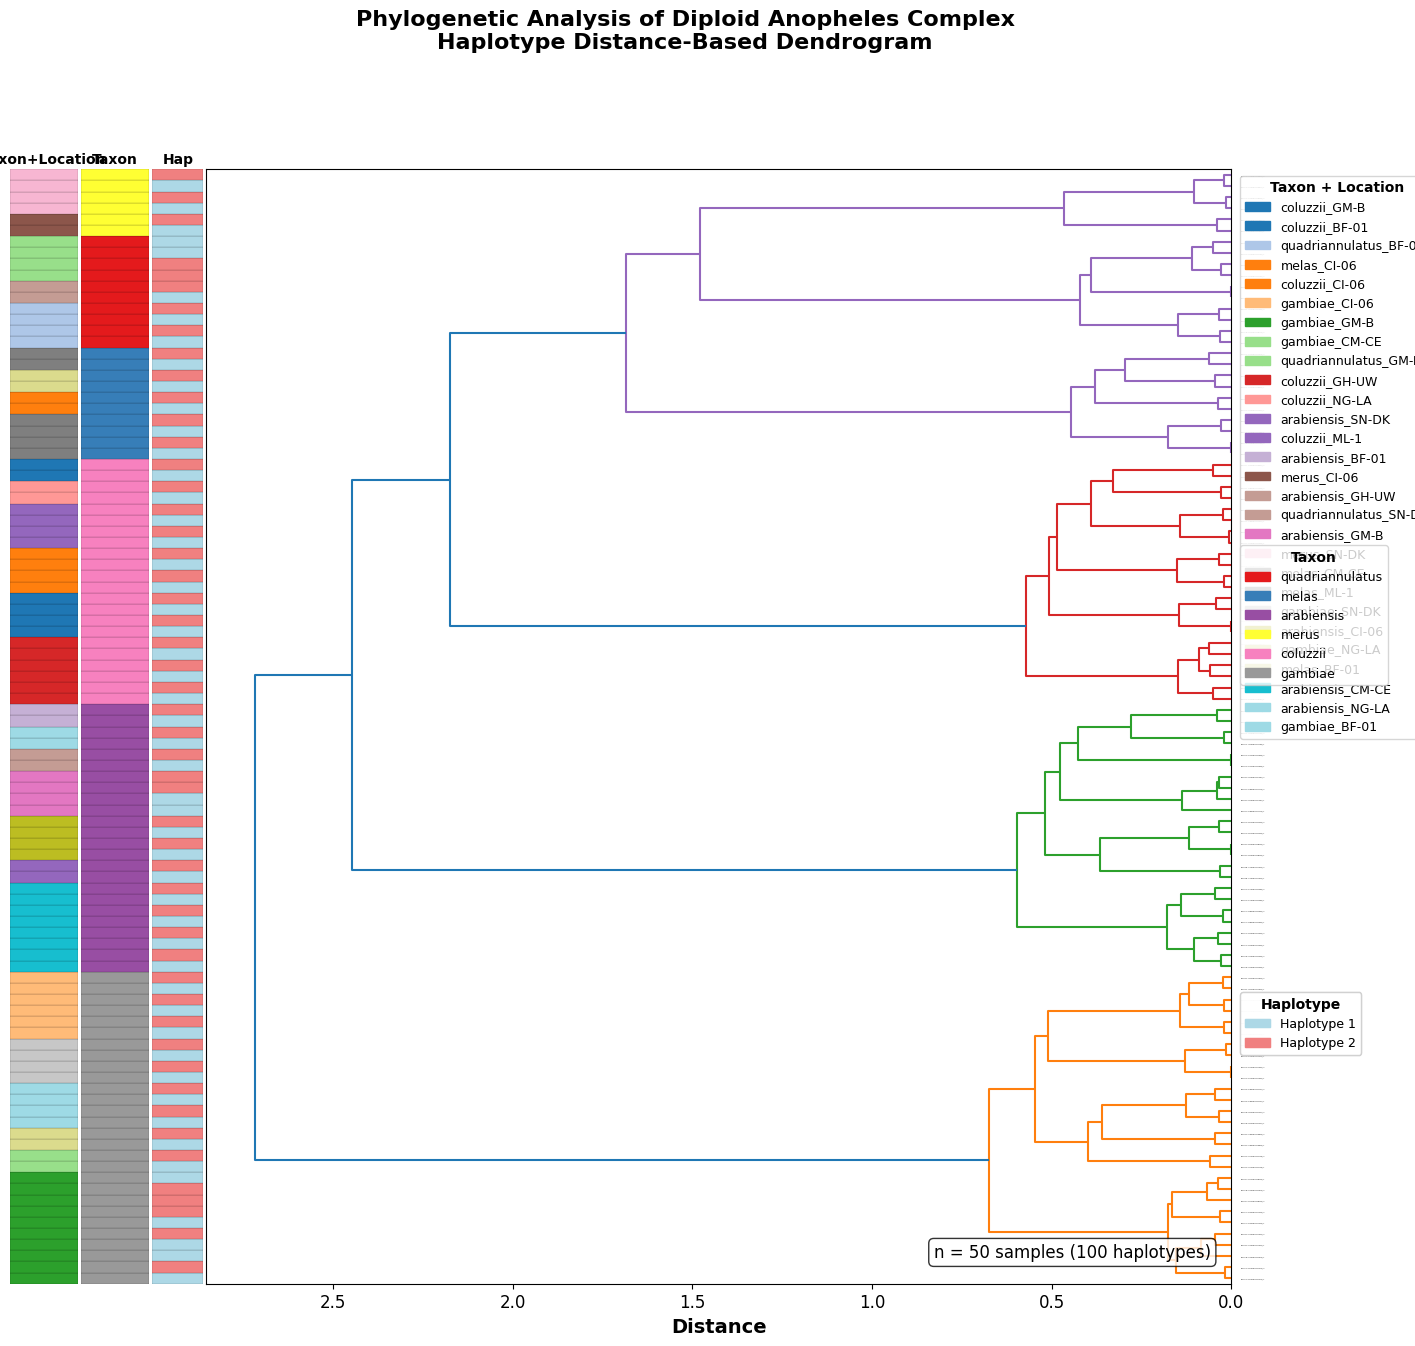

Vertical diploid dendrogram saved as 'anopheles_diploid_vertical_dendrogram.png'
Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def generate_simulated_data(n_samples=100, output_json='simulated_distance_data.json',
                          output_metadata='simulated_metadata.csv'):
    """
    Generate simulated diploid data for Anopheles complex
    """
    np.random.seed(42)  # For reproducibility

    # Define realistic taxa and locations for Anopheles complex
    taxa = ['gambiae', 'coluzzii', 'arabiensis', 'quadriannulatus', 'melas', 'merus']
    admin1_isos = ['BF-01', 'GH-UW', 'ML-1', 'SN-DK', 'GM-B', 'CI-06', 'NG-LA', 'CM-CE']
    countries = ['Burkina Faso', 'Ghana', 'Mali', 'Senegal', 'Gambia', 'Ivory Coast', 'Nigeria', 'Cameroon']

    # Create sample metadata
    metadata_list = []
    for i in range(n_samples):
        taxon = np.random.choice(taxa, p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05])  # Weighted by common species
        admin1_iso = np.random.choice(admin1_isos)
        country = countries[admin1_isos.index(admin1_iso)]

        sample_id = f"VBS{70000 + i:05d}-{np.random.randint(6000, 8000)}STDY{np.random.randint(13140000, 13160000)}"

        metadata_list.append({
            'sample_id': sample_id,
            'taxon': taxon,
            'admin1_iso': admin1_iso,
            'country': country,
            'latitude': np.random.uniform(4, 16),  # West African latitudes
            'longitude': np.random.uniform(-17, 15),  # West African longitudes
            'year': np.random.randint(2015, 2024),
            'sex_call': np.random.choice(['F', 'M'], p=[0.7, 0.3]),  # More females typical
            'mean_cov': np.random.uniform(15, 60)
        })

    # Create metadata DataFrame
    metadata_df = pd.DataFrame(metadata_list)

    # For diploid organisms, each sample has 2 haplotypes
    phased_sample_ids = []
    for _, row in metadata_df.iterrows():
        # Add both haplotypes for each sample
        phased_sample_ids.append(f"{row['sample_id']}_hap1")
        phased_sample_ids.append(f"{row['sample_id']}_hap2")

    n_haplotypes = len(phased_sample_ids)

    # Generate realistic distance matrix
    # Create block structure based on taxa and geographic location
    distance_matrix = np.zeros((n_haplotypes, n_haplotypes))

    # Fill distance matrix with realistic patterns
    for i in range(n_haplotypes):
        for j in range(i+1, n_haplotypes):
            # Get sample info for haplotypes
            sample_i_idx = i // 2
            sample_j_idx = j // 2

            taxon_i = metadata_df.iloc[sample_i_idx]['taxon']
            taxon_j = metadata_df.iloc[sample_j_idx]['taxon']
            admin1_i = metadata_df.iloc[sample_i_idx]['admin1_iso']
            admin1_j = metadata_df.iloc[sample_j_idx]['admin1_iso']

            # Base distance
            if i // 2 == j // 2:  # Same sample, different haplotypes
                base_distance = np.random.uniform(0.01, 0.05)
            elif taxon_i == taxon_j and admin1_i == admin1_j:  # Same species, same location
                base_distance = np.random.uniform(0.05, 0.15)
            elif taxon_i == taxon_j:  # Same species, different location
                base_distance = np.random.uniform(0.15, 0.35)
            else:  # Different species
                base_distance = np.random.uniform(0.35, 0.8)

            # Add some noise
            distance = base_distance + np.random.normal(0, 0.02)
            distance = max(0.001, distance)  # Ensure positive distances

            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    # Ensure diagonal is exactly zero (required for scipy distance functions)
    np.fill_diagonal(distance_matrix, 0.0)

    # Create JSON data structure
    json_data = {
        'dist': distance_matrix.tolist(),
        'phased_sample': phased_sample_ids,
        'SNPs': np.random.randint(50000, 150000)  # Simulated SNP count
    }

    # Save files
    with open(output_json, 'w') as f:
        json.dump(json_data, f, indent=2)

    metadata_df.to_csv(output_metadata, index=False)

    print(f"Generated simulated data:")
    print(f"- {n_samples} samples ({n_haplotypes} haplotypes)")
    print(f"- Distance matrix: {distance_matrix.shape}")
    print(f"- Taxa: {set(metadata_df['taxon'])}")
    print(f"- Locations: {set(metadata_df['admin1_iso'])}")
    print(f"- Files saved: {output_json}, {output_metadata}")

    return json_data, metadata_df

def load_and_process_diploid_data(json_file_path, metadata_file_path):
    """
    Load and process diploid JSON distance data and metadata
    """
    # Load JSON data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # Extract components
    distance_matrix = np.array(data['dist'])
    phased_sample_ids = data['phased_sample']

    # Ensure distance matrix is properly formatted
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Load metadata
    metadata = pd.read_csv(metadata_file_path)

    # Process diploid data - each sample has 2 haplotypes
    sample_info = []
    matched_indices = []

    for i, phased_id in enumerate(phased_sample_ids):
        # Extract base sample ID (remove _hap1, _hap2 suffix)
        if '_hap' in phased_id:
            base_sample_id = phased_id.split('_hap')[0]
            haplotype = phased_id.split('_hap')[1]
        else:
            # Fallback - assume alternating pattern
            base_sample_id = phased_id
            haplotype = str((i % 2) + 1)

        # Find matching metadata
        match = metadata[metadata['sample_id'] == base_sample_id]

        if len(match) > 0:
            sample_info.append({
                'phased_id': phased_id,
                'base_sample_id': base_sample_id,
                'haplotype': haplotype,
                'taxon': match.iloc[0]['taxon'],
                'admin1_iso': match.iloc[0]['admin1_iso'],
                'taxon_admin1_iso': f"{match.iloc[0]['taxon']}_{match.iloc[0]['admin1_iso']}",
                'country': match.iloc[0]['country'] if 'country' in match.columns else 'Unknown'
            })
            matched_indices.append(i)
        else:
            print(f"Warning: No match found for base sample {base_sample_id}")

    # Filter distance matrix to only include matched samples
    if len(matched_indices) < len(phased_sample_ids):
        distance_matrix = distance_matrix[np.ix_(matched_indices, matched_indices)]
        print(f"Filtered distance matrix from {len(phased_sample_ids)} to {len(matched_indices)} haplotypes")

    return distance_matrix, sample_info

def create_color_mapping(sample_info):
    """
    Create color mappings for the two annotation bars
    """
    # Get unique categories
    unique_taxon_admin1 = list(set([s['taxon_admin1_iso'] for s in sample_info]))
    unique_taxon = list(set([s['taxon'] for s in sample_info]))

    # Create color palettes with distinct colors
    colors_taxon_admin1 = plt.cm.tab20(np.linspace(0, 1, len(unique_taxon_admin1)))
    colors_taxon = plt.cm.Set1(np.linspace(0, 1, len(unique_taxon)))

    # Create mappings
    taxon_admin1_colors = dict(zip(unique_taxon_admin1, colors_taxon_admin1))
    taxon_colors = dict(zip(unique_taxon, colors_taxon))

    return taxon_admin1_colors, taxon_colors

def plot_diploid_dendrogram(distance_matrix, sample_info, output_file='anopheles_diploid_vertical_dendrogram.png'):
    """
    Create a scientific dendrogram for diploid data with annotation bars
    """
    # Ensure distance matrix is properly formatted
    # Make sure diagonal is zero and matrix is symmetric
    np.fill_diagonal(distance_matrix, 0.0)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2  # Ensure symmetry

    # Perform hierarchical clustering
    condensed_distances = squareform(distance_matrix)
    linkage_matrix = linkage(condensed_distances, method='ward')

    # Create color mappings
    taxon_admin1_colors, taxon_colors = create_color_mapping(sample_info)

    # Set up the plot with vertical layout - bars should be immediately left of leaves
    fig = plt.figure(figsize=(18, 16))

    # Create grid for layout - bars directly adjacent to dendrogram leaves
    gs = fig.add_gridspec(2, 5, height_ratios=[1, 0.1], width_ratios=[0.8, 0.8, 0.6, 12, 2],
                         hspace=0.01, wspace=0.01)

    # Main dendrogram (vertical orientation)
    ax_dendro = fig.add_subplot(gs[0, 3])

    # Create sample labels for dendrogram but hide them
    sample_labels = [f"{s['base_sample_id']}_h{s['haplotype']}" for s in sample_info]

    # Create dendrogram with left orientation (leaves on left side)
    dendro = dendrogram(linkage_matrix,
                       labels=sample_labels,
                       ax=ax_dendro,
                       orientation='left',
                       leaf_rotation=0,
                       leaf_font_size=0,  # Hide leaf labels
                       color_threshold=0.7*max(linkage_matrix[:,2]))

    # Get the order of samples from dendrogram (this is the reordered leaf order)
    leaf_order = dendro['ivl']

    # Create a mapping from original sample info to reordered positions
    sample_info_dict = {f"{s['base_sample_id']}_h{s['haplotype']}": s for s in sample_info}

    # Get the y-positions of the leaves from the dendrogram
    # For left orientation, leaves are positioned at y-coordinates
    leaf_y_positions = dendro['dcoord']

    # Create annotation bars on the left side, directly adjacent to leaves
    # The bars should align with the dendrogram's y-axis

    # Get the x-coordinates of the leaves from the dendrogram
    leaf_positions = []
    for i, leaf_label in enumerate(leaf_order):
        leaf_positions.append((i + 0.5) * 10)  # Dendrogram uses 10-unit spacing

    # Bar 1: Haplotype indicator (immediately left of leaves)
    ax_bar1 = fig.add_subplot(gs[0, 2])
    hap_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            hap_colors.append('lightblue' if sample_info_dict[leaf_label]['haplotype'] == '1' else 'lightcoral')
        else:
            hap_colors.append('gray')

    for i, color in enumerate(hap_colors):
        y_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((0, y_pos), 1, 10, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar1.add_patch(rect)

    ax_bar1.set_xlim(0, 1)
    ax_bar1.set_ylim(ax_dendro.get_ylim())  # Match dendrogram y-limits
    ax_bar1.set_xticks([])
    ax_bar1.set_yticks([])
    ax_bar1.set_xlabel('Hap', fontsize=10, fontweight='bold')
    ax_bar1.xaxis.set_label_position('top')
    for spine in ax_bar1.spines.values():
        spine.set_visible(False)

    # Bar 2: taxon only (second from left)
    ax_bar2 = fig.add_subplot(gs[0, 1])
    bar2_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            bar2_colors.append(taxon_colors[sample_info_dict[leaf_label]['taxon']])
        else:
            bar2_colors.append('gray')

    for i, color in enumerate(bar2_colors):
        y_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((0, y_pos), 1, 10, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar2.add_patch(rect)

    ax_bar2.set_xlim(0, 1)
    ax_bar2.set_ylim(ax_dendro.get_ylim())  # Match dendrogram y-limits
    ax_bar2.set_xticks([])
    ax_bar2.set_yticks([])
    ax_bar2.set_xlabel('Taxon', fontsize=10, fontweight='bold')
    ax_bar2.xaxis.set_label_position('top')
    for spine in ax_bar2.spines.values():
        spine.set_visible(False)

    # Bar 3: taxon_admin1_iso (leftmost)
    ax_bar3 = fig.add_subplot(gs[0, 0])
    bar3_colors = []
    for leaf_label in leaf_order:
        if leaf_label in sample_info_dict:
            bar3_colors.append(taxon_admin1_colors[sample_info_dict[leaf_label]['taxon_admin1_iso']])
        else:
            bar3_colors.append('gray')

    for i, color in enumerate(bar3_colors):
        y_pos = i * 10  # Match dendrogram spacing
        rect = Rectangle((0, y_pos), 1, 10, facecolor=color, edgecolor='black', linewidth=0.1)
        ax_bar3.add_patch(rect)

    ax_bar3.set_xlim(0, 1)
    ax_bar3.set_ylim(ax_dendro.get_ylim())  # Match dendrogram y-limits
    ax_bar3.set_xticks([])
    ax_bar3.set_yticks([])
    ax_bar3.set_xlabel('Taxon+Location', fontsize=10, fontweight='bold')
    ax_bar3.xaxis.set_label_position('top')
    for spine in ax_bar3.spines.values():
        spine.set_visible(False)

    # Format dendrogram
    ax_dendro.set_ylabel('Samples', fontsize=14, fontweight='bold')
    ax_dendro.set_xlabel('Distance', fontsize=14, fontweight='bold')
    ax_dendro.tick_params(axis='y', labelsize=0)  # Hide y-axis labels (sample names)
    ax_dendro.tick_params(axis='x', labelsize=12)

    # Add legends
    ax_legend = fig.add_subplot(gs[0, 4])  # Right side legend
    ax_legend.axis('off')

    # Legend for taxon_admin1_iso
    legend_elements_1 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_admin1_colors.items()]
    legend1 = ax_legend.legend(legend_elements_1,
                              [cat for cat in taxon_admin1_colors.keys()],
                              loc='upper left', bbox_to_anchor=(0, 1),
                              title='Taxon + Location', fontsize=9)
    legend1.get_title().set_fontweight('bold')

    # Legend for taxon
    legend_elements_2 = [patches.Patch(color=color, label=category)
                        for category, color in taxon_colors.items()]
    legend2 = ax_legend.legend(legend_elements_2,
                              [cat for cat in taxon_colors.keys()],
                              loc='center left', bbox_to_anchor=(0, 0.6),
                              title='Taxon', fontsize=9)
    legend2.get_title().set_fontweight('bold')

    # Legend for haplotype
    hap_legend = ax_legend.legend([patches.Patch(color='lightblue', label='Haplotype 1'),
                                  patches.Patch(color='lightcoral', label='Haplotype 2')],
                                 ['Haplotype 1', 'Haplotype 2'],
                                 loc='lower left', bbox_to_anchor=(0, 0.2),
                                 title='Haplotype', fontsize=9)
    hap_legend.get_title().set_fontweight('bold')

    # Add legends to the plot
    ax_legend.add_artist(legend1)
    ax_legend.add_artist(legend2)
    ax_legend.add_artist(hap_legend)

    # Add title
    fig.suptitle('Phylogenetic Analysis of Diploid Anopheles Complex\nHaplotype Distance-Based Dendrogram',
                fontsize=16, fontweight='bold', y=0.98)

    # Add sample count info
    n_samples = len(set([s['base_sample_id'] for s in sample_info]))
    n_haplotypes = len(sample_info)
    ax_dendro.text(0.98, 0.02, f'n = {n_samples} samples ({n_haplotypes} haplotypes)',
                  transform=ax_dendro.transAxes, fontsize=12,
                  verticalalignment='bottom', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

    return fig, dendro

def validate_distance_matrix(distance_matrix):
    """
    Validate that the distance matrix is properly formatted for clustering
    """
    print("=== Distance Matrix Validation ===")
    print(f"Matrix shape: {distance_matrix.shape}")
    print(f"Matrix is symmetric: {np.allclose(distance_matrix, distance_matrix.T)}")
    print(f"Diagonal is zero: {np.allclose(np.diag(distance_matrix), 0)}")
    print(f"All values non-negative: {np.all(distance_matrix >= 0)}")
    print(f"Matrix range: [{np.min(distance_matrix):.6f}, {np.max(distance_matrix):.6f}]")

    # Check for any problematic values
    if np.any(np.isnan(distance_matrix)):
        print("WARNING: Matrix contains NaN values")
    if np.any(np.isinf(distance_matrix)):
        print("WARNING: Matrix contains infinite values")

    return True

def print_diploid_statistics(sample_info):
    """
    Print summary statistics about the diploid samples
    """
    print("=== Diploid Sample Statistics ===")

    # Get unique samples
    unique_samples = set([s['base_sample_id'] for s in sample_info])
    print(f"Total unique samples: {len(unique_samples)}")
    print(f"Total haplotypes: {len(sample_info)}")

    # Count by taxon
    taxon_counts = {}
    for s in sample_info:
        taxon = s['taxon']
        taxon_counts[taxon] = taxon_counts.get(taxon, 0) + 1

    print("\nHaplotypes by Taxon:")
    for taxon, count in sorted(taxon_counts.items()):
        print(f"  {taxon}: {count} haplotypes ({count//2} samples)")

    # Count by admin1_iso
    admin1_counts = {}
    for s in sample_info:
        admin1 = s['admin1_iso']
        admin1_counts[admin1] = admin1_counts.get(admin1, 0) + 1

    print("\nHaplotypes by Location:")
    for admin1, count in sorted(admin1_counts.items()):
        print(f"  {admin1}: {count} haplotypes ({count//2} samples)")

# Main execution
if __name__ == "__main__":
    # Generate simulated data
    print("Generating simulated diploid data...")
    json_data, metadata_df = generate_simulated_data(n_samples=50)  # 50 samples = 100 haplotypes

    # File paths
    json_file_path = "simulated_distance_data.json"
    metadata_file_path = "simulated_metadata.csv"

    print("\nLoading and processing diploid data...")
    distance_matrix, sample_info = load_and_process_diploid_data(json_file_path, metadata_file_path)

    print("\nValidating distance matrix...")
    validate_distance_matrix(distance_matrix)

    print("\nDiploid data processing completed!")
    print_diploid_statistics(sample_info)

    print("\nCreating diploid dendrogram...")
    fig, dendro = plot_diploid_dendrogram(distance_matrix, sample_info)

    print("Vertical diploid dendrogram saved as 'anopheles_diploid_vertical_dendrogram.png'")
    print("Analysis complete!")

In [189]:
# Load the saved haplotype data
with open('haplotype_dict.json', 'r') as fp:
    haplotype_dict_loaded = json.load(fp)

# Convert back to NumPy arrays
dist = np.array(haplotype_dict_loaded["dist"])
phased_sample = np.array(haplotype_dict_loaded["phased_sample"])
n_snp = haplotype_dict_loaded["n_snp"]

sample_metadata = pd.read_csv('sample_metadata (2).csv')
samples_df = sample_metadata[sample_metadata['sample_id'].isin(phased_sample.tolist())].copy()
#samples_df["sample_pop"] = samples_df["taxon"] + "_" + samples_df["admin1_iso"]
samples_df["sample_pop"] = samples_df["sample_id"]
# Samples list
samples_list = list(samples_df['sample_id'].values)

# Align sample metadata with haplotypes.
df_samples_phased = (
    samples_df.set_index("sample_id").loc[phased_sample.tolist()].reset_index()
)

# Ensure correct distance matrix format
if len(dist.shape) == 1:  # If dist is condensed (1D)
    distance_matrix_sq = squareform(dist)
else:
    distance_matrix_sq = dist  # Already square

# Repeat metadata so there is one row per haplotype
df_haps = pd.DataFrame(np.repeat(df_samples_phased.values, 2, axis=0))
df_haps.columns = df_samples_phased.columns  # Restore column names

# Ensure haplotype IDs match the distance matrix shape
haplotype_ids = list(df_haps["sample_pop"].values)  # Use the repeated sample IDs for haplotypes

# Validate matrix and haplotype list size
assert distance_matrix_sq.shape == (len(haplotype_ids), len(haplotype_ids)), \
    f"Mismatch: Distance matrix shape {distance_matrix_sq.shape} vs. haplotype list {len(haplotype_ids)}"



# Convert distance matrix to DataFrame with correct haplotype IDs
distance_df = pd.DataFrame(distance_matrix_sq, index=haplotype_ids, columns=haplotype_ids)

In [2]:


# Load data
with open('haplotype_dict.json', 'r') as fp:
    haplotype_dict_loaded = json.load(fp)

print("Keys in haplotype_dict:", haplotype_dict_loaded.keys())
dist = np.array(haplotype_dict_loaded['dist'])
phased_sample = np.array(haplotype_dict_loaded['phased_sample'])

sample_metadata = pd.read_csv('sample_metadata (2).csv')
samples_df = sample_metadata[sample_metadata['sample_id'].isin(phased_sample.tolist())].copy()
#samples_df["sample_pop"] = samples_df["taxon"] + "_" + samples_df["admin1_iso"]
samples_df["sample_pop"] = samples_df["taxon"]

# Align sample metadata with haplotypes
df_samples_phased = (
    samples_df.set_index("sample_id").loc[phased_sample.tolist()].reset_index()
)

# Ensure correct distance matrix format
if len(dist.shape) == 1:  # If dist is condensed (1D)
    distance_matrix_sq = squareform(dist)
else:
    distance_matrix_sq = dist  # Already square

print(f"Distance matrix shape: {distance_matrix_sq.shape}")
print(f"Number of samples: {len(df_samples_phased)}")

# Handle haplotype vs sample mismatch
n_haplotypes = distance_matrix_sq.shape[0]
n_samples = len(df_samples_phased)

# Create haplotype-level population assignments (assuming 2 haplotypes per sample)
if n_haplotypes == 2 * n_samples:
    print("Detected haplotype-level data (2 haplotypes per sample)")
    # Duplicate each sample's population for its 2 haplotypes
    haplotype_pops = []
    for pop in df_samples_phased['sample_id']:
        haplotype_pops.extend([pop, pop])
    haplotype_df = pd.DataFrame({'haplotype_pop': haplotype_pops})
else:
    print("Using sample-level data")
    haplotype_df = df_samples_phased.copy()
    haplotype_df['haplotype_pop'] = haplotype_df['sample_pop']

print(f"Number of haplotypes/samples for analysis: {len(haplotype_df)}")


Keys in haplotype_dict: dict_keys(['dist', 'phased_sample', 'n_snp'])
Distance matrix shape: (534, 534)
Number of samples: 267
Detected haplotype-level data (2 haplotypes per sample)
Number of haplotypes/samples for analysis: 534


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, optimal_leaf_ordering
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import SpectralEmbedding
from sklearn.datasets import make_blobs
from scipy.spatial.distance import squareform
import numpy as np
import json
from matplotlib.patches import Patch
import matplotlib.patches as mpatches



def plot_dendrogram(distance_matrix_sq, sample_metadata_file, output_file,labels=None):
    # Perform hierarchical clustering
        condensed_distances = pdist(distance_matrix_sq)
        linkage_matrix = linkage(condensed_distances, method='ward')

        plt.figure(figsize=(20, 25))
        den = dendrogram(
            linkage_matrix,
            labels=labels,
            leaf_rotation=0,
            leaf_font_size=8,
            #color_threshold=0.5,
            #above_threshold_color='black',
            #below_threshold_color='gray',
            no_labels=False,
            orientation='left',
            ax=None,
            count_sort=True,
        )
        print(len(den['leaves']))

        print(len(labels))
        for i, leaf_idx in enumerate(den['leaves']):
          sample_id = labels[leaf_idx]
          color = sample_to_color[sample_id]
          #print(f"sample_id: {sample_id}, color: {sample_to_color.get(sample_id)}")

          # Draw a rectangle next to the leaf
          rect = plt.Rectangle(
              (-5, i - 0.4),  # x left of tree
              2,              # bar width
              0.8,            # bar height
              facecolor=color,
              edgecolor='none'
          )
          plt.gca().add_patch(rect)

        plt.title('Dendrogram')
        plt.xlabel('Distance')
        #plt.ylabel('Samples')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        return den

In [42]:
labels = haplotype_df['haplotype_pop'].values
labels_backup = labels.copy()

In [4]:
print("Number of labels:", len(labels))
print("Distance matrix shape:", distance_matrix_sq.shape)


Number of labels: 534
Distance matrix shape: (534, 534)


In [43]:
import seaborn as sns



# Create color palette for each unique taxon
taxa = df_samples_phased['taxon'].unique()
"""palette = sns.color_palette("tab10", len(taxa))
taxon_to_color = dict(zip(taxa, palette))"""
taxon_to_color = {
    'bissau': 'purple',
    'gambiae': 'blue',
    'coluzzii': 'orange'
}

# Map sample ID to color
sample_to_taxon = dict(zip(df_samples_phased['sample_id'], df_samples_phased['taxon']))
sample_to_color = {s: taxon_to_color[sample_to_taxon[s]] for s in labels}

In [7]:
den.keys()
den['ivl']
den['leaves']

labels[147]

dict_keys(['icoord', 'dcoord', 'ivl', 'leaves', 'color_list', 'leaves_color_list'])

534
534


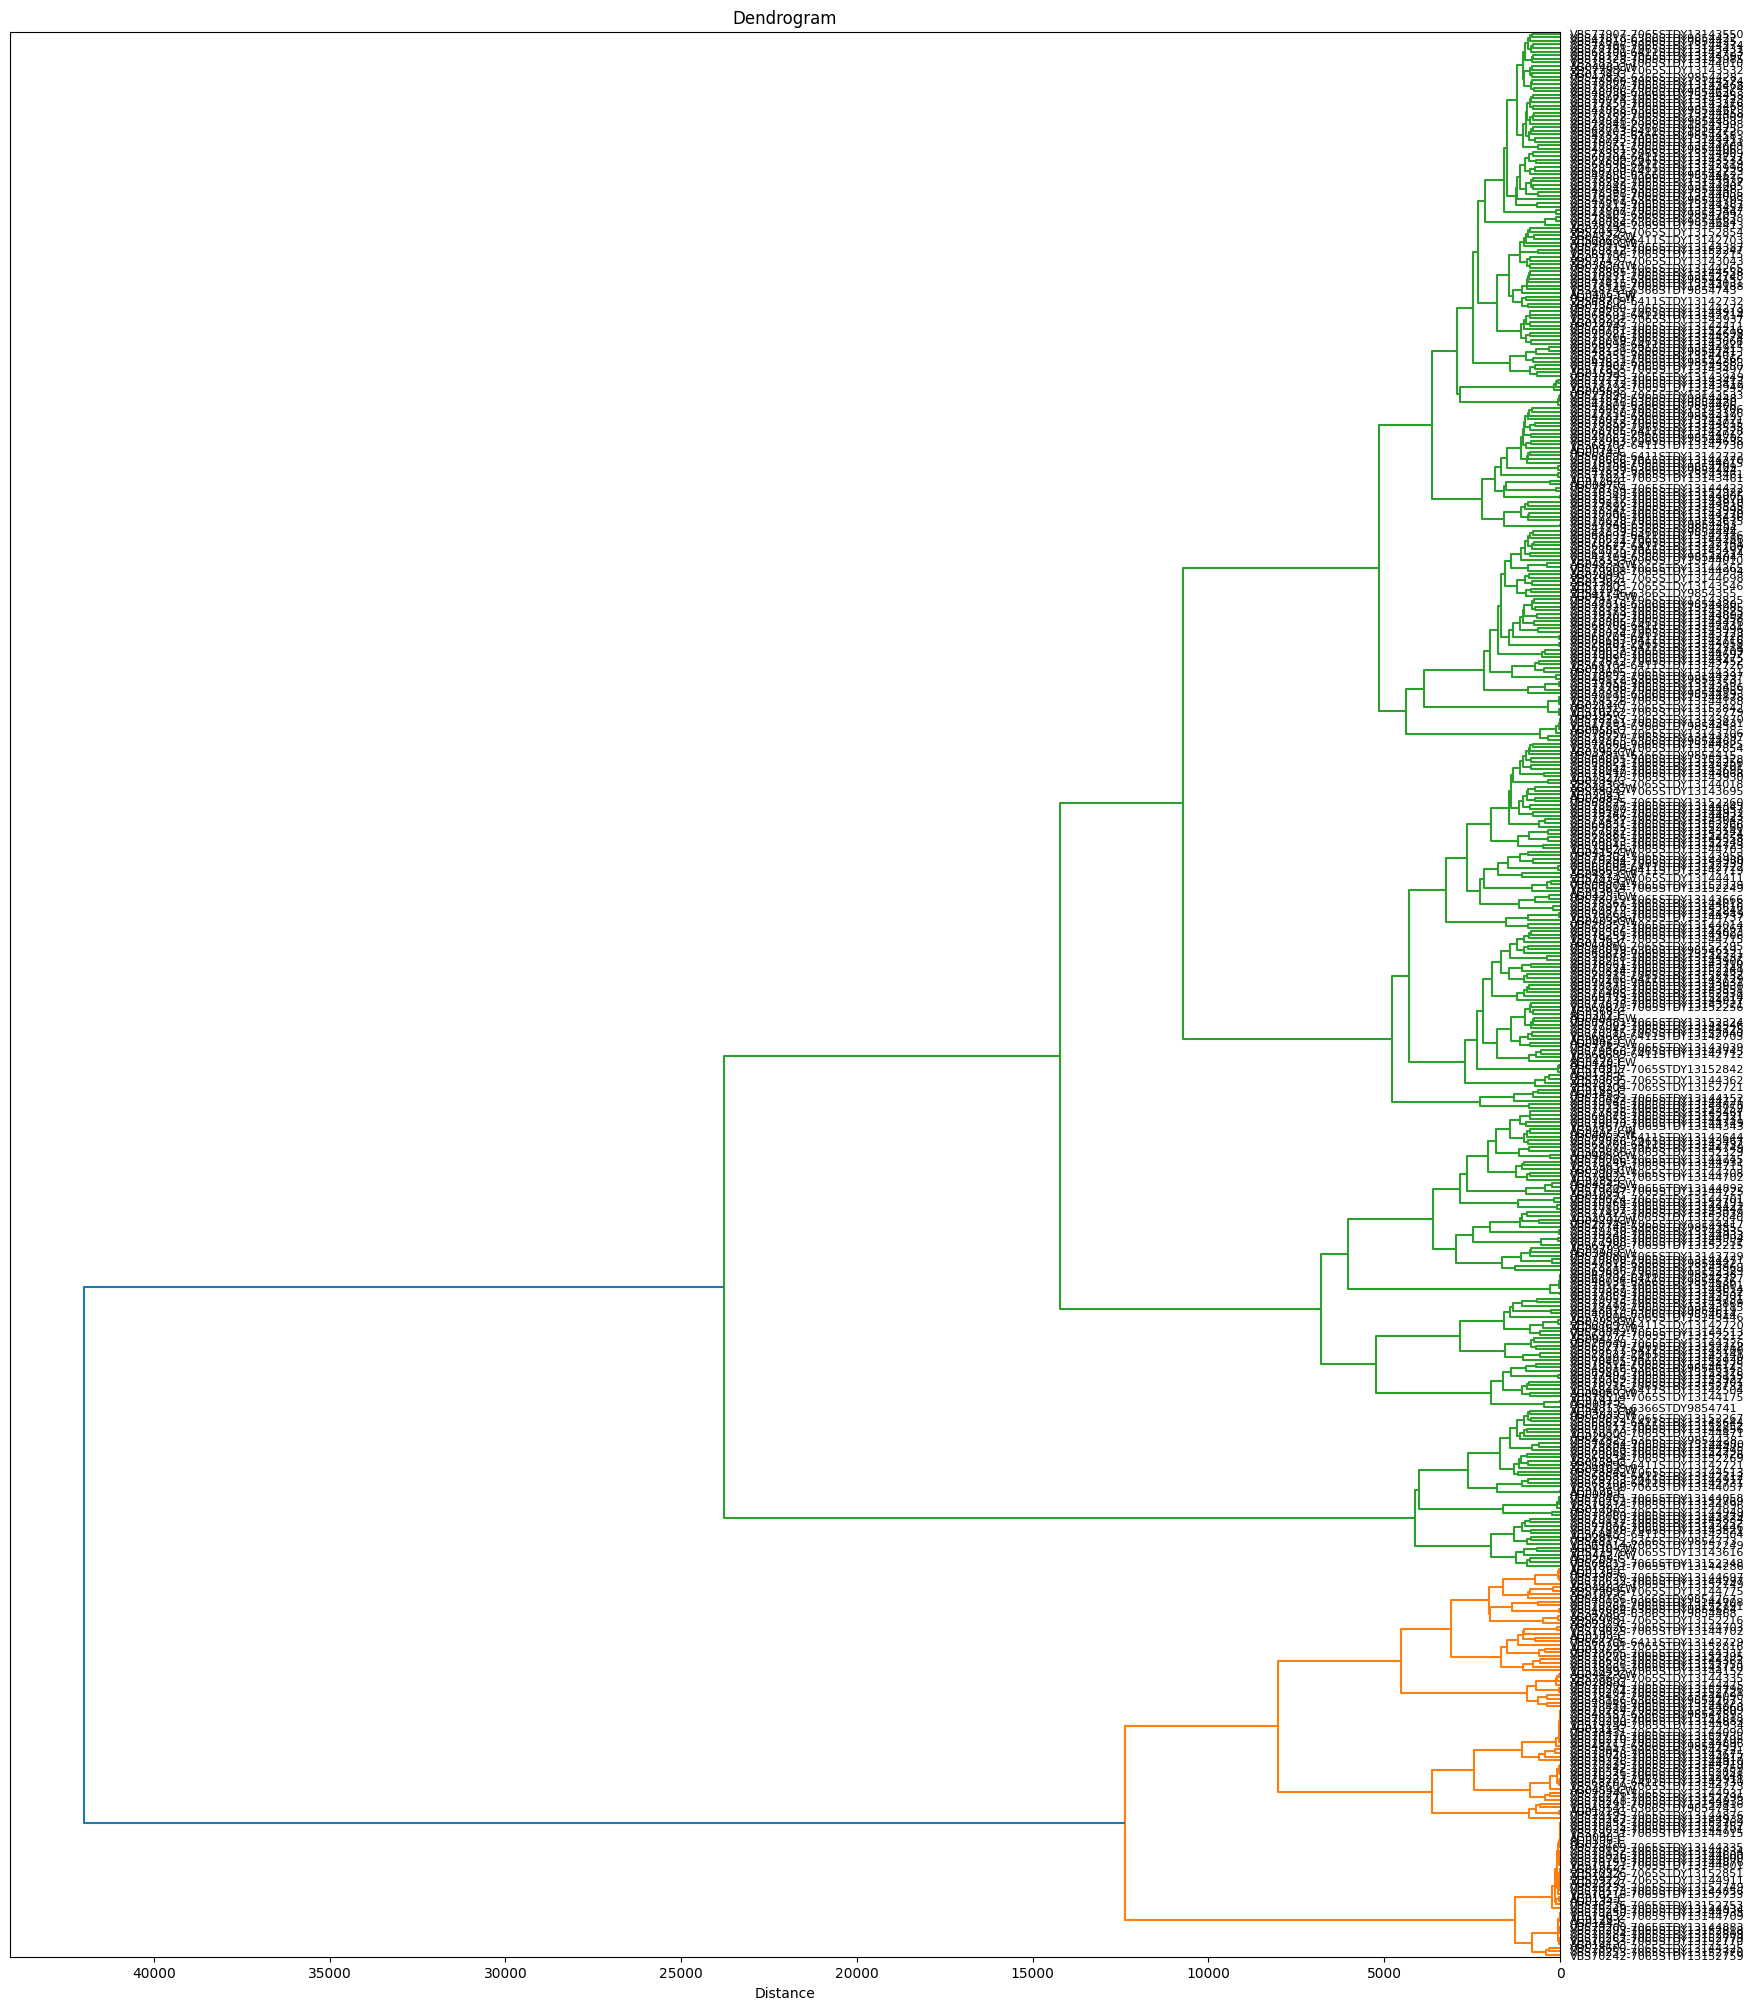

In [6]:
den = plot_dendrogram(distance_matrix_sq, sample_metadata, 'output_dendrogram.png', labels=labels)

In [15]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, optimal_leaf_ordering
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import SpectralEmbedding
from sklearn.datasets import make_blobs
from scipy.spatial.distance import squareform
import numpy as np
import json
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

def plot_dendrogram(distance_matrix_sq, sample_metadata_file, output_file, labels=None, sample_to_color=None):
    """
    Plot dendrogram with colored bars just after the leaf labels

    Parameters:
    - distance_matrix_sq: square distance matrix
    - sample_metadata_file: metadata file (currently unused, but kept for compatibility)
    - output_file: output file path
    - labels: list of sample labels
    - sample_to_color: dictionary mapping sample IDs to colors
    """

    # Create default colors if not provided
    if sample_to_color is None:
        # Generate random colors for each unique label
        unique_labels = list(set(labels)) if labels else []
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
        sample_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Perform hierarchical clustering
    condensed_distances = pdist(distance_matrix_sq)
    linkage_matrix = linkage(condensed_distances, method='ward')

    plt.figure(figsize=(20, 25))

    # Create dendrogram
    den = dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=0,
        leaf_font_size=8,
        no_labels=False,
        orientation='left',
        ax=None,
        count_sort=True,
    )

    print(f"Number of leaves: {len(den['leaves'])}")
    if labels:
        print(f"Number of labels: {len(labels)}")

    # Get current axis limits
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Calculate the y-coordinates of the leaves
    n_leaves = len(den['leaves'])
    leaf_y_coords = [i * 10 for i in range(n_leaves)]

    # Add colored rectangles just after the leaf labels
    if labels:
        for i, leaf_idx in enumerate(den['leaves']):
            sample_id = labels[leaf_idx]
            color = sample_to_color.get(sample_id, 'gray')  # Default to gray if color not found

            # Position rectangle just after the labels (to the right)
            y_pos = leaf_y_coords[i]

            # Position bars just after where labels end
            # Add some padding for the label text
            label_padding = (xlim[1] - xlim[0]) * 0.02  # 2% of plot width for label spacing

            rect = plt.Rectangle(
                (xlim[1] + label_padding, y_pos - 4),  # Position after labels with padding
                (xlim[1] - xlim[0]) * 0.03,  # Width of bars (3% of plot width)
                8,  # Height to cover the leaf
                facecolor=color,
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect)

    # Adjust plot limits to show the rectangles on the RIGHT side
    plot_width = xlim[1] - xlim[0]
    label_padding = plot_width * 0.02
    bar_width = plot_width * 0.03
    total_extension = label_padding + bar_width + (plot_width * 0.01)  # Extra 1% margin

    new_xlim = (xlim[0], xlim[1] + total_extension)
    ax.set_xlim(new_xlim)

    plt.title('Dendrogram')
    plt.xlabel('Distance')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return den

# Alternative version with more precise label positioning
def plot_dendrogram_precise_positioning(distance_matrix_sq, sample_metadata_file, output_file, labels=None, sample_to_color=None):
    """
    Alternative version with more precise positioning based on actual label lengths
    """

    # Create default colors if not provided
    if sample_to_color is None:
        unique_labels = list(set(labels)) if labels else []
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
        sample_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Perform hierarchical clustering
    condensed_distances = pdist(distance_matrix_sq)
    linkage_matrix = linkage(condensed_distances, method='ward')

    plt.figure(figsize=(20, 25))

    # Create dendrogram
    den = dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=0,
        leaf_font_size=8,
        no_labels=False,
        orientation='left',
        ax=None,
        count_sort=True,
    )

    # Get current axis and limits
    ax = plt.gca()
    xlim = ax.get_xlim()

    # Calculate maximum label width to position bars correctly
    if labels:
        max_label_length = max(len(str(label)) for label in labels)
        # Estimate label width based on font size and character count
        char_width_estimate = 8 * 0.6  # Approximate character width in points
        max_label_width_points = max_label_length * char_width_estimate

        # Convert points to data coordinates (rough approximation)
        plot_width = xlim[1] - xlim[0]
        label_width_data = (max_label_width_points / 72) * (plot_width / 20)  # Rough conversion

        # Position bars with precise spacing
        bar_start_x = xlim[1] + label_width_data * 0.1  # Small gap after labels

        n_leaves = len(den['leaves'])
        leaf_y_coords = [i * 10 for i in range(n_leaves)]

        for i, leaf_idx in enumerate(den['leaves']):
            sample_id = labels[leaf_idx]
            color = sample_to_color.get(sample_id, 'gray')

            y_pos = leaf_y_coords[i]
            rect = plt.Rectangle(
                (bar_start_x, y_pos - 4),
                plot_width * 0.02,  # Bar width
                8,  # Bar height
                facecolor=color,
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect)

        # Extend plot limits
        new_xlim = (xlim[0], bar_start_x + plot_width * 0.03)
        ax.set_xlim(new_xlim)

    plt.title('Dendrogram')
    plt.xlabel('Distance')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return den

Number of leaves: 534
Number of labels: 534


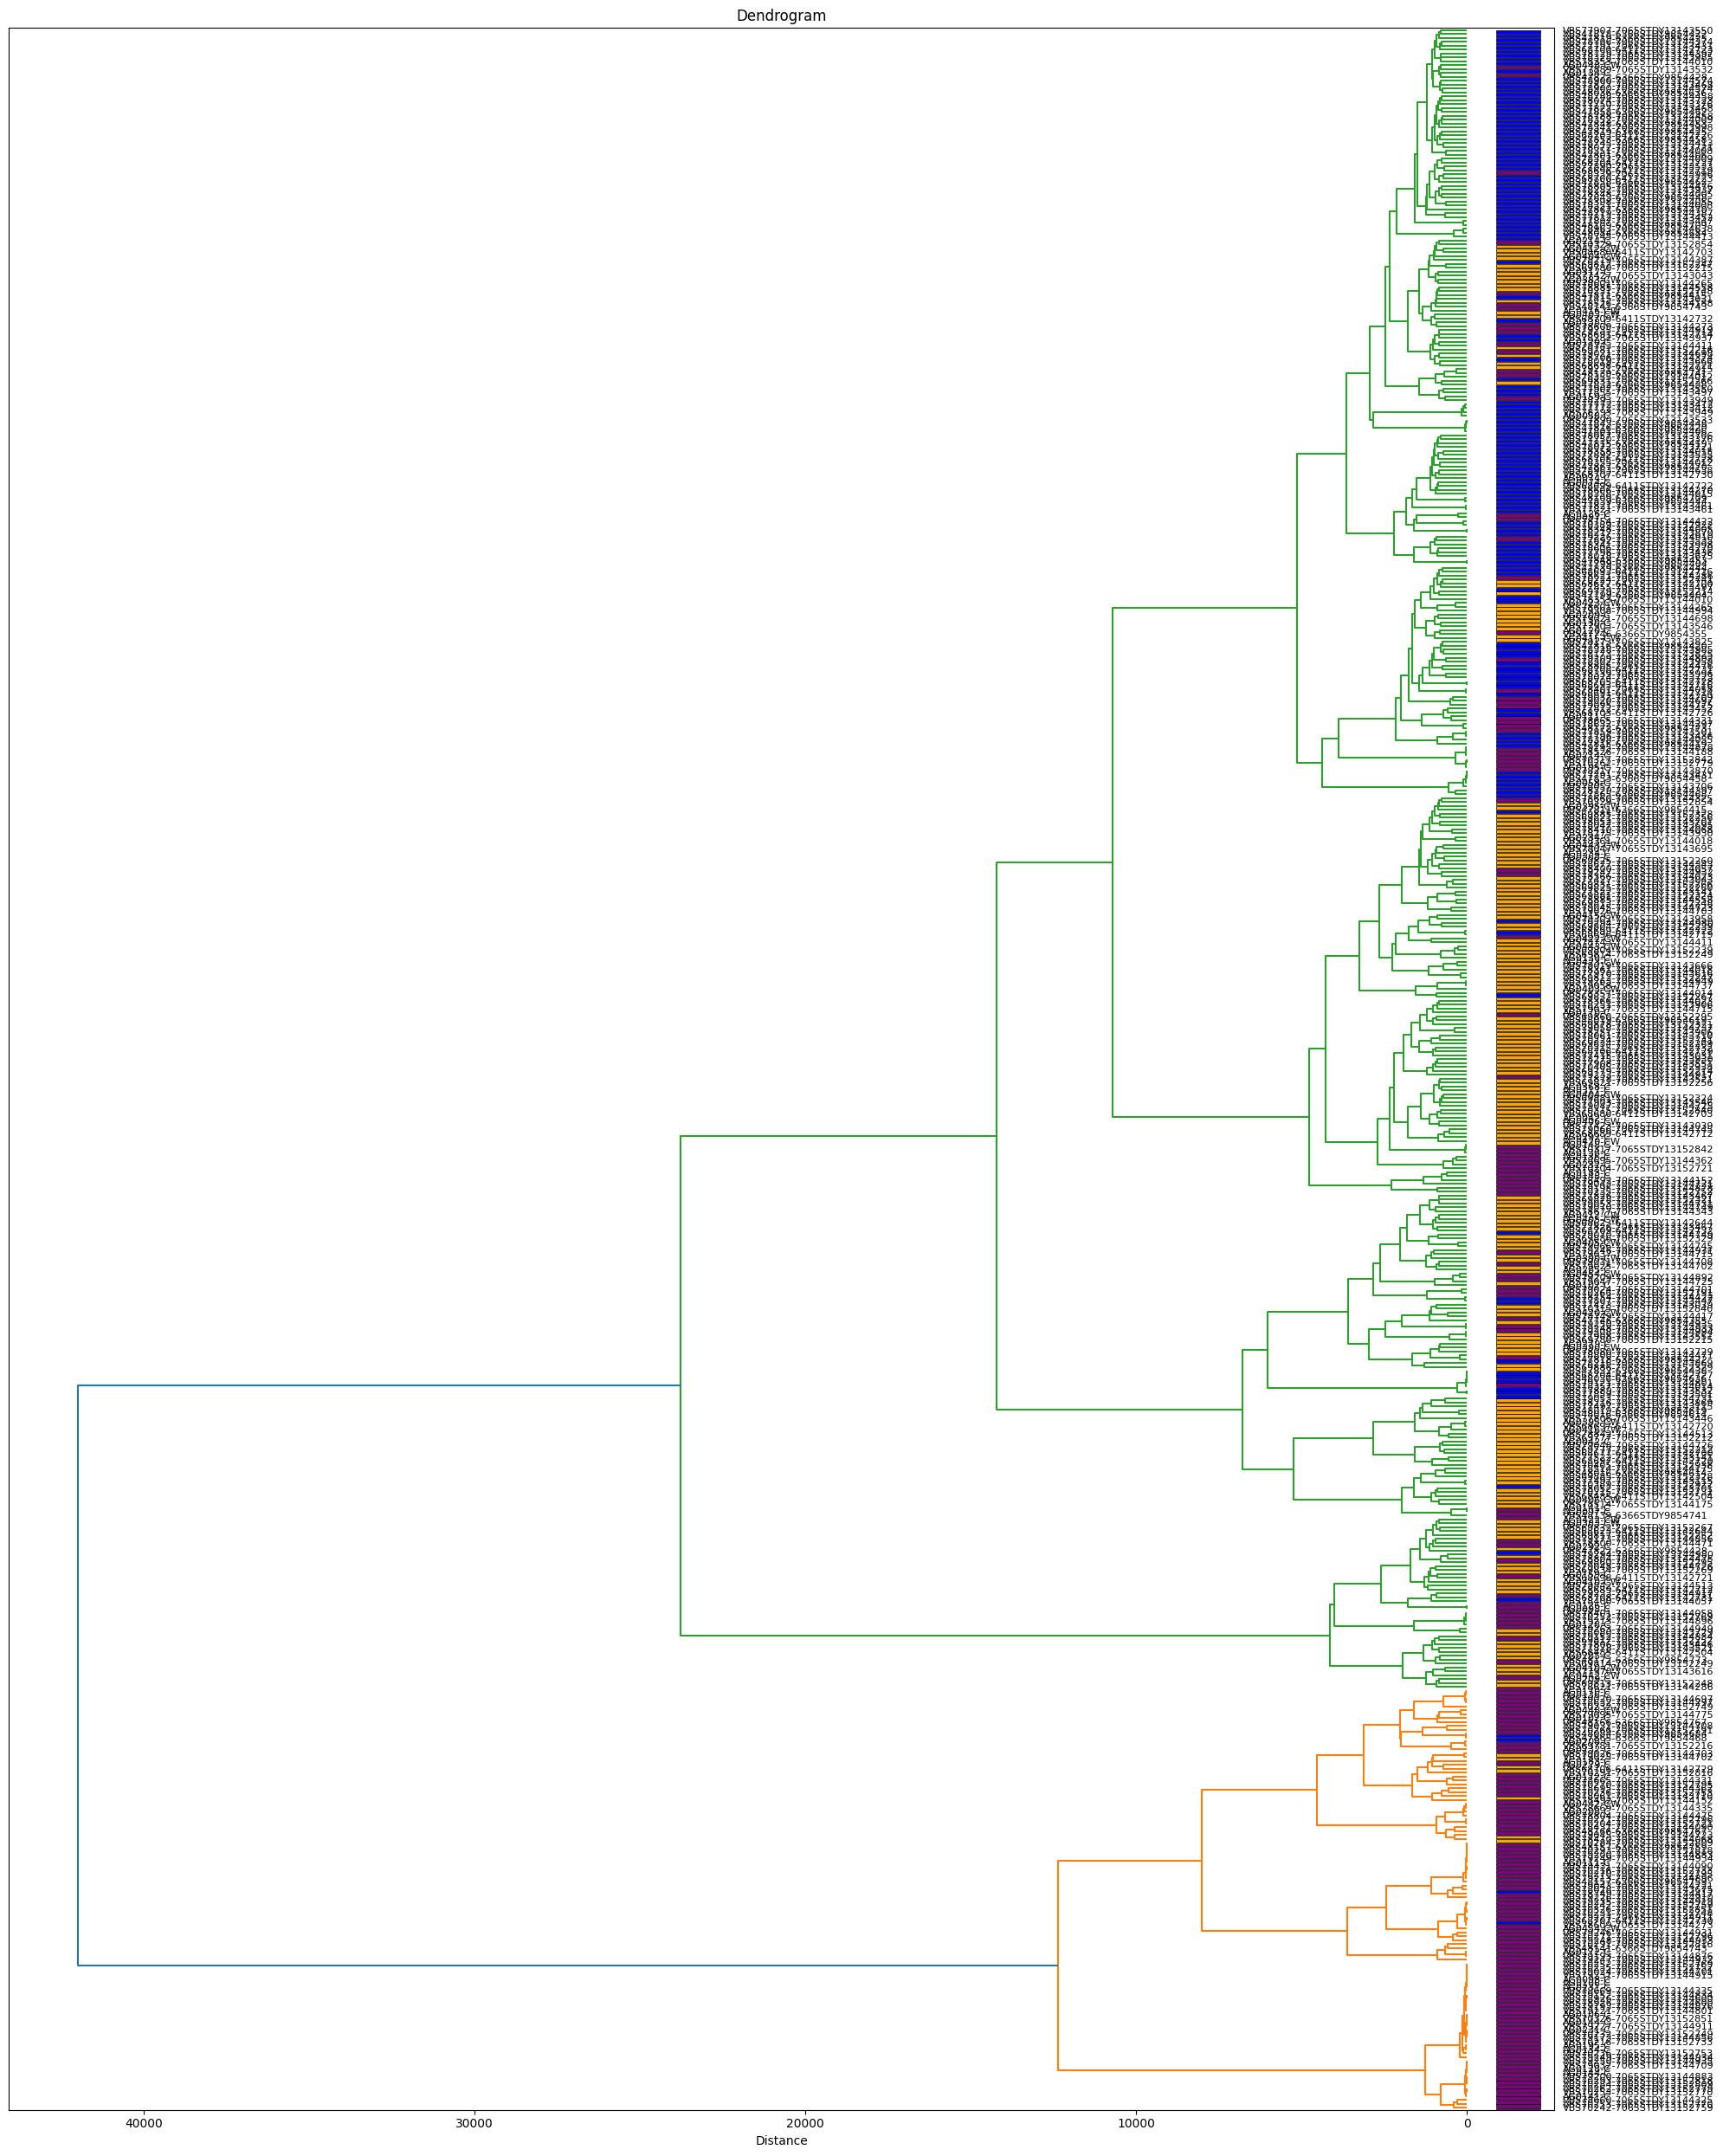

In [16]:
den = plot_dendrogram(distance_matrix_sq, sample_metadata, 'output_dendrogram', labels=list(labels), sample_to_color=sample_to_color)

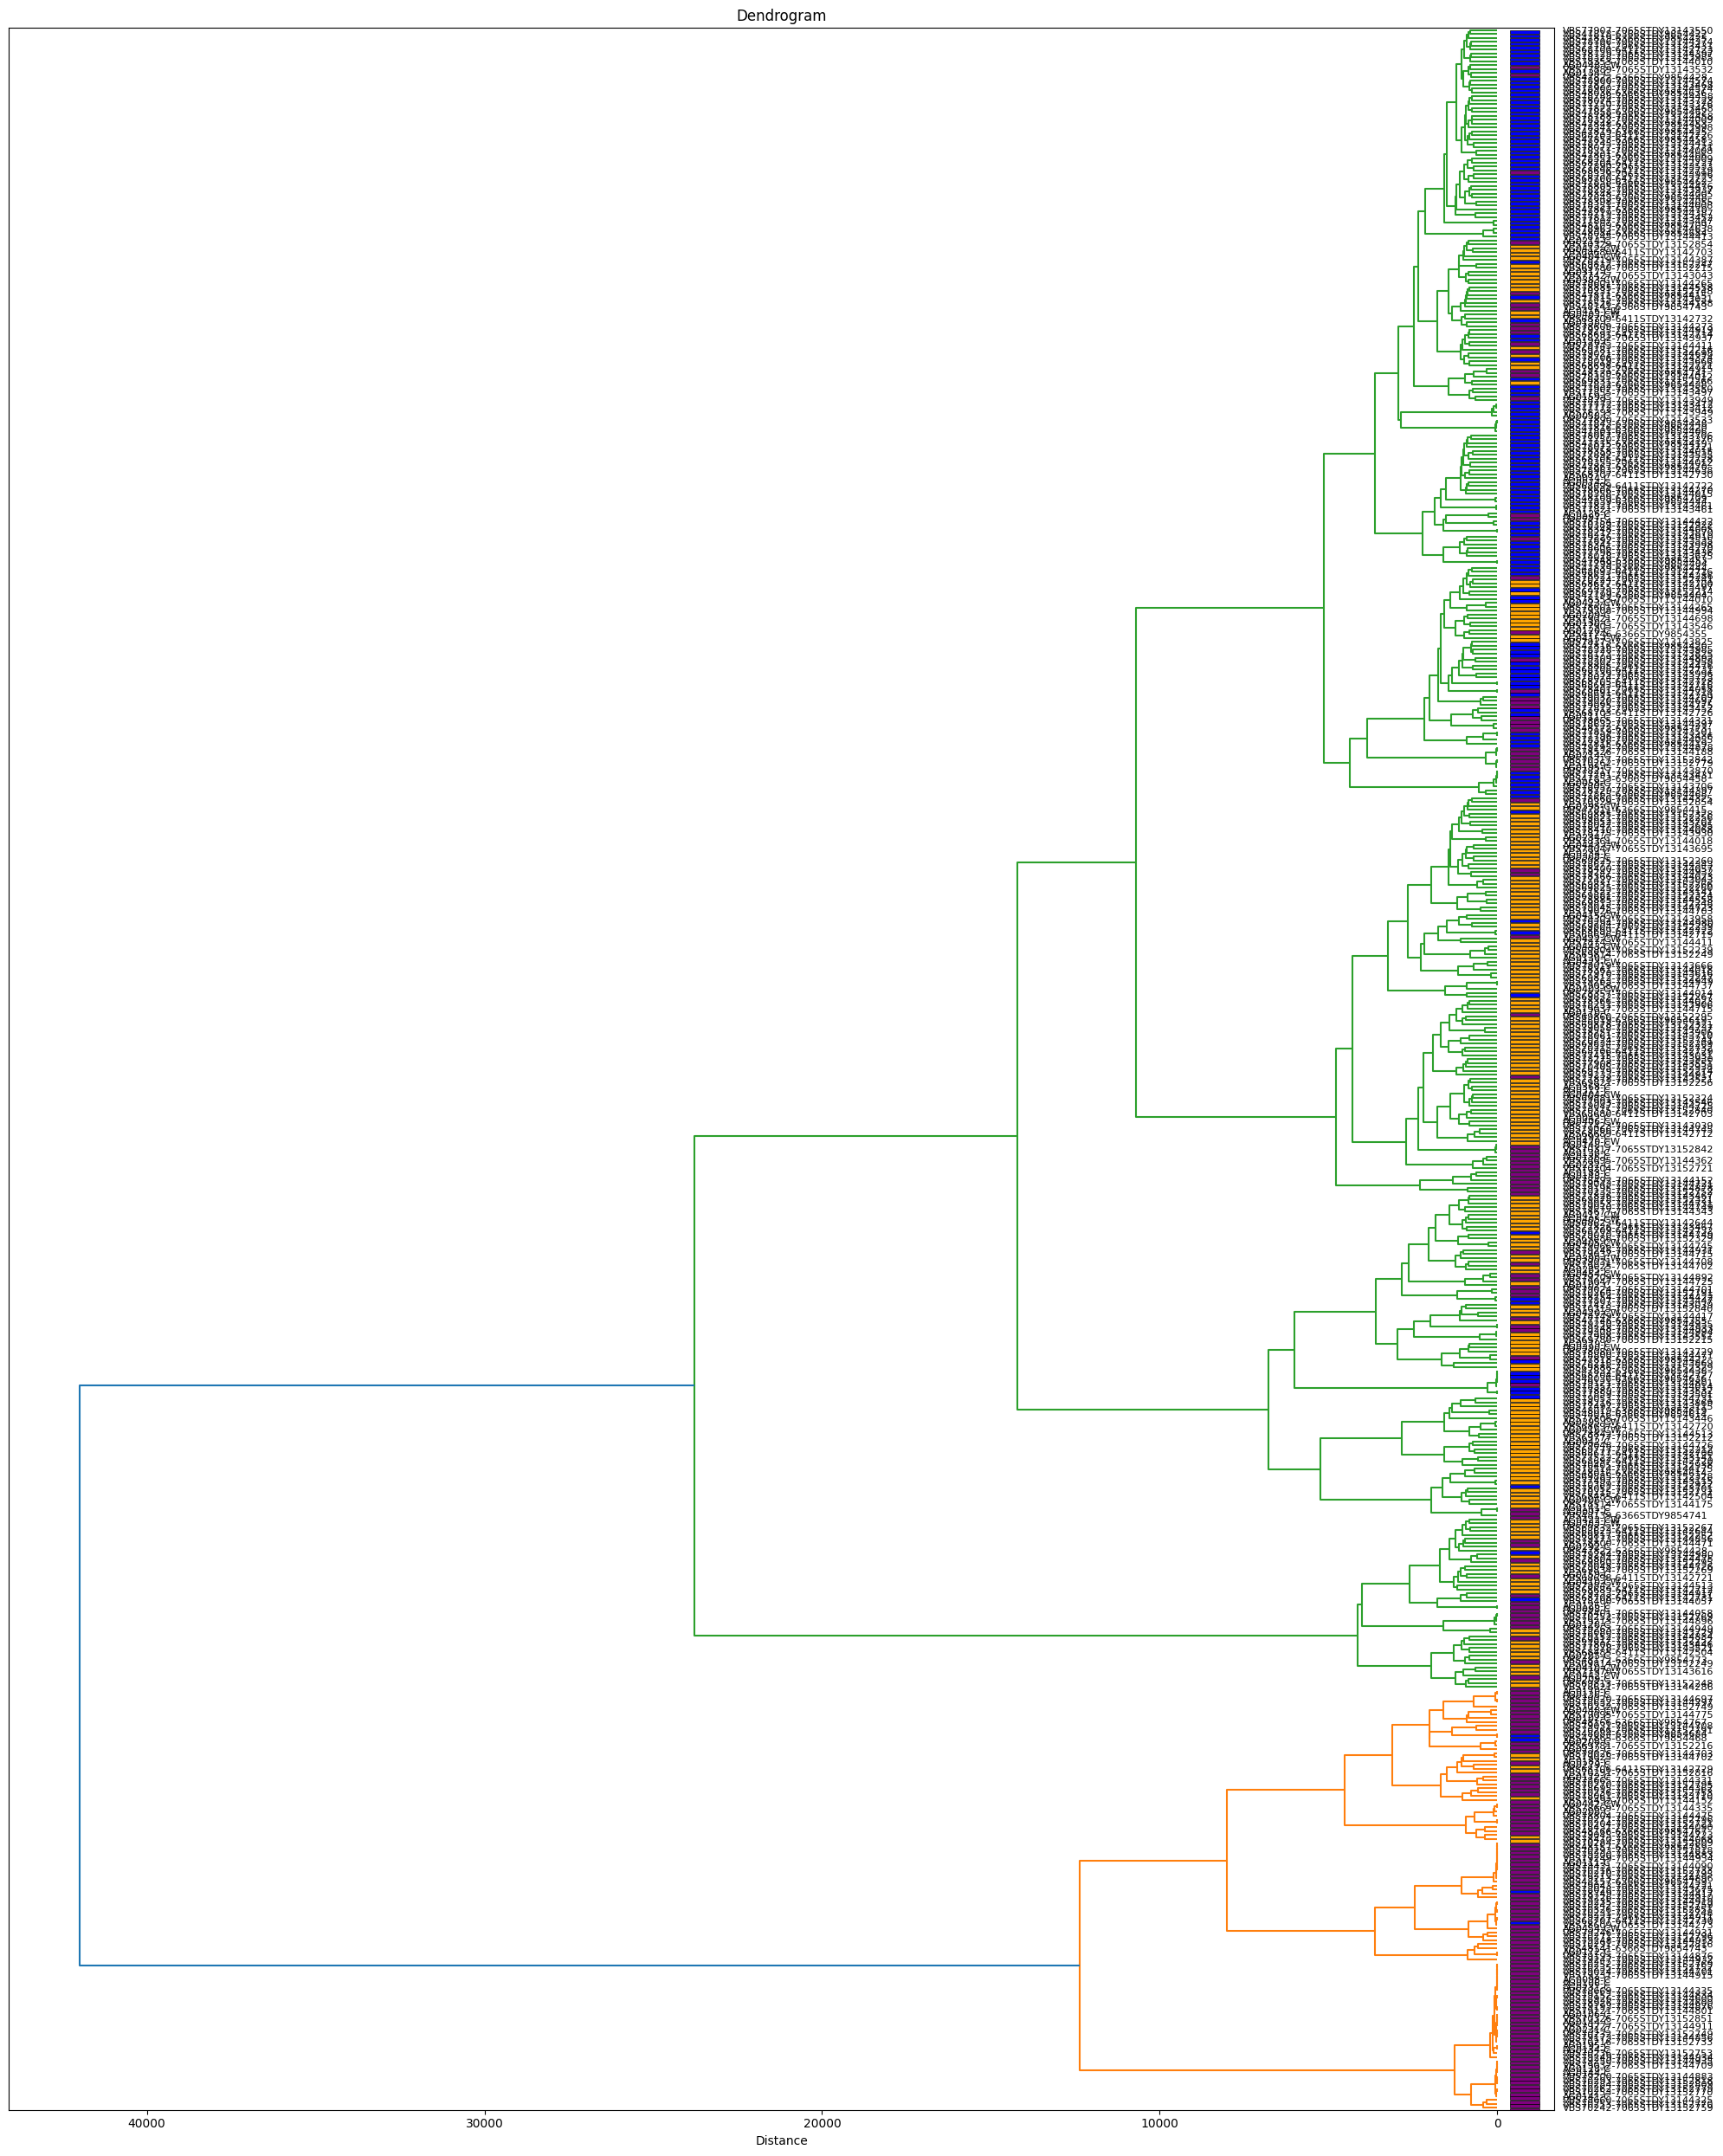

In [17]:
den_2 = plot_dendrogram_precise_positioning(distance_matrix_sq, sample_metadata, 'output_dendrogram', labels=list(labels), sample_to_color=sample_to_color)


In [133]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, optimal_leaf_ordering
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import SpectralEmbedding
from sklearn.datasets import make_blobs
from scipy.spatial.distance import squareform
import numpy as np
import json
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

def plot_dendrogram(distance_matrix_sq, sample_metadata_file, output_file, labels=None,
                   sample_to_color=None, sample_to_taxon_geo=None, taxon_geo_to_color=None):
    """
    Plot dendrogram with colored bars just after the leaf labels

    Parameters:
    - distance_matrix_sq: square distance matrix
    - sample_metadata_file: metadata file (currently unused, but kept for compatibility)
    - output_file: output file path
    - labels: list of sample labels
    - sample_to_color: dictionary mapping sample IDs to colors (first bar)
    - sample_to_taxon_geo: dictionary mapping sample IDs to taxon_geo values
    - taxon_geo_to_color: dictionary mapping taxon_geo values to colors (second bar)
    """

    # Create default colors if not provided
    if sample_to_color is None:
        # Generate random colors for each unique label
        unique_labels = list(set(labels)) if labels else []
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
        sample_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Create default colors for taxon_geo if not provided
    if sample_to_taxon_geo is not None and taxon_geo_to_color is None:
        unique_taxon_geo = list(set(sample_to_taxon_geo.values()))
        geo_colors = plt.cm.viridis(np.linspace(0, 1, len(unique_taxon_geo)))
        taxon_geo_to_color = {geo: geo_colors[i] for i, geo in enumerate(unique_taxon_geo)}

    # Perform hierarchical clustering
    condensed_distances = pdist(distance_matrix_sq)
    linkage_matrix = linkage(condensed_distances, method='ward')

    plt.figure(figsize=(20, 25))

    # Create dendrogram
    den = dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=0,
        leaf_font_size=8,
        no_labels=False,
        orientation='left',
        ax=None,
        count_sort=True,
    )

    print(f"Number of leaves: {len(den['leaves'])}")
    if labels:
        print(f"Number of labels: {len(labels)}")

    # Get current axis limits
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Calculate the y-coordinates of the leaves
    n_leaves = len(den['leaves'])
    leaf_y_coords = [i * 10 for i in range(n_leaves)]

    # Add colored rectangles just after the leaf labels
    if labels:
        for i, leaf_idx in enumerate(den['leaves']):
            sample_id = labels[leaf_idx]
            y_pos = leaf_y_coords[i]

            # Position bars just after where labels end
            # Add some padding for the label text
            label_padding = (xlim[1] - xlim[0]) * 0.02  # 2% of plot width for label spacing
            bar_width = (xlim[1] - xlim[0]) * 0.03      # Width of bars (3% of plot width)
            bar_spacing = (xlim[1] - xlim[0]) * 0.005   # Spacing between bars

            # FIRST BAR: Sample colors
            color1 = sample_to_color.get(sample_id, 'gray')  # Default to gray if color not found

            rect1 = plt.Rectangle(
                (xlim[1] + label_padding, y_pos - 4),  # Position after labels with padding
                bar_width,  # Width of bars
                8,  # Height to cover the leaf
                facecolor=color1,
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect1)

            # SECOND BAR: Taxon_geo colors (if provided)
            if sample_to_taxon_geo is not None and taxon_geo_to_color is not None:
                taxon_geo = sample_to_taxon_geo.get(sample_id, 'Unknown')
                color2 = taxon_geo_to_color.get(taxon_geo, 'lightgray')  # Default to lightgray

                rect2 = plt.Rectangle(
                    (xlim[1] + label_padding + bar_width + bar_spacing, y_pos - 4),  # Position after first bar
                    bar_width,  # Width of bars
                    8,  # Height to cover the leaf
                    facecolor=color2,
                    edgecolor='black',
                    linewidth=0.5
                )
                ax.add_patch(rect2)

    # Adjust plot limits to show the rectangles on the RIGHT side
    plot_width = xlim[1] - xlim[0]
    label_padding = plot_width * 0.02
    bar_width = plot_width * 0.03
    bar_spacing = plot_width * 0.005

    # Calculate total extension based on number of bars
    if sample_to_taxon_geo is not None and taxon_geo_to_color is not None:
        # Two bars
        total_extension = label_padding + (2 * bar_width) + bar_spacing + (plot_width * 0.01)  # Extra 1% margin
    else:
        # One bar
        total_extension = label_padding + bar_width + (plot_width * 0.01)  # Extra 1% margin

    new_xlim = (xlim[0], xlim[1] + total_extension)
    ax.set_xlim(new_xlim)

    # Add legend for taxon_geo colors if provided
    if taxon_geo_to_color:
        legend_elements = [Patch(facecolor=color, edgecolor='black', label=geo)
                          for geo, color in taxon_geo_to_color.items()]
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
                 title='Taxon Geography', fontsize=8)

    plt.title('Dendrogram')
    plt.xlabel('Distance')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return den

# Alternative version with more precise label positioning for both bars
def plot_dendrogram_precise_positioning(distance_matrix_sq, sample_metadata_file, output_file, labels=None,
                                      sample_to_color=None, sample_to_taxon_geo=None, taxon_geo_to_color=None):
    """
    Alternative version with more precise positioning based on actual label lengths - for both bars
    """

    # Create default colors if not provided
    if sample_to_color is None:
        unique_labels = list(set(labels)) if labels else []
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
        sample_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Create default colors for taxon_geo if not provided
    if sample_to_taxon_geo is not None and taxon_geo_to_color is None:
        unique_taxon_geo = list(set(sample_to_taxon_geo.values()))
        geo_colors = plt.cm.viridis(np.linspace(0, 1, len(unique_taxon_geo)))
        taxon_geo_to_color = {geo: geo_colors[i] for i, geo in enumerate(unique_taxon_geo)}

    # Perform hierarchical clustering
    condensed_distances = pdist(distance_matrix_sq)
    linkage_matrix = linkage(condensed_distances, method='ward')

    plt.figure(figsize=(20, 25))

    # Create dendrogram
    den = dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=0,
        leaf_font_size=8,
        no_labels=True,
        orientation='left',
        ax=None,
        count_sort=True,
        color_threshold=500

    )

    # Get current axis and limits
    ax = plt.gca()
    xlim = ax.get_xlim()

    # Calculate maximum label width to position bars correctly
    if labels:
        max_label_length = max(len(str(label)) for label in labels)
        # Estimate label width based on font size and character count
        char_width_estimate = 8 * 0.6  # Approximate character width in points
        max_label_width_points = max_label_length * char_width_estimate

        # Convert points to data coordinates (rough approximation)
        plot_width = xlim[1] - xlim[0]
        label_width_data = (max_label_width_points / 72) * (plot_width / 20)  # Rough conversion

        # Position bars with precise spacing
        bar_start_x = xlim[1] + label_width_data * 0.1  # Small gap after labels
        bar_width = plot_width * 0.05  # Bar width
        bar_spacing = plot_width * 0.005  # Spacing between bars

        n_leaves = len(den['leaves'])
        leaf_y_coords = [i * 10 for i in range(n_leaves)]

        for i, leaf_idx in enumerate(den['leaves']):
            sample_id = labels[leaf_idx]
            y_pos = leaf_y_coords[i]

            # FIRST BAR: Sample colors
            color1 = sample_to_color.get(sample_id, 'gray')

            rect1 = plt.Rectangle(
                (bar_start_x, y_pos - 4),
                bar_width,  # Bar width
                8,  # Bar height
                facecolor=color1,
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect1)

            # SECOND BAR: Taxon_geo colors (if provided)
            if sample_to_taxon_geo is not None and taxon_geo_to_color is not None:
                taxon_geo = sample_to_taxon_geo.get(sample_id, 'Unknown')

                color2 = taxon_geo_to_color.get(sample_id, 'lightgray')

                rect2 = plt.Rectangle(
                    (bar_start_x + bar_width + bar_spacing, y_pos - 4),
                    bar_width,  # Bar width
                    8,  # Bar height
                    facecolor=color2,
                    edgecolor='black',
                    linewidth=0.5
                )
                ax.add_patch(rect2)

        # Extend plot limits based on number of bars
        if sample_to_taxon_geo is not None and taxon_geo_to_color is not None:
            # Two bars
            new_xlim = (xlim[0], bar_start_x + (2 * bar_width) + bar_spacing + (plot_width * 0.01))
        else:
            # One bar
            new_xlim = (xlim[0], bar_start_x + bar_width + (plot_width * 0.01))

        ax.set_xlim(new_xlim)



    plt.title('Dendrogram')
    plt.xlabel('Distance')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return den

# Function to create taxon_geo mappings from your DataFrame (corrected version)
def create_taxon_geo_from_dataframe(df_samples_phased, labels):
    """
    Create taxon_geo mappings based on your DataFrame approach (corrected)
    """
    # Create taxon_geo mapping
    df_samples_phased['taxon_geo'] = df_samples_phased['taxon'] + '_' + df_samples_phased['admin1_iso']

    # Create color palette for each unique taxon_geo (FIXED)
    taxon_geo_unique = df_samples_phased['taxon_geo'].unique()
    palette = sns.color_palette("tab10", len(taxon_geo_unique))  # FIXED: use taxon_geo_unique
    taxon_geo_to_color = dict(zip(taxon_geo_unique, palette))    # FIXED: use taxon_geo_unique

    # Map sample ID to taxon_geo
    sample_to_taxon_geo = dict(zip(df_samples_phased['sample_id'], df_samples_phased['taxon_geo']))

    # Filter to only include samples that are in our labels (for safety)
    sample_to_taxon_geo = {s: sample_to_taxon_geo[s] for s in labels if s in sample_to_taxon_geo}

    return sample_to_taxon_geo, taxon_geo_to_color

In [131]:
#  Create taxon_geo mapping
df_samples_phased['taxon_geo'] = df_samples_phased['taxon'] + '_' + df_samples_phased['admin1_iso']



# Create color palette for each unique taxon_geo
taxon_geo = df_samples_phased['admin1_iso'].unique()
#palette = sns.color_palette("tab10", len(taxon_geo))
#taxon_geo_to_color = dict(zip(taxon_geo, palette))

"""taxon_geo_to_color = {
    'GM-W': 'rgba(48, 144, 22, 0.8)',
    'GM-L': 'rgba(225, 159, 16, 0.8)',
    'GM-N': 'rgba(190, 71, 57, 0.8)',
    'GM-M': 'rgba(130, 100, 140, 0.8)',
    'GM-U': 'rgba(87, 144, 182, 0.8)'
}"""

# Convert RGBA strings to tuples of floats
def rgba_string_to_tuple(rgba_string):
    rgba_string = rgba_string.replace('rgba(', '').replace(')', '')
    r, g, b, a = map(float, rgba_string.split(','))
    return (r/255, g/255, b/255, a)

taxon_geo_to_color = {
    'GM-W': 'green',#rgba_string_to_tuple('rgba(48, 144, 22, 0.8)'),
    'GM-L': 'yellow',#rgba_string_to_tuple('rgba(225, 159, 16, 0.8)'),
    'GM-N': 'red',#rgba_string_to_tuple('rgba(190, 71, 57, 0.8)'),
    'GM-M': 'aqua',#rgba_string_to_tuple('rgba(130, 100, 140, 0.8)'),
    'GM-U': 'teal'#rgba_string_to_tuple('rgba(87, 144, 182, 0.8)')
}
# Map sample ID to color
sample_to_taxon_geo = dict(zip(df_samples_phased['sample_id'], df_samples_phased['admin1_iso']))

taxon_geo_to_color = {s: taxon_geo_to_color[sample_to_taxon_geo[s]] for s in labels}


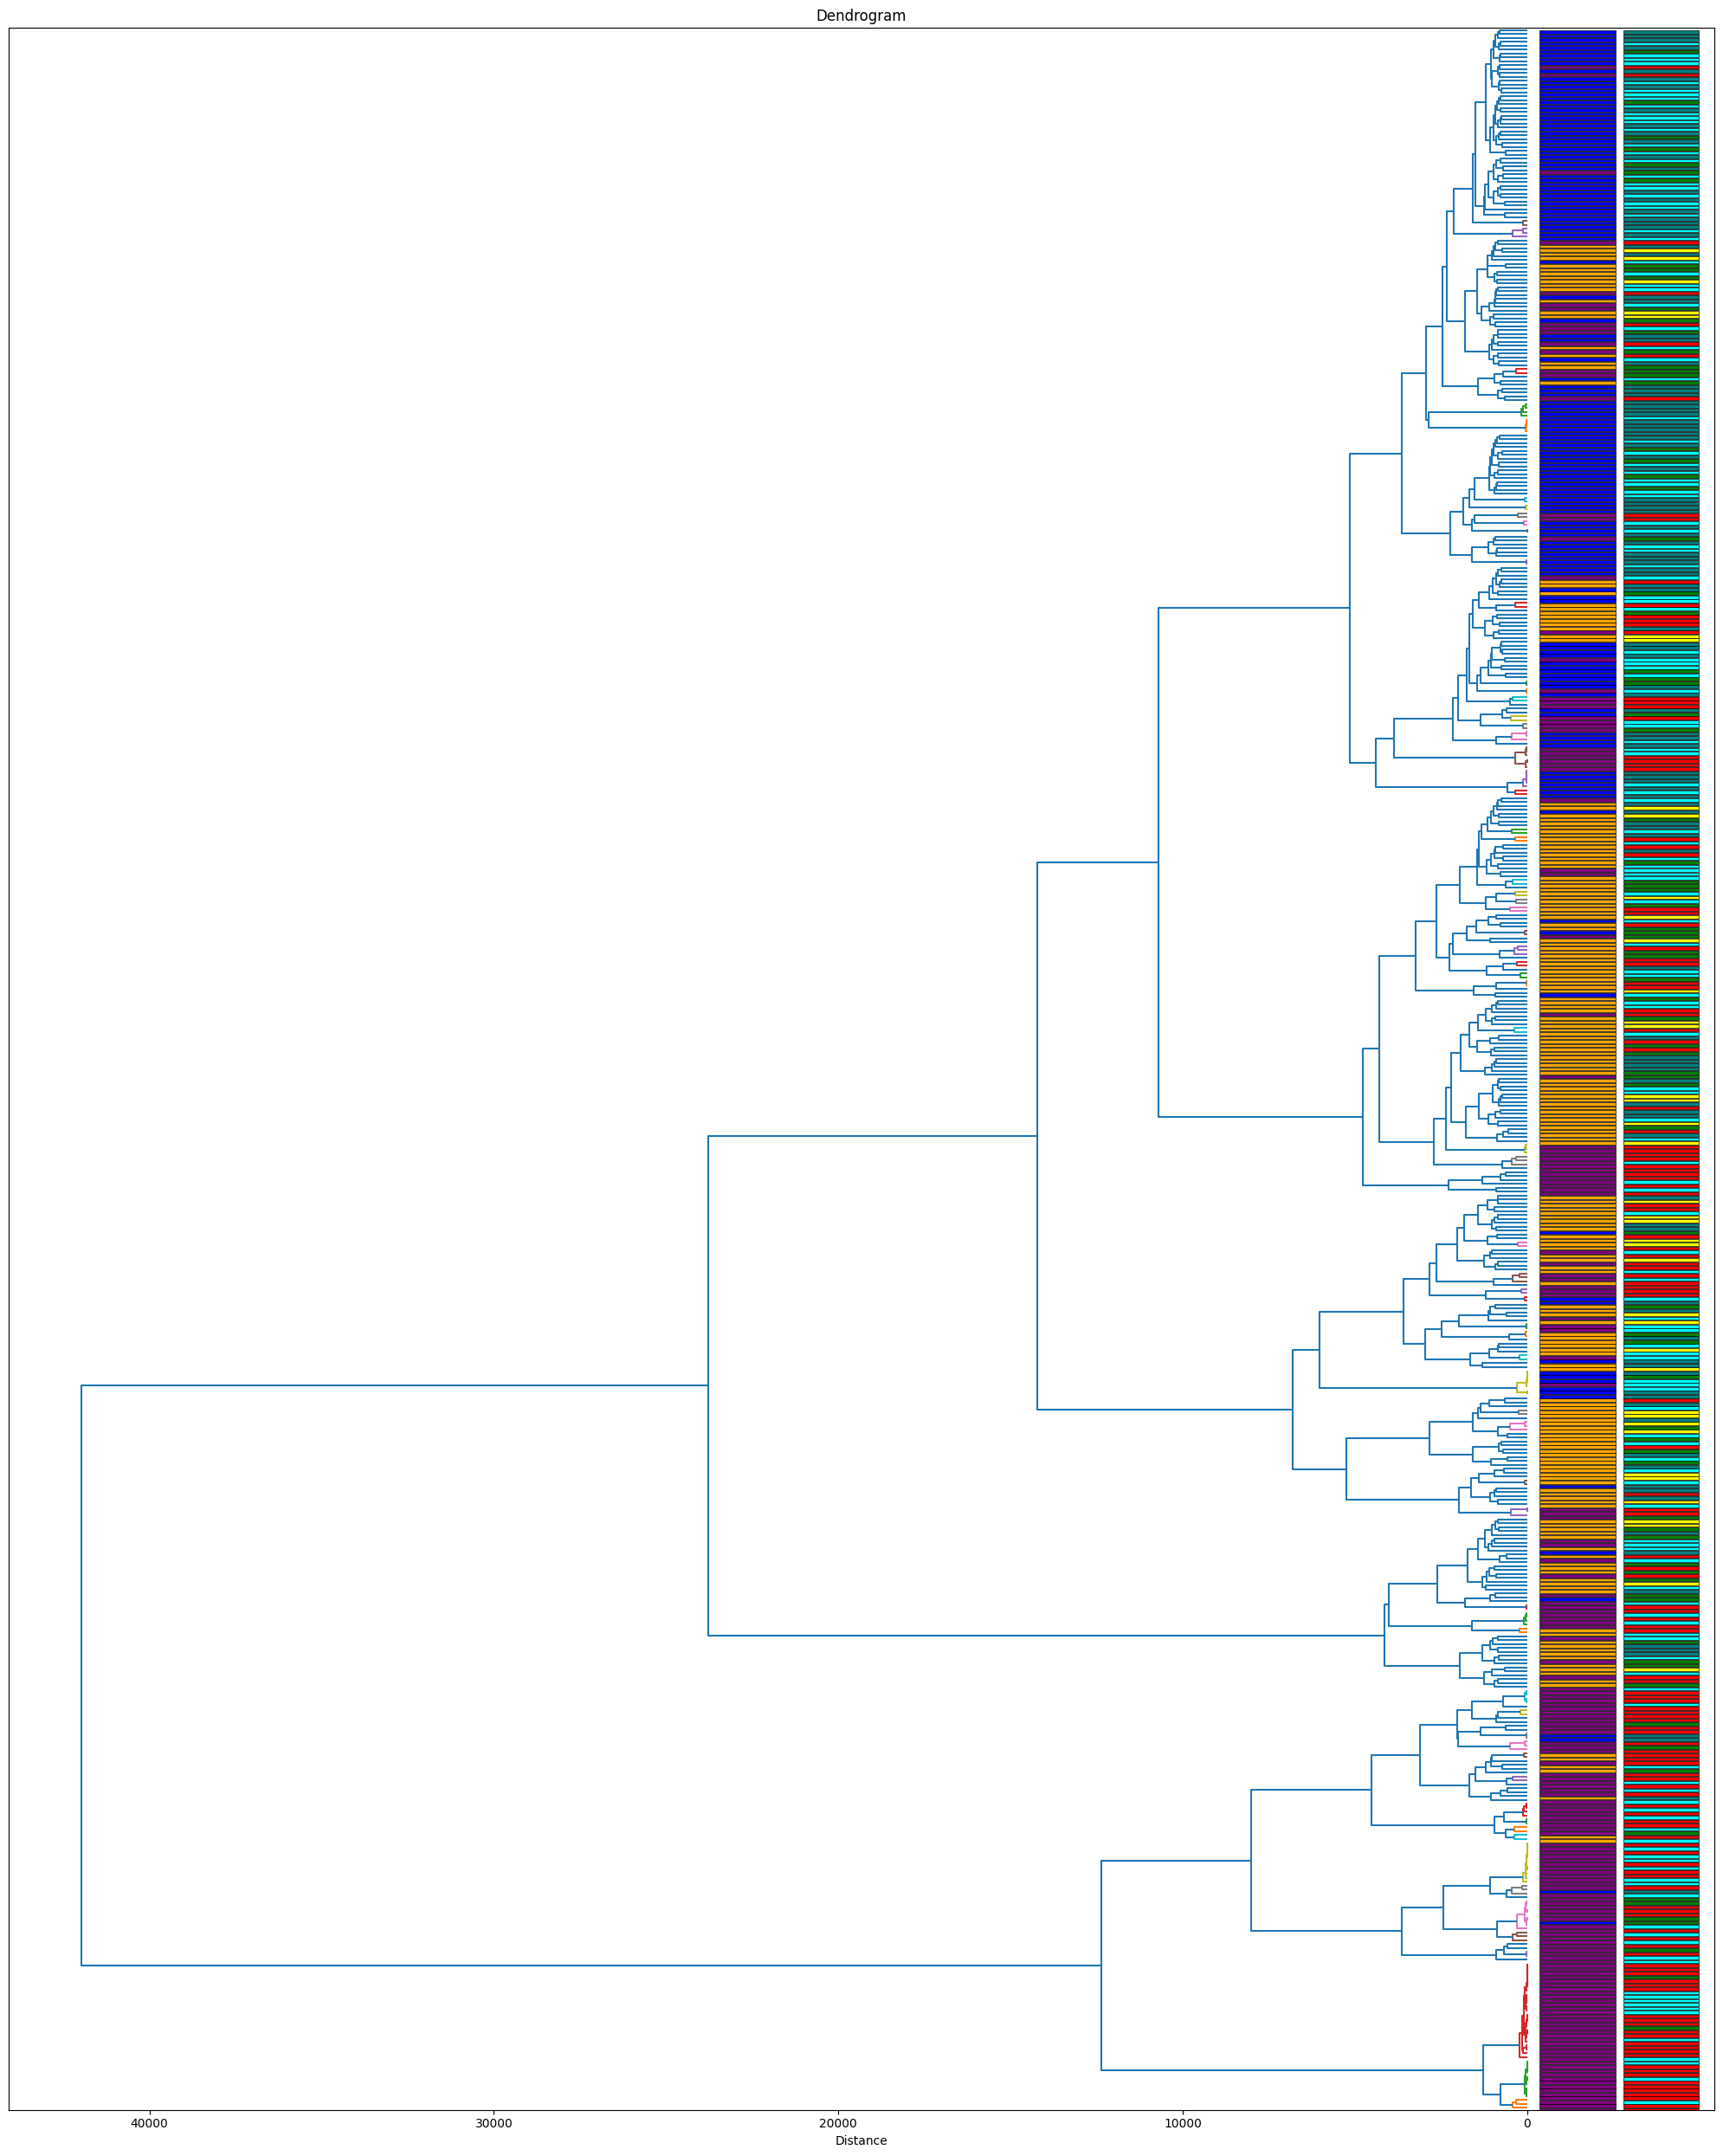

In [134]:
# Plot dendrogram with both color bars
den = plot_dendrogram_precise_positioning(
    distance_matrix_sq,
    sample_metadata,
    'dendrogram_with_geo.png',
    labels=list(labels),
    sample_to_color=sample_to_color,
    sample_to_taxon_geo=sample_to_taxon_geo,
    taxon_geo_to_color=taxon_geo_to_color)